# **Step 1 — Import libraries**

In [ ]:
!pip install tiktoken

In [ ]:
!pip install transformers -q

In [ ]:
!pip install -q sentence-transformers

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter
import re
import hashlib
import gc
import json
import tiktoken
import csv
from transformers import AutoTokenizer
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# **Step 2 — Connect the dataset**

In [ ]:
# Mount Google Drive inside Colab and then read the CSV from its path
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
file_path = "/content/drive/MyDrive/complaints.csv"

# **Step 3 — Read only a small sample first**

Do not load all 5 million rows at once at the beginning.This first step is just to confirm:

* file reads correctly
* separator is correct
* column names look right
* text columns are not broken

In [ ]:
sample_df = pd.read_csv(file_path, nrows=10000)
sample_df.head()

In [ ]:
# check columns
sample_df.columns.tolist()

# **Step 4 — Read only column names and dtypes from a small chunk**

What we want to look for here:


*   which columns are object
*   which columns are dates but currently stored as strings
*   which columns are mostly categorical
*   whether Complaint ID is numeric or string

In [ ]:
sample_df.info()

# **Step 5 — Define the column groups manually**

Before doing full profiling, organize columns into logical groups.

In [ ]:
# Main text column for RAG
text_columns = ["Consumer complaint narrative"]

In [ ]:
# Category/filter columns
categorical_columns = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Tags",
    "Consumer consent provided?",
    "Submitted via",
    "Company public response",
    "Company response to consumer",
    "Timely response?",
    "Consumer disputed?"
]

In [ ]:
# Date columns
date_columns = ["Date received", "Date sent to company"]

In [ ]:
# Identifier columns
id_columns = ["Complaint ID"]

In [ ]:
# semi-structured / risky fields
special_columns = ["ZIP code"]

# **Step 6 — Profile the dataset in chunks and count total rows**

Now do the real profiling without loading all rows at once.

This confirms the file size and helps later when computing percentages.

In [ ]:
chunk_size = 100000
chunks = pd.read_csv(file_path, chunksize=chunk_size)

In [ ]:
total_rows = 0

for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False):
    total_rows += len(chunk)

print("Total rows:", total_rows)

# **Step 7 — Check missing values column by column**

What we need to learn from this:

* Is Consumer complaint narrative mostly missing or available enough?
* Which metadata fields are sparse?
* Are some columns almost empty and maybe useless?

For this dataset, the narrative column is usually the most important one to inspect carefully.

In [ ]:
missing_counts = None
total_rows = 0

for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False):
    total_rows += len(chunk)
    chunk_missing = chunk.isna().sum()

    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts += chunk_missing

missing_percent = (missing_counts / total_rows * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_summary

# **Step 8 — Check uniqueness, cardinality, and top values of the non-text columns**

Why this is the right next step now:

We already know which columns have lots of missing values, now we need to understand what kind of values the columns contain. This will help us decide:
* identifier vs category vs weak metadata
* good filter vs bad filter
* low-cardinality vs high-cardinality
* whether values are clean and consistent

In [ ]:
from collections import Counter

cols_to_check = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Tags",
    "Consumer consent provided?",
    "Submitted via",
    "Company public response",
    "Company response to consumer",
    "Timely response?",
    "Consumer disputed?"
]

unique_values = {col: set() for col in cols_to_check}
top_counts = {col: Counter() for col in cols_to_check}

for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False):
    for col in cols_to_check:
        values = chunk[col].dropna().astype(str).str.strip()
        values = values[values != ""]

        unique_values[col].update(values.unique())
        top_counts[col].update(values)

for col in cols_to_check:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"Unique count: {len(unique_values[col])}")
    print("Top 10 values:")
    print(top_counts[col].most_common(10))

In [ ]:
id_unique_count = set()
duplicate_ids = 0

for chunk in pd.read_csv(file_path, usecols=["Complaint ID"], chunksize=100000, low_memory=False):
    ids = chunk["Complaint ID"].dropna().tolist()
    for x in ids:
        if x in id_unique_count:
            duplicate_ids += 1
        else:
            id_unique_count.add(x)

print("Unique Complaint IDs:", len(id_unique_count))
print("Duplicate Complaint IDs found:", duplicate_ids)

1. **Complaint ID** is a clean unique identifier, since we found **3,585,952** unique IDs and **0** duplicates.
2. **Product**, **Issue**, **Sub-product**, and **State** have manageable category counts, so they look strong for filtering.
3. **Product** has **18** unique values, **Issue** **165**, **Sub-product** **76**, and **State** **63**.
4. **Company** is **high-cardinality** with **6,731** unique values, so it is useful metadata and maybe a filter, but not as clean/simple as Product or State.
5. **Tags** is **low-cardinality** but earlier we saw it is heavily missing, so it is not strong enough to trust as a core filter yet.
6. **Timely response?** and **Consumer disputed?** behave like status/boolean-style columns, since they each only show Yes/No values among non-null rows.

**Check 1**

Full duplicate rows:
Since Complaint ID is unique, if we include it in the duplicate check, almost no row will ever look duplicated.
So for this check, we should do both:

* exact duplicate rows including Complaint ID
* exact duplicate rows excluding Complaint ID

The second one is much more useful.

In [ ]:
import hashlib

cols_for_full_row_check_including_id = [
    "Complaint ID",
    "Consumer complaint narrative",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

cols_for_full_row_check_excluding_id = [
    "Consumer complaint narrative",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

def row_hash_from_values(values):
    joined = "||".join(["<NA>" if pd.isna(v) else str(v) for v in values])
    return hashlib.md5(joined.encode("utf-8")).hexdigest()

seen_including_id = set()
seen_excluding_id = set()

duplicate_rows_including_id = 0
duplicate_rows_excluding_id = 0

for chunk in pd.read_csv(file_path, usecols=cols_for_full_row_check_including_id, chunksize=100000, low_memory=False):
    # make date columns comparable as strings
    for col in ["Date received", "Date sent to company"]:
        chunk[col] = pd.to_datetime(chunk[col], errors="coerce").astype("string")

    # hash including ID
    hashes_including = chunk[cols_for_full_row_check_including_id].apply(
        lambda row: row_hash_from_values(row.values), axis=1
    )

    for h in hashes_including:
        if h in seen_including_id:
            duplicate_rows_including_id += 1
        else:
            seen_including_id.add(h)

    # hash excluding ID
    hashes_excluding = chunk[cols_for_full_row_check_excluding_id].apply(
        lambda row: row_hash_from_values(row.values), axis=1
    )

    for h in hashes_excluding:
        if h in seen_excluding_id:
            duplicate_rows_excluding_id += 1
        else:
            seen_excluding_id.add(h)

print("Exact duplicate full rows INCLUDING Complaint ID:", duplicate_rows_including_id)
print("Exact duplicate full rows EXCLUDING Complaint ID:", duplicate_rows_excluding_id)

**Check 2**

Duplicate complaint narratives

What we want to check?

Whether the exact same complaint text appears more than once, even if IDs differ.

In [ ]:
import hashlib

seen_narratives = set()
duplicate_narratives = 0
non_null_narratives = 0

for chunk in pd.read_csv(file_path, usecols=["Consumer complaint narrative"], chunksize=100000, low_memory=False):
    text = (
        chunk["Consumer complaint narrative"]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    text = text.replace("", pd.NA)

    for val in text.dropna():
        non_null_narratives += 1
        h = hashlib.md5(val.encode("utf-8")).hexdigest()
        if h in seen_narratives:
            duplicate_narratives += 1
        else:
            seen_narratives.add(h)

print("Non-null narratives checked:", non_null_narratives)
print("Exact duplicate complaint narratives:", duplicate_narratives)

**Check 3**

Near-duplicate complaints with different IDs

What we want to check?

Not exact duplicates, but complaints that are very similar.

Because 3.5 million rows is huge, we should not compare all rows to all rows.
That would be too expensive. So for version 1, we do a practical sampled check:

* take a sample of non-null narratives
* normalize them lightly
* group by a rough fingerprint
* inspect suspicious groups

In [ ]:
sample_n = 50000

sample_df_dup = pd.read_csv(
    file_path,
    usecols=["Complaint ID", "Consumer complaint narrative"],
    nrows=300000,
    low_memory=False
)

sample_df_dup["Consumer complaint narrative"] = (
    sample_df_dup["Consumer complaint narrative"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

sample_df_dup = sample_df_dup.dropna(subset=["Consumer complaint narrative"])
sample_df_dup = sample_df_dup[sample_df_dup["Consumer complaint narrative"] != ""]

if len(sample_df_dup) > sample_n:
    sample_df_dup = sample_df_dup.sample(sample_n, random_state=42)

# light normalization for rough near-duplicate detection
sample_df_dup["norm_text"] = (
    sample_df_dup["Consumer complaint narrative"]
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# cheap fingerprint: first 300 chars of normalized text
sample_df_dup["fingerprint"] = sample_df_dup["norm_text"].str[:300]

near_dup_groups = (
    sample_df_dup.groupby("fingerprint")
    .agg(
        complaint_count=("Complaint ID", "count"),
        unique_ids=("Complaint ID", "nunique")
    )
    .reset_index()
)

near_dup_groups = near_dup_groups[
    (near_dup_groups["complaint_count"] > 1) &
    (near_dup_groups["unique_ids"] > 1)
].sort_values(["complaint_count", "unique_ids"], ascending=False)

print("Possible near-duplicate groups in sample:", len(near_dup_groups))
near_dup_groups.head(20)

In [ ]:
top_fingerprints = near_dup_groups["fingerprint"].head(5).tolist()

for i, fp in enumerate(top_fingerprints, 1):
    print(f"\n{'='*80}")
    print(f"GROUP {i}")
    group = sample_df_dup[sample_df_dup["fingerprint"] == fp][
        ["Complaint ID", "Consumer complaint narrative"]
    ].head(5)

    for _, row in group.iterrows():
        print("\nComplaint ID:", row["Complaint ID"])
        print(row["Consumer complaint narrative"][:1200])

# **Step 9 — Check text usefulness and quality for Consumer complaint narrative**

* we need to inspect the main RAG text field
* this will tell us whether the narrative is good enough for embeddings and semantic retrieval

What to check now for the narrative column. We want to learn:

* how many are null vs blank
* average length
* min / max / median length
* whether many are too short
* whether the text looks natural and useful
* whether it contains lots of masked content like XXXX
* whether it is noisy or repetitive

In [ ]:
# null count
# blank count
total_rows = 0
narrative_null = 0
narrative_blank = 0

for chunk in pd.read_csv(file_path, usecols=["Consumer complaint narrative"], chunksize=100000, low_memory=False):
    total_rows += len(chunk)
    col = chunk["Consumer complaint narrative"]

    narrative_null += col.isna().sum()
    narrative_blank += col.fillna("").astype(str).str.strip().eq("").sum()

print("Total rows:", total_rows)
print("Narrative null:", narrative_null)
print("Narrative blank:", narrative_blank)
print("Narrative non-null/non-blank:", total_rows - narrative_blank)

In [ ]:
# check text lengths
length_stats = []

for chunk in pd.read_csv(file_path, usecols=["Consumer complaint narrative"], chunksize=100000, low_memory=False):
    text = chunk["Consumer complaint narrative"].dropna().astype(str).str.strip()
    text = text[text != ""]
    length_stats.extend(text.str.len().tolist())

length_series = pd.Series(length_stats)

print(length_series.describe())

In [ ]:
# check how many are very short
short_50 = 0
short_100 = 0
short_200 = 0
non_blank_total = 0

for chunk in pd.read_csv(file_path, usecols=["Consumer complaint narrative"], chunksize=100000, low_memory=False):
    text = chunk["Consumer complaint narrative"].dropna().astype(str).str.strip()
    text = text[text != ""]

    lengths = text.str.len()
    non_blank_total += len(lengths)
    short_50 += (lengths < 50).sum()
    short_100 += (lengths < 100).sum()
    short_200 += (lengths < 200).sum()

print("Non-blank narratives:", non_blank_total)
print("Under 50 chars:", short_50)
print("Under 100 chars:", short_100)
print("Under 200 chars:", short_200)

In [ ]:
# inspect real samples manually
sample_texts = pd.read_csv(file_path, usecols=["Consumer complaint narrative"], nrows=20000)
sample_texts = sample_texts["Consumer complaint narrative"].dropna().astype(str).str.strip()
sample_texts = sample_texts[sample_texts != ""]

for i, text in enumerate(sample_texts.sample(10, random_state=42), 1):
    print(f"\n--- Sample {i} ---\n")
    print(text[:1500])

In [ ]:
# check masked/redacted pattern frequency
masked_count = 0
non_blank_total = 0

for chunk in pd.read_csv(file_path, usecols=["Consumer complaint narrative"], chunksize=100000, low_memory=False):
    text = chunk["Consumer complaint narrative"].dropna().astype(str).str.strip()
    text = text[text != ""]

    non_blank_total += len(text)
    masked_count += text.str.contains("XXXX", case=False, na=False).sum()

print("Non-blank narratives:", non_blank_total)
print("Narratives containing XXXX:", masked_count)
print("Percent containing XXXX:", masked_count / non_blank_total * 100)

What our results tell us:

* there are **1,292,265** non-blank narratives, which is still a lot of usable text
* the text is usually not short at all: median length is **678** and mean is about **1,035**
* only a small part is very short: under **100** chars is **41,852** out of **1,292,265**
* the samples show real complaint language, but also heavy masking, legal phrasing, repetition, and noise like XXXX
* about **79.5%** of narratives contain XXXX, so masking is a major characteristic of this dataset

# **Step 10 — Check date quality and boolean/status quality**

What we want to know:

* are they fully parseable?
* what date range does the dataset cover?
* are there weird future dates or bad old dates?
* whether values are clean and consistent
* whether there are hidden bad values like blank strings, N/A, nan, lowercase/uppercase variation
* whether Consumer disputed? is effectively too sparse to be useful
* whether Consumer consent provided? should be treated as a real filter or only metadata

In [ ]:
# check date quality
date_cols = ["Date received", "Date sent to company"]

for col in date_cols:
    total = 0
    invalid = 0
    min_date = None
    max_date = None

    for chunk in pd.read_csv(file_path, usecols=[col], chunksize=100000, low_memory=False):
        total += len(chunk)
        parsed = pd.to_datetime(chunk[col], errors="coerce")
        invalid += parsed.isna().sum()

        valid = parsed.dropna()
        if not valid.empty:
            chunk_min = valid.min()
            chunk_max = valid.max()

            min_date = chunk_min if min_date is None else min(min_date, chunk_min)
            max_date = chunk_max if max_date is None else max(max_date, chunk_max)

    print(f"\n{col}")
    print("Total rows:", total)
    print("Invalid dates:", invalid)
    print("Min date:", min_date)
    print("Max date:", max_date)

In [ ]:
# check exact values of boolean/status columns
status_cols = [
    "Timely response?",
    "Consumer disputed?",
    "Consumer consent provided?",
    "Submitted via",
    "Company response to consumer"
]

for col in status_cols:
    value_counts = {}

    for chunk in pd.read_csv(file_path, usecols=[col], chunksize=100000, low_memory=False):
        counts = chunk[col].fillna("<<MISSING>>").astype(str).str.strip().value_counts()
        for k, v in counts.items():
            value_counts[k] = value_counts.get(k, 0) + v

    print(f"\n{'='*60}")
    print(col)
    for k, v in sorted(value_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"{repr(k)}: {v}")

What we now know:

* both date columns are fully valid and cover **2011-12-01 to 2023-04-29**
* Timely response? is a clean Yes/No field
* Consumer disputed? is too missing-heavy to trust as a core field
* Consumer consent provided? is meaningful, but has a lot of missing values
* Submitted via is clean and low-cardinality
* Company response to consumer is clean and useful as metadata/filter

# **Step 11 — Check relationship between paired columns**

For this dataset, the most important pairs are:

* Product → Sub-product
* Issue → Sub-issue

What we want to know:

* does one parent value map to many child values as expected?
* are there strange cases where the same child belongs to many unrelated parents?
* are there missing child values even when parent exists?
* does this structure make sense for relational DB design and filtering?

In [ ]:
# First check: Product → Sub-product
# That is only a quick look from the sample.
product_subproduct = (
    sample_df[["Product", "Sub-product"]]
    .dropna(subset=["Product"])
    .drop_duplicates()
    .sort_values(["Product", "Sub-product"])
)

product_subproduct.head(50)

In [ ]:
# Now do the real whole-dataset check:
product_to_sub = {}

for chunk in pd.read_csv(file_path, usecols=["Product", "Sub-product"], chunksize=100000, low_memory=False):
    temp = chunk.dropna(subset=["Product"])

    for product, group in temp.groupby("Product"):
        subs = set(group["Sub-product"].dropna().astype(str).str.strip())
        if product not in product_to_sub:
            product_to_sub[product] = set()
        product_to_sub[product].update(subs)

for product, subs in sorted(product_to_sub.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"\n{product}")
    print(f"Number of sub-products: {len(subs)}")
    print(sorted(list(subs))[:20])

In [ ]:
# Second check: Issue → Sub-issue
issue_to_subissue = {}

for chunk in pd.read_csv(file_path, usecols=["Issue", "Sub-issue"], chunksize=100000, low_memory=False):
    temp = chunk.dropna(subset=["Issue"])

    for issue, group in temp.groupby("Issue"):
        subs = set(group["Sub-issue"].dropna().astype(str).str.strip())
        if issue not in issue_to_subissue:
            issue_to_subissue[issue] = set()
        issue_to_subissue[issue].update(subs)

for issue, subs in sorted(issue_to_subissue.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"\n{issue}")
    print(f"Number of sub-issues: {len(subs)}")
    print(sorted(list(subs))[:20])

In [ ]:
# Third check: child values mapping to multiple parents
# This is important, especially for DB design.
# Sub-product appearing under multiple Products
subproduct_to_product = {}

for chunk in pd.read_csv(
    file_path,
    usecols=["Product", "Sub-product"],
    chunksize=100000,
    low_memory=False
):
    temp = chunk.dropna(subset=["Product", "Sub-product"]).copy()

    temp["Product"] = temp["Product"].astype(str).str.strip()
    temp["Sub-product"] = temp["Sub-product"].astype(str).str.strip()

    for subproduct, group in temp.groupby("Sub-product"):
        products = set(group["Product"])
        if subproduct not in subproduct_to_product:
            subproduct_to_product[subproduct] = set()
        subproduct_to_product[subproduct].update(products)

multi_parent_subproducts = {
    k: v for k, v in subproduct_to_product.items() if len(v) > 1
}

print("Sub-products linked to more than one Product:", len(multi_parent_subproducts))

for k, v in list(sorted(multi_parent_subproducts.items(), key=lambda x: len(x[1]), reverse=True))[:20]:
    print(f"\n{k}")
    print(v)

In [ ]:
# Sub-issue appearing under multiple Issues
subissue_to_issue = {}

for chunk in pd.read_csv(
    file_path,
    usecols=["Issue", "Sub-issue"],
    chunksize=100000,
    low_memory=False
):
    temp = chunk.dropna(subset=["Issue", "Sub-issue"]).copy()

    temp["Issue"] = temp["Issue"].astype(str).str.strip()
    temp["Sub-issue"] = temp["Sub-issue"].astype(str).str.strip()

    for subissue, group in temp.groupby("Sub-issue"):
        issues = set(group["Issue"])
        if subissue not in subissue_to_issue:
            subissue_to_issue[subissue] = set()
        subissue_to_issue[subissue].update(issues)

multi_parent_subissues = {
    k: v for k, v in subissue_to_issue.items() if len(v) > 1
}

print("Sub-issues linked to more than one Issue:", len(multi_parent_subissues))

for k, v in list(sorted(multi_parent_subissues.items(), key=lambda x: len(x[1]), reverse=True))[:20]:
    print(f"\n{k}")
    print(v)

What the output shows:

* Product -> Sub-product is only partly clean
* Issue -> Sub-issue is only partly clean
* many multi-parent cases are not random errors, but look like historical taxonomy changes / renamed categories
* some parent values have 0 sub-values, which means sub-fields are optional for many records
* same meaning appears under slightly different names (older vs newer CFPB wording), like:
  1. Closing an account / Closing your account
  2. Problem with overdraft / Problem with an overdraft

* merged categories vs older split categories

# **Step 12 — Check value cleanliness / label inconsistency in the main categorical columns**

Right now, before making final design decisions, we need to know:

* which columns contain historical naming drift
* which values are basically the same thing written differently
* which columns are clean enough to use directly as filters
* which columns may need normalization later

Focus only on these columns now
* Product
* Sub-product
* Issue
* Sub-issue
* Company


For each of these columns, check whether there are:

* extra spaces
* case differences
* punctuation-only differences
* singular/plural wording differences
* older/newer naming versions
* near-duplicate labels

In [ ]:
cols_clean_check = ["Product", "Sub-product", "Issue", "Sub-issue", "Company"]

for col in cols_clean_check:
    print("\n" + "="*80)
    print("COLUMN:", col)

    raw_values = set()

    for chunk in pd.read_csv(file_path, usecols=[col], chunksize=100000, low_memory=False):
        vals = chunk[col].dropna().astype(str).str.strip()
        vals = vals[vals != ""]
        raw_values.update(vals.unique())

    print("Raw unique count:", len(raw_values))

    normalized_map = {}

    for val in raw_values:
        norm = val.lower().strip()
        norm = " ".join(norm.split())   # remove repeated spaces
        normalized_map.setdefault(norm, []).append(val)

    suspicious = {k: v for k, v in normalized_map.items() if len(v) > 1}

    print("Possible exact-normalization duplicates:", len(suspicious))

    for norm_key, originals in list(sorted(suspicious.items(), key=lambda x: len(x[1]), reverse=True))[:30]:
        print("\nNormalized form:", norm_key)
        print("Original variants:", originals)

In [ ]:
# punctuation-style differences
cols_clean_check = ["Product", "Sub-product", "Issue", "Sub-issue"]

for col in cols_clean_check:
    print("\n" + "="*80)
    print("COLUMN:", col)

    raw_values = set()

    for chunk in pd.read_csv(file_path, usecols=[col], chunksize=100000, low_memory=False):
        vals = chunk[col].dropna().astype(str).str.strip()
        vals = vals[vals != ""]
        raw_values.update(vals.unique())

    normalized_map = {}

    for val in raw_values:
        norm = val.lower().strip()
        norm = re.sub(r"[^a-z0-9\s]", "", norm)
        norm = " ".join(norm.split())
        normalized_map.setdefault(norm, []).append(val)

    suspicious = {k: v for k, v in normalized_map.items() if len(v) > 1}

    print("Possible punctuation/format variants:", len(suspicious))

    for norm_key, originals in list(sorted(suspicious.items(), key=lambda x: len(x[1]), reverse=True))[:30]:
        print("\nNormalized form:", norm_key)
        print("Original variants:", originals)

Our conclusion from this step:

* Product is clean
* Sub-product is mostly clean, with a very small formatting inconsistency
* Issue is mostly clean, with a very small punctuation inconsistency
* Sub-issue is clean
* Company is mostly clean, but has a few case-format duplicates

# **Step 13 — Make the final priority decision for each column**

Based on everything we found so far, this is the decision we should start with
Core (These are the most important columns for version 1 of our RAG system):

1. Complaint ID → unique identifier / primary key
2. Consumer complaint narrative → main text for embeddings and retrieval
3. Product → strong filter
4. Sub-product → useful filter
5. Issue → strong filter
6. Sub-issue → useful filter
7. Company → metadata, maybe filter/searchable field
8. State → strong filter
9. Date received → strong date filter
10. Submitted via → useful filter
11. Company response to consumer → useful output/filter
12. Timely response? → clean status field

Secondary (Useful, but not necessary for the first working version):

1. Company public response
2. Consumer consent provided?
3. Date sent to company
4. Low priority

Keep for now, but do not design around them yet:

1. ZIP code
2. Tags
3. Probably drop from version 1

Not strong enough for the first version because of sparsity / weak value:

1. Consumer disputed?

In [ ]:
final_column_decision = pd.DataFrame([
    {"column": "Complaint ID", "priority": "Core", "role": "Identifier / primary key", "notes": "Unique, no duplicates"},
    {"column": "Consumer complaint narrative", "priority": "Core", "role": "Main text for embeddings/retrieval", "notes": "Sparse but high-value text"},
    {"column": "Product", "priority": "Core", "role": "Metadata filter", "notes": "Clean, low-cardinality"},
    {"column": "Sub-product", "priority": "Core", "role": "Metadata filter", "notes": "Mostly clean, some taxonomy drift"},
    {"column": "Issue", "priority": "Core", "role": "Metadata filter", "notes": "Clean enough, useful"},
    {"column": "Sub-issue", "priority": "Core", "role": "Metadata filter", "notes": "Clean enough, useful"},
    {"column": "Company", "priority": "Core", "role": "Metadata / optional filter", "notes": "High-cardinality but valuable"},
    {"column": "State", "priority": "Core", "role": "Metadata filter", "notes": "Clean, useful"},
    {"column": "Date received", "priority": "Core", "role": "Date filter", "notes": "Fully valid"},
    {"column": "Submitted via", "priority": "Core", "role": "Metadata filter", "notes": "Clean, low-cardinality"},
    {"column": "Company response to consumer", "priority": "Core", "role": "Metadata filter/display", "notes": "Clean and useful"},
    {"column": "Timely response?", "priority": "Core", "role": "Boolean/status filter", "notes": "Clean Yes/No"},
    {"column": "Company public response", "priority": "Secondary", "role": "Metadata/display", "notes": "Useful but not essential"},
    {"column": "Consumer consent provided?", "priority": "Secondary", "role": "Metadata/status", "notes": "Useful but many missing"},
    {"column": "Date sent to company", "priority": "Secondary", "role": "Date/process field", "notes": "Valid but less important than received date"},
    {"column": "ZIP code", "priority": "Low priority", "role": "Optional metadata", "notes": "Needs later cleaning/checking"},
    {"column": "Tags", "priority": "Low priority", "role": "Optional metadata", "notes": "Too missing-heavy to trust early"},
    {"column": "Consumer disputed?", "priority": "Drop later if not useful", "role": "Optional status", "notes": "Too sparse for version 1"}
])

final_column_decision

# **Step 14 — Define the version 1 schema for preprocessing**

We need to decide 4 things:

1. which columns to keep in the first cleaned dataset
2. which columns go into the text/chunking pipeline
3. which columns stay as metadata for filters
4. which columns should be ignored for now

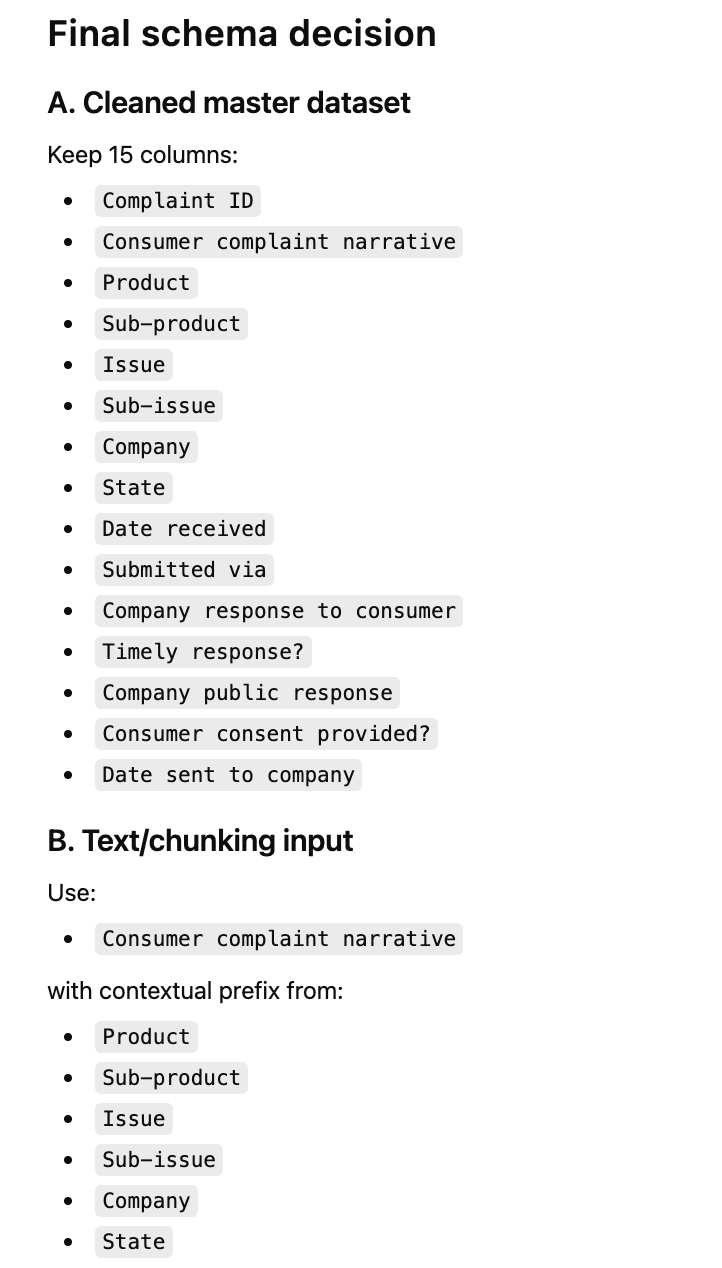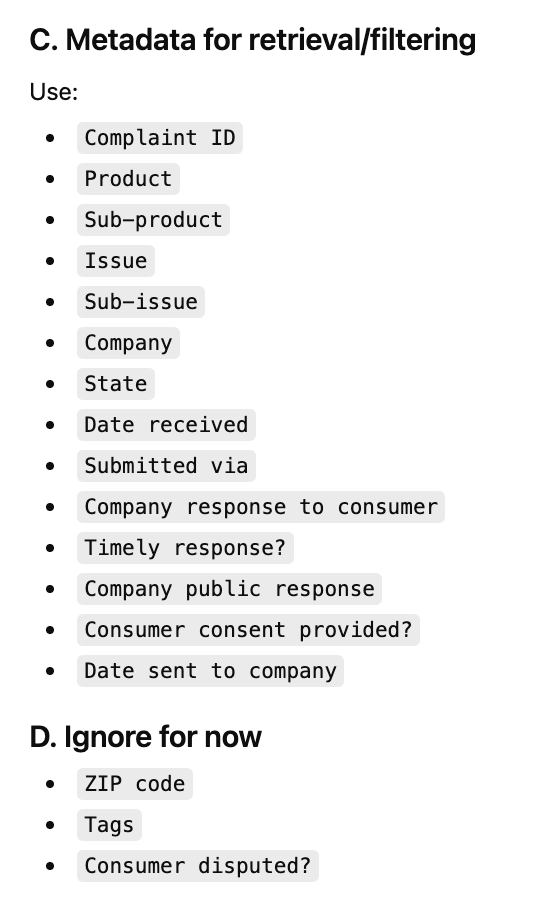

# **Step 15 — Define the exact preprocessing rules column by column**

Now we are no longer deciding what to keep.
Now we decide exactly how each kept column should be cleaned and handled.

We should define this before writing the preprocessing code.

**Rule 1 — Keep only the version 1 columns**

Our preprocessing pipeline should first reduce the dataset to these columns:

* Complaint ID
* Consumer complaint narrative
* Product
* Sub-product
* Issue
* Sub-issue
* Company
* State
* Date received
* Submitted via
* Company response to consumer
* Timely response?
* Company public response
* Consumer consent provided?
* Date sent to company

**Rule 2 — Create two outputs**

Our preprocessing should create:

1. Output A — cleaned master complaint table

* One row per complaint.

2. Output B — retrieval-ready table

   Also one row per complaint for now, with:

* complaint id
* final retrieval text
* metadata fields


3. Rule 3 — Rows without narrative should not go into retrieval

Since the main retrieval text is the complaint narrative:

* rows with missing/blank Consumer complaint narrative should be excluded from the retrieval-ready table, but they may still remain in the cleaned master table

For this project:

* master table: keep all kept rows
* retrieval table: keep only rows with non-null, non-blank narrative

In [ ]:
columns_to_keep = [
    "Complaint ID",
    "Consumer complaint narrative",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

master_df = pd.read_csv(file_path, usecols=columns_to_keep, low_memory=False)

In [ ]:
master_df.head()

# **Step 16 — preprocessing code**

**Column 1 — Complaint ID**

Preprocessing steps for this column:
1. Keep the column.
2. Convert it to string.
3. Remove leading and trailing spaces.
4. Check whether any values become blank after cleaning.
5. Keep it as the unique identifier for both tables.
6. Do not change the value format beyond that.

In [ ]:
# Process Complaint ID

master_df["Complaint ID"] = master_df["Complaint ID"].astype(str).str.strip()

# If the original value was missing, astype(str) may turn it into "nan"
master_df["Complaint ID"] = master_df["Complaint ID"].replace("nan", pd.NA)

# Quick check
print("Null Complaint ID count:", master_df["Complaint ID"].isna().sum())
print("Blank Complaint ID count:", (master_df["Complaint ID"].fillna("").str.strip() == "").sum())

master_df["Complaint ID"].head()

**Column 2 — Consumer complaint narrative**

Preprocessing steps for this column
1. Keep the column.
2. Preserve the original text content.
3. Remove leading and trailing spaces.
4. Normalize repeated whitespace:
5. convert line breaks / tabs to spaces
6. collapse multiple spaces into a single space
7. Convert blank strings to missing values.
8. Keep XXXX exactly as it is.
9. Do not lowercase the text.
10. Do not remove punctuation.
11. Do not rewrite or summarize the text.

In [ ]:
# Process Consumer complaint narrative

master_df["Consumer complaint narrative"] = (
    master_df["Consumer complaint narrative"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Consumer complaint narrative"] = master_df["Consumer complaint narrative"].replace("", pd.NA)

# Quick checks
print("Null narrative count:", master_df["Consumer complaint narrative"].isna().sum())
print("Blank narrative count:", (master_df["Consumer complaint narrative"].fillna("").str.strip() == "").sum())

# Show a few non-null cleaned samples
print(master_df["Consumer complaint narrative"].dropna().head(3).tolist())

**Column 3 — Product**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can still preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize category names yet.

In [ ]:
# Process Product

master_df["Product"] = (
    master_df["Product"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Product"] = master_df["Product"].replace("", pd.NA)

# Quick checks
print("Null Product count:", master_df["Product"].isna().sum())
print("Blank Product count:", (master_df["Product"].fillna("").str.strip() == "").sum())
print("Unique Product count:", master_df["Product"].nunique(dropna=True))

print(master_df["Product"].dropna().head(10).tolist())

**Column 4 — Sub-product**

Preprocessing steps for this column:
1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize historical naming differences yet.
8. Preserve missing values, since this column is optional for some rows.

In [ ]:
# Process Sub-product

master_df["Sub-product"] = (
    master_df["Sub-product"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Sub-product"] = master_df["Sub-product"].replace("", pd.NA)

# Quick checks
print("Null Sub-product count:", master_df["Sub-product"].isna().sum())
print("Blank Sub-product count:", (master_df["Sub-product"].fillna("").str.strip() == "").sum())
print("Unique Sub-product count:", master_df["Sub-product"].nunique(dropna=True))

print(master_df["Sub-product"].dropna().head(10).tolist())

**Column 5 — Issue**

Preprocessing steps for this column:
1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize category names yet.

In [ ]:
# Process Issue

master_df["Issue"] = (
    master_df["Issue"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Issue"] = master_df["Issue"].replace("", pd.NA)

# Quick checks
print("Null Issue count:", master_df["Issue"].isna().sum())
print("Blank Issue count:", (master_df["Issue"].fillna("").str.strip() == "").sum())
print("Unique Issue count:", master_df["Issue"].nunique(dropna=True))

print(master_df["Issue"].dropna().head(10).tolist())

**Column 6 — Sub-issue**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize historical naming differences yet.
8. Preserve missing values, since this column is optional for some rows.

In [ ]:
# Process Sub-issue

master_df["Sub-issue"] = (
    master_df["Sub-issue"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Sub-issue"] = master_df["Sub-issue"].replace("", pd.NA)

# Quick checks
print("Null Sub-issue count:", master_df["Sub-issue"].isna().sum())
print("Blank Sub-issue count:", (master_df["Sub-issue"].fillna("").str.strip() == "").sum())
print("Unique Sub-issue count:", master_df["Sub-issue"].nunique(dropna=True))

print(master_df["Sub-issue"].dropna().head(10).tolist())

**Column 7 — Company**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize company-name variants yet.
8. Preserve the original company label for now.

In [ ]:
# Process Company

master_df["Company"] = (
    master_df["Company"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Company"] = master_df["Company"].replace("", pd.NA)

# Quick checks
print("Null Company count:", master_df["Company"].isna().sum())
print("Blank Company count:", (master_df["Company"].fillna("").str.strip() == "").sum())
print("Unique Company count:", master_df["Company"].nunique(dropna=True))

print(master_df["Company"].dropna().head(10).tolist())

**Column 8 — State**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original uppercase state codes.
7. Preserve missing values.

In [ ]:
# Process State

master_df["State"] = (
    master_df["State"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["State"] = master_df["State"].replace("", pd.NA)

# Quick checks
print("Null State count:", master_df["State"].isna().sum())
print("Blank State count:", (master_df["State"].fillna("").str.strip() == "").sum())
print("Unique State count:", master_df["State"].nunique(dropna=True))

print(master_df["State"].dropna().head(10).tolist())

**Column 9 — Date received**

Preprocessing steps for this column:

1. Keep the column.
2. Parse it to datetime.
3. Coerce invalid values to missing, though we already know this column was fully valid.
4. Preserve missing values if any appear.
5. Do not convert it to text for now.
6. Keep it as the main date field for metadata/filtering.

In [ ]:
# Process Date received

master_df["Date received"] = pd.to_datetime(
    master_df["Date received"],
    errors="coerce"
)

# Quick checks
print("Null Date received count:", master_df["Date received"].isna().sum())
print("Min Date received:", master_df["Date received"].min())
print("Max Date received:", master_df["Date received"].max())
print("Dtype:", master_df["Date received"].dtype)

master_df["Date received"].head()

**Column 10 — Submitted via**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize categories yet.

In [ ]:
# Process Submitted via

master_df["Submitted via"] = (
    master_df["Submitted via"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Submitted via"] = master_df["Submitted via"].replace("", pd.NA)

# Quick checks
print("Null Submitted via count:", master_df["Submitted via"].isna().sum())
print("Blank Submitted via count:", (master_df["Submitted via"].fillna("").str.strip() == "").sum())
print("Unique Submitted via count:", master_df["Submitted via"].nunique(dropna=True))

print(master_df["Submitted via"].dropna().head(10).tolist())

**Column 11 — Company response to consumer**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize categories yet.
8. Preserve missing values if any.

In [ ]:
# Process Company response to consumer

master_df["Company response to consumer"] = (
    master_df["Company response to consumer"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Company response to consumer"] = master_df["Company response to consumer"].replace("", pd.NA)

# Quick checks
print("Null Company response to consumer count:", master_df["Company response to consumer"].isna().sum())
print("Blank Company response to consumer count:", (master_df["Company response to consumer"].fillna("").str.strip() == "").sum())
print("Unique Company response to consumer count:", master_df["Company response to consumer"].nunique(dropna=True))

print(master_df["Company response to consumer"].dropna().head(10).tolist())

**Column 12 — Timely response?**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original Yes / No wording for now.
7. Do not convert to boolean yet.

In [ ]:
# Process Timely response?

master_df["Timely response?"] = (
    master_df["Timely response?"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Timely response?"] = master_df["Timely response?"].replace("", pd.NA)

# Quick checks
print("Null Timely response count:", master_df["Timely response?"].isna().sum())
print("Blank Timely response count:", (master_df["Timely response?"].fillna("").str.strip() == "").sum())
print("Unique Timely response count:", master_df["Timely response?"].nunique(dropna=True))

print(master_df["Timely response?"].dropna().head(10).tolist())

**Column 13 — Company public response**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize categories yet.
8. Preserve missing values.

In [ ]:
# Process Company public response

master_df["Company public response"] = (
    master_df["Company public response"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Company public response"] = master_df["Company public response"].replace("", pd.NA)

# Quick checks
print("Null Company public response count:", master_df["Company public response"].isna().sum())
print("Blank Company public response count:", (master_df["Company public response"].fillna("").str.strip() == "").sum())
print("Unique Company public response count:", master_df["Company public response"].nunique(dropna=True))

print(master_df["Company public response"].dropna().head(10).tolist())

**Column 14 — Consumer consent provided?**

Preprocessing steps for this column:

1. Keep the column.
2. Convert to string type that can preserve missing values.
3. Remove leading and trailing spaces.
4. Collapse repeated internal spaces.
5. Convert blank strings to missing values.
6. Keep the original wording and capitalization.
7. Do not normalize categories yet.
8. Preserve missing values.

In [ ]:
# Process Consumer consent provided?

master_df["Consumer consent provided?"] = (
    master_df["Consumer consent provided?"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert empty strings to missing
master_df["Consumer consent provided?"] = master_df["Consumer consent provided?"].replace("", pd.NA)

# Quick checks
print("Null Consumer consent provided count:", master_df["Consumer consent provided?"].isna().sum())
print("Blank Consumer consent provided count:", (master_df["Consumer consent provided?"].fillna("").str.strip() == "").sum())
print("Unique Consumer consent provided count:", master_df["Consumer consent provided?"].nunique(dropna=True))

print(master_df["Consumer consent provided?"].dropna().head(10).tolist())

**Column 15 — Date sent to company**

Preprocessing steps for this column:

1. Keep the column.
2. Parse it to datetime.
3. Coerce invalid values to missing.
4. Preserve missing values if any appear.
5. Do not convert it to text for now.
6. Keep it as secondary date metadata.

In [ ]:
# Process Date sent to company

master_df["Date sent to company"] = pd.to_datetime(
    master_df["Date sent to company"],
    errors="coerce"
)

# Quick checks
print("Null Date sent to company count:", master_df["Date sent to company"].isna().sum())
print("Min Date sent to company:", master_df["Date sent to company"].min())
print("Max Date sent to company:", master_df["Date sent to company"].max())
print("Dtype:", master_df["Date sent to company"].dtype)

master_df["Date sent to company"].head()

# **Step 17 — Build two final datasets**

We now have two tables to build:

1. Cleaned master table
2. Retrieval-ready table

**Table 1 — Cleaned master table**

What we want for this table:

* one row per original complaint
* all selected version-1 columns
* all rows kept, including rows without narratives
cleaned column values
* no rows removed

**Step M1 — Final check of the cleaned master table**

What we want to do?

1. Confirm the table still has all rows
2. Confirm the selected columns are present
3. Confirm Complaint ID is still unique
4. Confirm the table is ready to save

In [ ]:
# Final check of cleaned master table

print("Master table shape:", master_df.shape)
print("\nColumns:")
print(master_df.columns.tolist())

print("\nDuplicate Complaint IDs in master table:", master_df["Complaint ID"].duplicated().sum())

print("\nDtypes:")
print(master_df.dtypes)

**Step M2 — Save the cleaned master table**

What we want to do?

1. Save the cleaned master table to Drive
2. Keep it as your version-1 master dataset

In [ ]:
master_output_path = "/content/drive/MyDrive/consumer_complaints_master_v1.csv"

master_df.to_csv(master_output_path, index=False)

print("Saved master table to:", master_output_path)

**Table 2 — Retrieval-ready table**

This is the more important one for RAG.

It will:

* keep only rows with non-null narratives
* build the final retrieval text
* remove exact duplicate retrieval texts
* keep one representative row per exact text
* keep a count of how many complaint IDs mapped to that same text

**Step R1 — Create retrieval base table from rows with narratives only**

What we want to do?

1. start from master_df
2. keep only rows where Consumer complaint narrative is not null
3. create a new dataframe called retrieval_df

In [ ]:
retrieval_df = master_df[master_df["Consumer complaint narrative"].notna()].copy()

print("Retrieval base shape:", retrieval_df.shape)
print("Null narratives in retrieval_df:", retrieval_df["Consumer complaint narrative"].isna().sum())

**Step R2 — Build the final retrieval text field**

What we want to do?

1. Create one final text column for retrieval
2. Use only the fields we decided are useful as semantic context:
    * Product
    * Sub-product
    * Issue
    * Sub-issue
    * Company
    * State
    * Consumer complaint narrative
3. Do not write nan or <NA> into the text
4. Omit any metadata line whose value is missing
5. Keep the complaint narrative at the end as the main body

In [ ]:
def build_retrieval_text(row):
    parts = []

    fields = [
        ("Product", row["Product"]),
        ("Sub-product", row["Sub-product"]),
        ("Issue", row["Issue"]),
        ("Sub-issue", row["Sub-issue"]),
        ("Company", row["Company"]),
        ("State", row["State"]),
    ]

    for label, value in fields:
        if pd.notna(value) and str(value).strip() != "":
            parts.append(f"{label}: {value}")

    # complaint narrative should always exist in retrieval_df, but we still check safely
    if pd.notna(row["Consumer complaint narrative"]) and str(row["Consumer complaint narrative"]).strip() != "":
        parts.append("")
        parts.append("Complaint narrative:")
        parts.append(str(row["Consumer complaint narrative"]).strip())

    return "\n".join(parts)

retrieval_df["retrieval_text"] = retrieval_df.apply(build_retrieval_text, axis=1)

# Quick checks
print("Null retrieval_text count:", retrieval_df["retrieval_text"].isna().sum())
print("Blank retrieval_text count:", (retrieval_df["retrieval_text"].fillna("").str.strip() == "").sum())

for i, txt in enumerate(retrieval_df["retrieval_text"].head(3), 1):
    print(f"\n--- retrieval_text sample {i} ---\n")
    print(txt[:1500])

**Step R3 — Deduplicate exact retrieval texts**

What we want to do?

1. Find rows with exactly the same retrieval_text
2. Keep only one representative row for each exact text
3. Keep a count of how many complaint IDs mapped to that same text
4. Keep one sample Complaint ID as the representative ID
5. Do not remove near-duplicates

In [ ]:
# Group by exact retrieval text
retrieval_dedup_df = (
    retrieval_df
    .groupby("retrieval_text", dropna=False)
    .agg(
        representative_complaint_id=("Complaint ID", "first"),
        complaint_count=("Complaint ID", "count"),
        unique_complaint_ids=("Complaint ID", "nunique"),
        Product=("Product", "first"),
        **{"Sub-product": ("Sub-product", "first")},
        Issue=("Issue", "first"),
        **{"Sub-issue": ("Sub-issue", "first")},
        Company=("Company", "first"),
        State=("State", "first"),
        **{"Date received": ("Date received", "first")},
        **{"Submitted via": ("Submitted via", "first")},
        **{"Company response to consumer": ("Company response to consumer", "first")},
        **{"Timely response?": ("Timely response?", "first")},
        **{"Company public response": ("Company public response", "first")},
        **{"Consumer consent provided?": ("Consumer consent provided?", "first")},
        **{"Date sent to company": ("Date sent to company", "first")}
    )
    .reset_index()
)

# Quick checks
print("Original retrieval_df shape:", retrieval_df.shape)
print("Deduplicated retrieval_dedup_df shape:", retrieval_dedup_df.shape)
print("Rows removed by exact retrieval_text dedup:", len(retrieval_df) - len(retrieval_dedup_df))

print("\nSummary of complaint_count:")
print(retrieval_dedup_df["complaint_count"].describe())

print("\nTop repeated retrieval texts:")
print(
    retrieval_dedup_df[["representative_complaint_id", "complaint_count", "unique_complaint_ids"]]
    .sort_values("complaint_count", ascending=False)
    .head(10)
)

What the result shows:

* original retrieval table: **1,292,265** rows
* deduplicated retrieval table: **1,222,114** rows
* exact retrieval-text duplicates removed: **70,151** rows

That means our exact dedup at the final retrieval-text level removed a meaningful number of repeats, but not an extreme amount. So this is a good balance.

The summary also tells us:

* most retrieval texts are still unique, since the 25%, 50%, and 75% values are all 1
* some complaint texts are repeated a lot, with the highest repeated exact retrieval text appearing 473 times
* since complaint_count and unique_complaint_ids match in the top repeated rows, these are real repeated texts across different complaint IDs, not duplicate IDs

**Step R4 — Finalize and save the retrieval-ready table**

What we want to do

1. Arrange the columns in a clean order
2. Keep:
    * one representative complaint ID
    * complaint count
    * unique complaint ID count
    * retrieval text
    * metadata fields
3. Save the final retrieval-ready table to Drive

In [ ]:
# Final column order
retrieval_final_columns = [
    "representative_complaint_id",
    "complaint_count",
    "unique_complaint_ids",
    "retrieval_text",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

retrieval_dedup_df = retrieval_dedup_df[retrieval_final_columns]

# Final checks
print("Final retrieval table shape:", retrieval_dedup_df.shape)
print("\nColumns:")
print(retrieval_dedup_df.columns.tolist())

print("\nDtypes:")
print(retrieval_dedup_df.dtypes)

# Save
retrieval_output_path = "/content/drive/MyDrive/consumer_complaints_retrieval_v1.csv"
retrieval_dedup_df.to_csv(retrieval_output_path, index=False)

print("\nSaved retrieval table to:", retrieval_output_path)

In [ ]:
retrieval_dedup_df.head(3)

# **Step 18.1 — Create the full chunk table**

**Create chunk_source_df**

What we want to do:

1. Start from retrieval_df
2. Group by exact retrieval_text
3. Keep one representative row per exact retrieval text
4. Keep:
    * representative complaint ID
    * duplicate counts
    * the original Consumer complaint narrative
    * metadata fields
5. This becomes the source table for chunking

In [ ]:
# Step 17.3A — Create chunk_source_df from retrieval_df

chunk_source_df = (
    retrieval_df
    .groupby("retrieval_text", dropna=False)
    .agg(
        representative_complaint_id=("Complaint ID", "first"),
        complaint_count=("Complaint ID", "count"),
        unique_complaint_ids=("Complaint ID", "nunique"),
        retrieval_text=("retrieval_text", "first"),
        **{"Consumer complaint narrative": ("Consumer complaint narrative", "first")},
        Product=("Product", "first"),
        **{"Sub-product": ("Sub-product", "first")},
        Issue=("Issue", "first"),
        **{"Sub-issue": ("Sub-issue", "first")},
        Company=("Company", "first"),
        State=("State", "first"),
        **{"Date received": ("Date received", "first")},
        **{"Submitted via": ("Submitted via", "first")},
        **{"Company response to consumer": ("Company response to consumer", "first")},
        **{"Timely response?": ("Timely response?", "first")},
        **{"Company public response": ("Company public response", "first")},
        **{"Consumer consent provided?": ("Consumer consent provided?", "first")},
        **{"Date sent to company": ("Date sent to company", "first")}
    )
    .reset_index(drop=True)
)

# Quick checks
print("chunk_source_df shape:", chunk_source_df.shape)
print("\nColumns:")
print(chunk_source_df.columns.tolist())

print("\nSample rows:")
print(
    chunk_source_df[
        [
            "representative_complaint_id",
            "complaint_count",
            "unique_complaint_ids",
            "Product",
            "Issue"
        ]
    ].head(5)
)

In [ ]:
# Save
chunk_source_output_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"
chunk_source_df.to_csv(chunk_source_output_path, index=False)

print("\nSaved chunk source table to:", chunk_source_output_path)

In [ ]:
chunk_source_df.shape

In [ ]:
chunk_source_df.head(2)

# **Step 18.2 — Measure retrieval_text token distribution**

In [ ]:
# consumer_complaints_chunk_source_v1.csv
chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    if pd.isna(text):
        return 0
    return len(encoding.encode(str(text)))

token_counts = []

for chunk in pd.read_csv(
    chunk_source_path,
    usecols=["retrieval_text"],
    chunksize=50000,
    low_memory=False
):
    chunk["retrieval_text_token_count"] = chunk["retrieval_text"].apply(count_tokens)
    token_counts.extend(chunk["retrieval_text_token_count"].tolist())

token_series = pd.Series(token_counts)

print(token_series.describe())

print("More than 512 tokens:", (token_series > 512).sum())
print("More than 500 tokens:", (token_series > 500).sum())
print("More than 1000 tokens:", (token_series > 1000).sum())
print("More than 2000 tokens:", (token_series > 2000).sum())
print("More than 4000 tokens:", (token_series > 4000).sum())

total = len(token_series)

print("Percent more than 512 tokens:", (token_series > 512).sum() / total * 100)
print("Percent more than 500 tokens:", (token_series > 500).sum() / total * 100)
print("Percent more than 1000 tokens:", (token_series > 1000).sum() / total * 100)
print("Percent more than 2000 tokens:", (token_series > 2000).sum() / total * 100)
print("Percent more than 4000 tokens:", (token_series > 4000).sum() / total * 100)

retrieval_text contains:
* metadata header + Consumer complaint narrative

* 50% are under 213 tokens
* 75% are under 343 tokens

Because we embed retrieval_text, the chunking decision should be based on retrieval_text token count:
* metadata header token count + narrative token count

Then, if the complete retrieval_text is under 512 tokens, keep it as one retrieval unit.
If the complete retrieval_text is over 512 tokens, chunk only the narrative and add the same metadata header to each chunk.

# **Step 18.3 — Build the chunking function**

**What we want to do in chunking function?**

* check the token count of the full retrieval_text first, because retrieval_text is the final text that would be embedded
* keep rows as one retrieval unit when the full retrieval_text is already within 512 tokens
* only chunk rows where retrieval_text is above 512 tokens
* when chunking is needed, split only the Consumer complaint narrative, not the metadata header
* use the same metadata header for every chunk, so each chunk keeps its Product, Sub-product, Issue, Sub-issue, Company, and State context
* count the metadata header tokens and dynamically calculate how much space is left for the narrative chunk
* use overlap between narrative chunks to preserve context between chunks
* after adding metadata back to each narrative chunk, count the final chunk_text tokens again
* store the final token count in final_chunk_token_count
* make sure every final chunk_text stays within the 512-token limit
* write the output gradually into multiple part files instead of one huge dataframe, to avoid Colab RAM crashes


In [ ]:
MODEL_NAME = "BAAI/bge-small-en-v1.5"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

parts_dir = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_parts"
checkpoint_path = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_checkpoint.json"

os.makedirs(parts_dir, exist_ok=True)

In [ ]:
MAX_TOKENS = 512
SAFETY_MARGIN = 20

DEFAULT_OVERLAP = 50
MIN_NARRATIVE_CHUNK_TOKENS = 100

WRITE_BATCH_SIZE = 500
STATUS_EVERY_N_ROWS = 5000

In [ ]:
def is_missing(value):
    if value is None:
        return True
    text = str(value).strip()
    return text == "" or text.lower() in ["nan", "none", "<na>"]


def count_tokens(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=True))


def count_tokens_no_special(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=False))


def truncate_to_token_limit(text, max_tokens):
    tokens = tokenizer.encode(str(text), add_special_tokens=False)

    if len(tokens) <= max_tokens:
        return str(text)

    truncated_tokens = tokens[:max_tokens]
    return tokenizer.decode(truncated_tokens, skip_special_tokens=True).strip()

In [ ]:
def build_metadata_header(row):
    parts = []

    fields = [
        ("Product", row.get("Product")),
        ("Sub-product", row.get("Sub-product")),
        ("Issue", row.get("Issue")),
        ("Sub-issue", row.get("Sub-issue")),
        ("Company", row.get("Company")),
        ("State", row.get("State")),
    ]

    for label, value in fields:
        if not is_missing(value):
            parts.append(f"{label}: {str(value).strip()}")

    parts.append("")
    parts.append("Complaint narrative:")

    return "\n".join(parts)

In [ ]:
def chunk_narrative_by_available_tokens(narrative, available_tokens, overlap_tokens=50):
    if is_missing(narrative):
        return []

    narrative = str(narrative).strip()
    tokens = tokenizer.encode(narrative, add_special_tokens=False)

    if len(tokens) <= available_tokens:
        return [narrative]

    # Adjusts the overlap value so it does not become too large compared to the chunk size.
    overlap_tokens = min(overlap_tokens, max(0, available_tokens // 4))
    # How far to move forward for the next chunk. Since I want overlap, I do not jump by the full chunk size. I move forward by chunk size minus overlap.
    step = available_tokens - overlap_tokens

    # Just a safeguard. If for some reason the overlap is too large and makes the step zero or negative,
    # I fall back to moving by the full available token size. This prevents the loop from getting stuck.
    if step <= 0:
        step = available_tokens

    # store the final chunk texts
    chunks = []
    # initializes the starting token position for the first chunk
    start = 0

    # keep creating chunks until covering the whole tokenized narrative
    while start < len(tokens):
        # sets the end position for the current chunk
        end = min(start + available_tokens, len(tokens))
        chunk_tokens = tokens[start:end] # slices the token list for the current chunk.
        # converts those tokens back into readable text and removes extra spaces.
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True).strip()

        # checks that the decoded chunk is not empty, and if it is valid, it adds it to the output list.
        if chunk_text:
            chunks.append(chunk_text)

        if end >= len(tokens):
            break

        start += step

    return chunks

In [ ]:
def build_safe_chunk_text(header, narrative_chunk):
    chunk_text = header + "\n" + str(narrative_chunk).strip()
    final_count = count_tokens(chunk_text)

    if final_count <= MAX_TOKENS:
        return chunk_text, final_count, False

    # Last-resort safety: reduce only the narrative part
    header_token_count = count_tokens(header)
    available_for_narrative = MAX_TOKENS - header_token_count - SAFETY_MARGIN

    if available_for_narrative < 1:
        # Extremely unlikely, but safe fallback
        minimal_text = truncate_to_token_limit(chunk_text, MAX_TOKENS - SAFETY_MARGIN)
        return minimal_text, count_tokens(minimal_text), True

    shortened_narrative = truncate_to_token_limit(
        narrative_chunk,
        available_for_narrative
    )

    safe_text = header + "\n" + shortened_narrative
    safe_count = count_tokens(safe_text)

    # Final absolute safeguard
    if safe_count > MAX_TOKENS:
        safe_text = truncate_to_token_limit(safe_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)

    return safe_text, safe_count, True

In [ ]:
# manage checkpointing.
# save the current progress of the chunking pipeline, so if the notebook stops, crashes, or disconnects, we do not have to restart from the beginning.

def load_checkpoint(): # read previous progress
    if os.path.exists(checkpoint_path):
        try:
            if os.path.getsize(checkpoint_path) == 0:
                return {
                    "processed_rows": 0,
                    "total_chunk_rows": 0,
                    "next_part_number": 1
                }

            with open(checkpoint_path, "r") as f:
                return json.load(f)

        except Exception:
            return {
                "processed_rows": 0,
                "total_chunk_rows": 0,
                "next_part_number": 1
            }

    return {
        "processed_rows": 0,
        "total_chunk_rows": 0,
        "next_part_number": 1
    }

# save current progress
def save_checkpoint(processed_rows, total_chunk_rows, next_part_number):
    temp_path = checkpoint_path + ".tmp"

    with open(temp_path, "w") as f:
        json.dump({
            "processed_rows": processed_rows,
            "total_chunk_rows": total_chunk_rows,
            "next_part_number": next_part_number
        }, f)

    os.replace(temp_path, checkpoint_path)

In [ ]:
output_columns = [
    "chunk_id",
    "representative_complaint_id",
    "complaint_count",
    "unique_complaint_ids",
    "chunk_index",
    "chunk_count_for_complaint",
    "retrieval_text_token_count",
    "metadata_header_token_count",
    "available_narrative_tokens",
    "narrative_token_count",
    "final_chunk_token_count",
    "was_chunked",
    "was_truncated",
    "chunk_text",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

In [ ]:
def write_part_file(buffer_rows, next_part_number):
    part_path = os.path.join(
        parts_dir,
        f"bge_chunks_part_{next_part_number:06d}.csv"
    )

    with open(part_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=output_columns)
        writer.writeheader()
        writer.writerows(buffer_rows)

    return part_path


state = load_checkpoint()
processed_rows = state["processed_rows"]
total_chunk_rows = state["total_chunk_rows"]
next_part_number = state["next_part_number"]

print("Resuming from processed_rows:", processed_rows)
print("Total chunk rows already written:", total_chunk_rows)
print("Next part number:", next_part_number)

buffer_rows = []
rows_seen = 0

with open(chunk_source_path, "r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if rows_seen < processed_rows:
            rows_seen += 1
            continue

        retrieval_text = row.get("retrieval_text")
        narrative = row.get("Consumer complaint narrative")

        if is_missing(retrieval_text) or is_missing(narrative):
            processed_rows += 1
            rows_seen += 1
            continue

        retrieval_text_token_count = count_tokens(retrieval_text)

        header = build_metadata_header(row)
        metadata_header_token_count = count_tokens(header)

        available_narrative_tokens = (
            MAX_TOKENS
            - metadata_header_token_count
            - SAFETY_MARGIN
        )

        if available_narrative_tokens < MIN_NARRATIVE_CHUNK_TOKENS:
            available_narrative_tokens = max(1, available_narrative_tokens)

        narrative_token_count = count_tokens(narrative)

        # Case 1: complete retrieval_text fits the model limit
        if retrieval_text_token_count <= MAX_TOKENS:
            narrative_chunks = [str(narrative).strip()]
            was_chunked = False

        # Case 2: retrieval_text is too long, so chunk only the narrative
        else:
            narrative_chunks = chunk_narrative_by_available_tokens(
                narrative,
                available_tokens=available_narrative_tokens,
                overlap_tokens=DEFAULT_OVERLAP
            )
            was_chunked = True

        chunk_count_for_complaint = len(narrative_chunks)

        for chunk_index, narrative_chunk in enumerate(narrative_chunks):
            chunk_text, final_chunk_token_count, was_truncated = build_safe_chunk_text(
                header,
                narrative_chunk
            )

            buffer_rows.append({
                "chunk_id": f'{row["representative_complaint_id"]}_chunk_{chunk_index}',
                "representative_complaint_id": row["representative_complaint_id"],
                "complaint_count": row["complaint_count"],
                "unique_complaint_ids": row["unique_complaint_ids"],
                "chunk_index": chunk_index,
                "chunk_count_for_complaint": chunk_count_for_complaint,
                "retrieval_text_token_count": retrieval_text_token_count,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "narrative_token_count": narrative_token_count,
                "final_chunk_token_count": final_chunk_token_count,
                "was_chunked": was_chunked,
                "was_truncated": was_truncated,
                "chunk_text": chunk_text,
                "Product": row.get("Product"),
                "Sub-product": row.get("Sub-product"),
                "Issue": row.get("Issue"),
                "Sub-issue": row.get("Sub-issue"),
                "Company": row.get("Company"),
                "State": row.get("State"),
                "Date received": row.get("Date received"),
                "Submitted via": row.get("Submitted via"),
                "Company response to consumer": row.get("Company response to consumer"),
                "Timely response?": row.get("Timely response?"),
                "Company public response": row.get("Company public response"),
                "Consumer consent provided?": row.get("Consumer consent provided?"),
                "Date sent to company": row.get("Date sent to company")
            })

            if len(buffer_rows) >= WRITE_BATCH_SIZE:
                part_path = write_part_file(buffer_rows, next_part_number)

                total_chunk_rows += len(buffer_rows)
                next_part_number += 1
                buffer_rows = []

                save_checkpoint(
                    processed_rows,
                    total_chunk_rows,
                    next_part_number
                )

                print("Saved:", part_path)
                gc.collect()

        processed_rows += 1
        rows_seen += 1

        if processed_rows % STATUS_EVERY_N_ROWS == 0:
            print(f"Processed source rows: {processed_rows}")
            print(f"Total chunk rows written: {total_chunk_rows}")
            save_checkpoint(
                processed_rows,
                total_chunk_rows,
                next_part_number
            )
            gc.collect()


if buffer_rows:
    part_path = write_part_file(buffer_rows, next_part_number)

    total_chunk_rows += len(buffer_rows)
    next_part_number += 1
    buffer_rows = []

    print("Saved final part:", part_path)
    gc.collect()

save_checkpoint(processed_rows, total_chunk_rows, next_part_number)

print("Done.")
print("Total source rows processed:", processed_rows)
print("Total chunk rows written:", total_chunk_rows)
print("Next part number:", next_part_number)
print("Parts saved in:", parts_dir)
print("Checkpoint saved to:", checkpoint_path)

In [ ]:
part_files = sorted([
    f for f in os.listdir(parts_dir)
    if f.endswith(".csv")
])

print("Number of part files:", len(part_files))
print("First 3:", part_files[:3])
print("Last 3:", part_files[-3:])

sample_path = os.path.join(parts_dir, part_files[-1])
sample_df = pd.read_csv(sample_path, nrows=10)

print(sample_df.shape)
print(sample_df.columns.tolist())

print("\nMax final_chunk_token_count in sample:")
print(sample_df["final_chunk_token_count"].max())

print("\nSample rows:")
print(sample_df[
    [
        "retrieval_text_token_count",
        "metadata_header_token_count",
        "available_narrative_tokens",
        "final_chunk_token_count",
        "was_chunked",
        "was_truncated",
        "chunk_index",
        "chunk_count_for_complaint"
    ]
])

print("\nSample chunk text:")
print(sample_df["chunk_text"].iloc[0][:1500])

In [ ]:
part_files = sorted([
    os.path.join(parts_dir, f)
    for f in os.listdir(parts_dir)
    if f.endswith(".csv")
])

total_rows = 0
over_limit_rows = 0
chunked_rows = 0
truncated_rows = 0
max_tokens_seen = 0

for path in part_files:
    for df in pd.read_csv(path, chunksize=5000):
        total_rows += len(df)
        over_limit_rows += (df["final_chunk_token_count"] > 512).sum()
        chunked_rows += (df["was_chunked"] == True).sum()
        truncated_rows += (df["was_truncated"] == True).sum()
        max_tokens_seen = max(max_tokens_seen, df["final_chunk_token_count"].max())

print("Total chunk rows:", total_rows)
print("Rows over 512 tokens:", over_limit_rows)
print("Rows created from chunked complaints:", chunked_rows)
print("Rows truncated as last resort:", truncated_rows)
print("Max final_chunk_token_count:", max_tokens_seen)

In [ ]:
# Check how many unique source complaints are represented in the final chunk parts
parts_dir = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_parts"

part_files = sorted([
    os.path.join(parts_dir, f)
    for f in os.listdir(parts_dir)
    if f.endswith(".csv")
])

unique_source_ids = set()
total_rows = 0

for path in part_files:
    for df in pd.read_csv(path, usecols=["representative_complaint_id"], chunksize=10000):
        total_rows += len(df)
        unique_source_ids.update(df["representative_complaint_id"].astype(str).tolist())

print("Total chunk rows:", total_rows)
print("Unique representative complaint IDs:", len(unique_source_ids))

# **Step 19 - Embedding phase - Fixed-sized Chunking**

**Overall Plan:**

1. Confirm embedding input files
    * check how many part files we have
    * inspect columns
    * confirm chunk_text exists
    * confirm token counts are within 512
2. Load the embedding model
    * use BAAI/bge-small-en-v1.5
    * load tokenizer and model
    * check whether GPU is available
3. Test embedding on a very small sample
    * maybe 5–10 chunk texts
    * confirm output shape
    * confirm embeddings are numeric vectors
4. Embed one part file as a test
    * save embeddings for only one part file
    * confirm the output file looks correct
5. Embed all part files gradually
    * use checkpointing
    * save output embedding files one by one
    * avoid RAM crashes
6. Later load embeddings into vector DB
    * probably pgvector, based on what your teammate mentioned

# **Step 19.1 - E1 — Confirm chunk part files before embedding**

Before loading the model, we need to confirm the files are ready.

We want to check:

* number of part files
* first and last file names
* columns in a sample part file
* sample row shape
* max final_chunk_token_count in a sample
* whether chunk_text exists and looks correct

This is just validation. No embedding yet

In [ ]:
parts_dir = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_parts"

part_files = sorted([
    os.path.join(parts_dir, f)
    for f in os.listdir(parts_dir)
    if f.endswith(".csv")
])

print("Number of part files:", len(part_files))
print("First 3 part files:")
print(part_files[:3])

print("\nLast 3 part files:")
print(part_files[-3:])

# Inspect one sample part file
sample_path = part_files[0]
sample_df = pd.read_csv(sample_path, nrows=10)

print("\nSample file:", sample_path)
print("Sample shape:", sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nMax final_chunk_token_count in sample:")
print(sample_df["final_chunk_token_count"].max())

print("\nSample chunk_text:")
print(sample_df["chunk_text"].iloc[0][:1500])

# **Step 19.2 - E2 — Load the embedding model**

What we want to do
* Create a fixed embedding config.
* Load BAAI/bge-small-en-v1.5.
* Check whether GPU is available.
* Confirm embedding dimension.
* Keep normalized embeddings enabled for cosine similarity / inner product later in pgvector.

In [ ]:
# Step E2 — Load embedding model

# Fixed embedding config
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
NORMALIZE_EMBEDDINGS = True
EMBEDDING_DIMENSION = 384
INPUT_COLUMN = "chunk_text"

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load model
model = SentenceTransformer(EMBEDDING_MODEL, device=device)

# Confirm embedding dimension
actual_dimension = model.get_sentence_embedding_dimension()

print("Embedding model:", EMBEDDING_MODEL)
print("Expected embedding dimension:", EMBEDDING_DIMENSION)
print("Actual embedding dimension:", actual_dimension)
print("Normalize embeddings:", NORMALIZE_EMBEDDINGS)

if actual_dimension != EMBEDDING_DIMENSION:
    print("Warning: actual dimension does not match expected dimension.")
else:
    print("Embedding dimension is correct.")

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# **Step 19.3 - E3 — Test embeddings on a tiny sample**

What we want to do

Before embedding a full part file, we test with only a few rows.

We want to confirm:

* chunk_text can be passed to the model
* output shape is correct
* embedding dimension is 384
* embeddings are numeric
* normalized embeddings have norm close to 1

In [ ]:
# Use the first part file for a tiny test
test_part_path = part_files[0]

test_df = pd.read_csv(test_part_path, nrows=5)

texts = test_df[INPUT_COLUMN].astype(str).tolist()

embeddings = model.encode(
    texts,
    batch_size=5,
    normalize_embeddings=NORMALIZE_EMBEDDINGS,
    show_progress_bar=True
)

embeddings = np.array(embeddings)

print("Input rows:", len(texts))
print("Embedding shape:", embeddings.shape)
print("Embedding dtype:", embeddings.dtype)

# Check norms because we are normalizing embeddings
norms = np.linalg.norm(embeddings, axis=1)
print("Embedding norms:", norms)

print("\nFirst embedding first 10 values:")
print(embeddings[0][:10])

# **Step 19.4 - E4 — Embed one full part file as a test and save it**

What we want to do

Before embedding all 2,884 part files, we test only one full part file.

We will:

* read one part file
* embed its chunk_text
* save the embeddings with metadata
* confirm output shape
* confirm saved file can be read back

In [ ]:
embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_bge_embeddings_v1_parts"
os.makedirs(embedding_output_dir, exist_ok=True)

test_part_path = part_files[0]
test_part_name = os.path.basename(test_part_path).replace(".csv", "")

test_df = pd.read_csv(test_part_path)

print("Input file:", test_part_path)
print("Input shape:", test_df.shape)

texts = test_df[INPUT_COLUMN].astype(str).tolist()

embeddings = model.encode(
    texts,
    batch_size=64,
    normalize_embeddings=NORMALIZE_EMBEDDINGS,
    show_progress_bar=True
)

embeddings = np.asarray(embeddings, dtype=np.float32)

print("Embedding shape:", embeddings.shape)
print("Embedding dtype:", embeddings.dtype)

# Store embedding as a list in one column
test_df["embedding"] = embeddings.tolist()

output_path = os.path.join(
    embedding_output_dir,
    test_part_name + "_embeddings.parquet"
)

test_df.to_parquet(output_path, index=False)

print("Saved embedding test file to:", output_path)

# Read back small sample to confirm
check_df = pd.read_parquet(output_path)
print("Saved file shape:", check_df.shape)
print("Embedding length of first row:", len(check_df["embedding"].iloc[0]))
print("First embedding first 5 values:", check_df["embedding"].iloc[0][:5])

# **Step 19.5 - Embed all part files gradually with checkpointing**

What we want to do
* Process each chunk part file one by one.
* Skip files that were already embedded.
* Save each embedded file as a separate Parquet file.
* Use checkpointing so if Colab disconnects, we can resume.
* Avoid loading all data into memory.

In [ ]:
embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_bge_embeddings_v1_parts"
embedding_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_bge_embeddings_v1_checkpoint.json"

os.makedirs(embedding_output_dir, exist_ok=True)

# how many chunk texts is sending to the embedding model at one time
EMBED_BATCH_SIZE = 64

def load_embedding_checkpoint():
    if os.path.exists(embedding_checkpoint_path):
        try:
            with open(embedding_checkpoint_path, "r") as f:
                return json.load(f)
        except Exception:
            return {"completed_files": []}
    return {"completed_files": []}

def save_embedding_checkpoint(completed_files):
    temp_path = embedding_checkpoint_path + ".tmp"
    with open(temp_path, "w") as f:
        json.dump({"completed_files": completed_files}, f)
    os.replace(temp_path, embedding_checkpoint_path)

state = load_embedding_checkpoint()
completed_files = set(state["completed_files"])

print("Already completed files:", len(completed_files))
print("Total part files:", len(part_files))

# embedding loop
for i, input_path in enumerate(part_files, 1):
    input_name = os.path.basename(input_path)
    output_name = input_name.replace(".csv", "_embeddings.parquet")
    output_path = os.path.join(embedding_output_dir, output_name)

    if input_name in completed_files or os.path.exists(output_path):
        completed_files.add(input_name)
        continue

    print(f"\nEmbedding file {i}/{len(part_files)}: {input_name}")

    df = pd.read_csv(input_path)
    # INPUT_COLUMN is chunk_text
    texts = df[INPUT_COLUMN].astype(str).tolist()

    embeddings = model.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        normalize_embeddings=NORMALIZE_EMBEDDINGS,
        show_progress_bar=True
    )

    # convert embeddings to float
    embeddings = np.asarray(embeddings, dtype=np.float32)
    df["embedding"] = embeddings.tolist()

    df.to_parquet(output_path, index=False)

    # update the checkpoint
    completed_files.add(input_name)
    save_embedding_checkpoint(sorted(completed_files))

    print("Saved:", output_path)
    print("Completed:", len(completed_files), "/", len(part_files))

    del df
    del texts
    del embeddings
    # free Python memory
    gc.collect()

    if torch.cuda.is_available():
        # release cached GPU memory
        torch.cuda.empty_cache()

print("\nDone.")
print("Total completed files:", len(completed_files))
print("Output directory:", embedding_output_dir)

# **Step 20 - Recursive Character Chunking**

# **Step 20.1 - Confirm the source file before chunking**

What we want to check:

1. The file exists.
2. We can read a small sample.
3. The required columns are available:
    * representative_complaint_id
    * complaint_count
    * unique_complaint_ids
    * retrieval_text
    * Consumer complaint narrative
    * metadata columns like Product, Issue, Company, State
4. The sample looks normal.

In [ ]:
chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

print("File exists:", os.path.exists(chunk_source_path))

sample_source_df = pd.read_csv(chunk_source_path, nrows=5, low_memory=False)

print("Sample shape:", sample_source_df.shape)

print("\nColumns:")
print(sample_source_df.columns.tolist())

print("\nSample rows:")
print(
    sample_source_df[
        [
            "representative_complaint_id",
            "complaint_count",
            "unique_complaint_ids",
            "Product",
            "Issue",
            "Company",
            "State"
        ]
    ]
)

print("\nSample retrieval_text:")
print(sample_source_df["retrieval_text"].iloc[0][:1000])

print("\nSample narrative:")
print(sample_source_df["Consumer complaint narrative"].iloc[0][:1000])

# **Step 20.2 - load the BGE tokenizer and define the recursive chunking settings**

In this step, we define:

* model name
* tokenizer
* max token limit
* safety margin
* overlap size
* separators for recursive splitting

In [ ]:
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

MAX_TOKENS = 512
SAFETY_MARGIN = 20

# Overlap is in approximate characters for recursive character chunking
# We will still validate by tokens after adding metadata.
CHAR_OVERLAP = 50

# Separators from most natural to least natural
RECURSIVE_SEPARATORS = [
    "\n\n",   # paragraph break
    "\n",     # line break
    ". ",     # sentence ending
    "? ",
    "! ",
    "; ",
    ", ",
    " ",      # word boundary
    ""        # character fallback
]

print("Tokenizer loaded for:", EMBEDDING_MODEL)
print("Max tokens:", MAX_TOKENS)
print("Safety margin:", SAFETY_MARGIN)
print("Character overlap:", CHAR_OVERLAP)
print("Separators:", RECURSIVE_SEPARATORS)

# **Step 20.3 - Create helper functions**

What we want to define

We need functions for:

* checking missing values
* counting BGE tokens
* building the metadata header
* checking whether final text fits within 512 tokens
* recursively splitting narrative text by natural boundaries

For now, we only define and test the helper functions on a small sample. We are not processing the full dataset yet.

In [ ]:
def is_missing(value):
    if value is None:
        return True
    text = str(value).strip()
    return text == "" or text.lower() in ["nan", "none", "<na>"]


def count_tokens(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=True))


def count_tokens_no_special(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=False))


def build_metadata_header(row):
    parts = []

    fields = [
        ("Product", row.get("Product")),
        ("Sub-product", row.get("Sub-product")),
        ("Issue", row.get("Issue")),
        ("Sub-issue", row.get("Sub-issue")),
        ("Company", row.get("Company")),
        ("State", row.get("State")),
    ]

    for label, value in fields:
        if not is_missing(value):
            parts.append(f"{label}: {str(value).strip()}")

    parts.append("")
    parts.append("Complaint narrative:")

    return "\n".join(parts)


def final_text_token_count(header, narrative_piece):
    final_text = header + "\n" + str(narrative_piece).strip()
    return count_tokens(final_text)

In [ ]:
# Quick helper test

sample_row = sample_source_df.iloc[0].to_dict()

sample_header = build_metadata_header(sample_row)
sample_narrative = sample_row["Consumer complaint narrative"]
sample_final_text = sample_header + "\n" + sample_narrative

print("Metadata header:")
print(sample_header)

print("\nHeader token count:", count_tokens(sample_header))
print("Narrative token count:", count_tokens(sample_narrative))
print("Final text token count:", count_tokens(sample_final_text))

print("\nFinal text preview:")
print(sample_final_text[:1000])

# **Step 20.4 - create the recursive character splitter itself**

What we want this function to do?

This function will:

1. Take a narrative text.
2. Try to split it using natural separators first:
* paragraph breaks
* line breaks
* sentence endings
* commas
* spaces
3. Avoid cutting randomly when better separators exist
4. Build chunks that fit the available token budget after metadata
5. Use character overlap between chunks
6. Still validate final token count later

In [ ]:
# Step RC4 — Revised recursive character splitter with word-based overlap

def split_text_by_separator(text, separator):
    if separator == "":
        return list(text)

    parts = text.split(separator)

    # Add the separator back except for the last piece
    result = []
    for i, part in enumerate(parts):
        if i < len(parts) - 1:
            result.append(part + separator)
        else:
            result.append(part)

    return [p for p in result if p.strip()]


def recursive_split_text(text, max_piece_tokens, separators=RECURSIVE_SEPARATORS):
    text = str(text).strip()

    if count_tokens(text) <= max_piece_tokens:
        return [text]

    if not separators:
        return [text]

    separator = separators[0]
    remaining_separators = separators[1:]

    pieces = split_text_by_separator(text, separator)

    # If this separator does not split the text, try the next separator
    if len(pieces) == 1:
        return recursive_split_text(text, max_piece_tokens, remaining_separators)

    final_pieces = []

    for piece in pieces:
        piece = piece.strip()
        if not piece:
            continue

        if count_tokens(piece) <= max_piece_tokens:
            final_pieces.append(piece)
        else:
            smaller_pieces = recursive_split_text(
                piece,
                max_piece_tokens,
                remaining_separators
            )
            final_pieces.extend(smaller_pieces)

    return [p for p in final_pieces if p.strip()]


def get_word_overlap(text, max_words=50):
    words = str(text).strip().split()

    if len(words) <= max_words:
        return " ".join(words)

    return " ".join(words[-max_words:])


def combine_pieces_with_overlap(pieces, max_piece_tokens, word_overlap=50):
    chunks = []
    current = ""

    for piece in pieces:
        piece = str(piece).strip()
        if not piece:
            continue

        candidate = (current + " " + piece).strip() if current else piece

        if count_tokens(candidate) <= max_piece_tokens:
            current = candidate
        else:
            if current:
                chunks.append(current.strip())

            # Word-based overlap to avoid starting in the middle of words
            if current and word_overlap > 0:
                overlap_text = get_word_overlap(current, max_words=word_overlap)
                candidate_with_overlap = (overlap_text + " " + piece).strip()

                if count_tokens(candidate_with_overlap) <= max_piece_tokens:
                    current = candidate_with_overlap
                else:
                    current = piece
            else:
                current = piece

    if current:
        chunks.append(current.strip())

    return chunks


def recursive_character_chunk_narrative(narrative, available_narrative_tokens):
    if is_missing(narrative):
        return []

    narrative = str(narrative).strip()

    if count_tokens(narrative) <= available_narrative_tokens:
        return [narrative]

    pieces = recursive_split_text(
        narrative,
        max_piece_tokens=available_narrative_tokens,
        separators=RECURSIVE_SEPARATORS
    )

    chunks = combine_pieces_with_overlap(
        pieces,
        max_piece_tokens=available_narrative_tokens,
        word_overlap=50
    )

    return chunks

In [ ]:
# Step RC4 — Test recursive splitter

# Short sample
short_row = sample_source_df.iloc[0].to_dict()
short_header = build_metadata_header(short_row)
short_header_tokens = count_tokens(short_header)
short_available_tokens = MAX_TOKENS - short_header_tokens - SAFETY_MARGIN

short_chunks = recursive_character_chunk_narrative(
    short_row["Consumer complaint narrative"],
    available_narrative_tokens=short_available_tokens
)

print("Short sample:")
print("Header tokens:", short_header_tokens)
print("Available narrative tokens:", short_available_tokens)
print("Number of chunks:", len(short_chunks))
print("Chunk token counts:", [count_tokens(c) for c in short_chunks])


# Longer sample from source file
long_sample_df = pd.read_csv(
    chunk_source_path,
    usecols=[
        "representative_complaint_id",
        "retrieval_text",
        "Consumer complaint narrative",
        "Product",
        "Sub-product",
        "Issue",
        "Sub-issue",
        "Company",
        "State"
    ],
    nrows=5000,
    low_memory=False
)

long_sample_df["retrieval_tokens"] = long_sample_df["retrieval_text"].apply(count_tokens)
long_row = long_sample_df.sort_values("retrieval_tokens", ascending=False).iloc[0].to_dict()

long_header = build_metadata_header(long_row)
long_header_tokens = count_tokens(long_header)
long_available_tokens = MAX_TOKENS - long_header_tokens - SAFETY_MARGIN

long_chunks = recursive_character_chunk_narrative(
    long_row["Consumer complaint narrative"],
    available_narrative_tokens=long_available_tokens
)

print("\nLong sample:")
print("Representative complaint ID:", long_row["representative_complaint_id"])
print("Original retrieval_text tokens:", long_row["retrieval_tokens"])
print("Header tokens:", long_header_tokens)
print("Available narrative tokens:", long_available_tokens)
print("Number of chunks:", len(long_chunks))
print("Narrative chunk token counts:", [count_tokens(c) for c in long_chunks[:10]])

for i, ch in enumerate(long_chunks[:3], 1):
    final_text = long_header + "\n" + ch
    print(f"\n--- Final chunk {i} token count:", count_tokens(final_text), "---")
    print(final_text[:1000])

# **Step 20.5 - Build the final safe chunk text**

What this step does?

For each narrative chunk:

1. Add the metadata header back.
2. Count the final chunk_text tokens.
3. Confirm it is <= 512.
4. If somehow it is still over 512, reduce only the narrative part.
5. Store:
    * final_chunk_token_count
    * was_chunked
    * was_truncated




In [ ]:
# Step RC5 — Build safe final chunk text

def truncate_to_token_limit(text, max_tokens):
    tokens = tokenizer.encode(str(text), add_special_tokens=False)

    if len(tokens) <= max_tokens:
        return str(text)

    truncated_tokens = tokens[:max_tokens]
    return tokenizer.decode(truncated_tokens, skip_special_tokens=True).strip()


def build_safe_chunk_text(header, narrative_chunk):
    chunk_text = header + "\n" + str(narrative_chunk).strip()
    final_count = count_tokens(chunk_text)

    if final_count <= MAX_TOKENS:
        return chunk_text, final_count, False

    # Last-resort safety: reduce only the narrative part
    header_token_count = count_tokens(header)
    available_for_narrative = MAX_TOKENS - header_token_count - SAFETY_MARGIN

    if available_for_narrative < 1:
        # Extremely rare fallback
        safe_text = truncate_to_token_limit(chunk_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)
        return safe_text, safe_count, True

    shortened_narrative = truncate_to_token_limit(
        narrative_chunk,
        available_for_narrative
    )

    safe_text = header + "\n" + shortened_narrative
    safe_count = count_tokens(safe_text)

    # Final absolute safeguard
    if safe_count > MAX_TOKENS:
        safe_text = truncate_to_token_limit(safe_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)

    return safe_text, safe_count, True

In [ ]:
# Step RC5 — Test final safe chunk text

final_chunk_results = []

for i, narrative_chunk in enumerate(long_chunks):
    final_text, final_token_count, was_truncated = build_safe_chunk_text(
        long_header,
        narrative_chunk
    )

    final_chunk_results.append({
        "chunk_index": i,
        "final_chunk_token_count": final_token_count,
        "was_truncated": was_truncated,
        "preview": final_text[:300]
    })

final_chunk_results

# **Step 20.6 - Create recursive chunk part files for full dataset**

For each row in:

consumer_complaints_chunk_source_v1.csv

* Check retrieval_text token count.
* If retrieval_text <= 512, keep it as one retrieval unit.
* If retrieval_text > 512, split only the narrative using Recursive Character Chunking.
* Add the metadata header to every chunk.
* Check final chunk_text token count.
* Keep everything under the 512-token limit.
* Save results gradually into part files to avoid RAM crashes.
* Save a checkpoint so you can resume if Colab disconnects.

In [ ]:
# Input source file
chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

# New output folder for Recursive Character Chunking
recursive_parts_dir = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_parts"
# recursive checkpoint path
recursive_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_checkpoint.json"

os.makedirs(recursive_parts_dir, exist_ok=True)

# Batch settings
WRITE_BATCH_SIZE = 500
STATUS_EVERY_N_ROWS = 5000

# Output columns
recursive_output_columns = [
    "chunk_id",
    "representative_complaint_id",
    "complaint_count",
    "unique_complaint_ids",
    "chunk_index",
    "chunk_count_for_complaint",
    "chunking_method",
    "retrieval_text_token_count",
    "metadata_header_token_count",
    "available_narrative_tokens",
    "narrative_token_count",
    "final_chunk_token_count",
    "was_chunked",
    "was_truncated",
    "chunk_text",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]


def load_recursive_checkpoint():
    if os.path.exists(recursive_checkpoint_path):
        try:
            if os.path.getsize(recursive_checkpoint_path) == 0:
                return {
                    "processed_rows": 0,
                    "total_chunk_rows": 0,
                    "next_part_number": 1
                }

            with open(recursive_checkpoint_path, "r") as f:
                return json.load(f)

        except Exception:
            return {
                "processed_rows": 0,
                "total_chunk_rows": 0,
                "next_part_number": 1
            }

    return {
        "processed_rows": 0,
        "total_chunk_rows": 0,
        "next_part_number": 1
    }


def save_recursive_checkpoint(processed_rows, total_chunk_rows, next_part_number):
    temp_path = recursive_checkpoint_path + ".tmp"

    with open(temp_path, "w") as f:
        json.dump({
            "processed_rows": processed_rows,
            "total_chunk_rows": total_chunk_rows,
            "next_part_number": next_part_number
        }, f)

    os.replace(temp_path, recursive_checkpoint_path)


def write_recursive_part_file(buffer_rows, next_part_number):
    part_path = os.path.join(
        recursive_parts_dir,
        f"recursive_chunks_part_{next_part_number:06d}.csv"
    )

    with open(part_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=recursive_output_columns)
        writer.writeheader()
        writer.writerows(buffer_rows)

    return part_path

In [ ]:
state = load_recursive_checkpoint()

processed_rows = state["processed_rows"]
total_chunk_rows = state["total_chunk_rows"]
next_part_number = state["next_part_number"]

print("Resuming from processed_rows:", processed_rows)
print("Total chunk rows already written:", total_chunk_rows)
print("Next part number:", next_part_number)

buffer_rows = []
rows_seen = 0

with open(chunk_source_path, "r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)

    for row in reader:
        # Skip rows already processed
        if rows_seen < processed_rows:
            rows_seen += 1
            continue

        retrieval_text = row.get("retrieval_text")
        narrative = row.get("Consumer complaint narrative")

        if is_missing(retrieval_text) or is_missing(narrative):
            processed_rows += 1
            rows_seen += 1
            continue

        retrieval_text_token_count = count_tokens(retrieval_text)

        header = build_metadata_header(row)
        metadata_header_token_count = count_tokens(header)

        available_narrative_tokens = (
            MAX_TOKENS
            - metadata_header_token_count
            - SAFETY_MARGIN
        )

        narrative_token_count = count_tokens(narrative)

        # Case 1: complete retrieval_text already fits the BGE 512-token limit
        if retrieval_text_token_count <= MAX_TOKENS:
            narrative_chunks = [str(narrative).strip()]
            was_chunked = False

        # Case 2: retrieval_text is too long, so use Recursive Character Chunking
        else:
            narrative_chunks = recursive_character_chunk_narrative(
                narrative,
                available_narrative_tokens=available_narrative_tokens
            )
            was_chunked = True

        chunk_count_for_complaint = len(narrative_chunks)

        for chunk_index, narrative_chunk in enumerate(narrative_chunks):
            chunk_text, final_chunk_token_count, was_truncated = build_safe_chunk_text(
                header,
                narrative_chunk
            )

            buffer_rows.append({
                "chunk_id": f'{row["representative_complaint_id"]}_chunk_{chunk_index}',
                "representative_complaint_id": row["representative_complaint_id"],
                "complaint_count": row["complaint_count"],
                "unique_complaint_ids": row["unique_complaint_ids"],
                "chunk_index": chunk_index,
                "chunk_count_for_complaint": chunk_count_for_complaint,
                "chunking_method": "recursive_character",
                "retrieval_text_token_count": retrieval_text_token_count,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "narrative_token_count": narrative_token_count,
                "final_chunk_token_count": final_chunk_token_count,
                "was_chunked": was_chunked,
                "was_truncated": was_truncated,
                "chunk_text": chunk_text,
                "Product": row.get("Product"),
                "Sub-product": row.get("Sub-product"),
                "Issue": row.get("Issue"),
                "Sub-issue": row.get("Sub-issue"),
                "Company": row.get("Company"),
                "State": row.get("State"),
                "Date received": row.get("Date received"),
                "Submitted via": row.get("Submitted via"),
                "Company response to consumer": row.get("Company response to consumer"),
                "Timely response?": row.get("Timely response?"),
                "Company public response": row.get("Company public response"),
                "Consumer consent provided?": row.get("Consumer consent provided?"),
                "Date sent to company": row.get("Date sent to company")
            })

            if len(buffer_rows) >= WRITE_BATCH_SIZE:
                part_path = write_recursive_part_file(
                    buffer_rows,
                    next_part_number
                )

                total_chunk_rows += len(buffer_rows)
                next_part_number += 1
                buffer_rows = []

                save_recursive_checkpoint(
                    processed_rows,
                    total_chunk_rows,
                    next_part_number
                )

                print("Saved:", part_path)
                gc.collect()

        processed_rows += 1
        rows_seen += 1

        if processed_rows % STATUS_EVERY_N_ROWS == 0:
            print(f"Processed source rows: {processed_rows}")
            print(f"Total chunk rows written: {total_chunk_rows}")

            save_recursive_checkpoint(
                processed_rows,
                total_chunk_rows,
                next_part_number
            )

            gc.collect()


# Write remaining rows
if buffer_rows:
    part_path = write_recursive_part_file(
        buffer_rows,
        next_part_number
    )

    total_chunk_rows += len(buffer_rows)
    next_part_number += 1
    buffer_rows = []

    print("Saved final part:", part_path)
    gc.collect()

save_recursive_checkpoint(
    processed_rows,
    total_chunk_rows,
    next_part_number
)

print("Done.")
print("Total source rows processed:", processed_rows)
print("Total chunk rows written:", total_chunk_rows)
print("Next part number:", next_part_number)
print("Parts saved in:", recursive_parts_dir)
print("Checkpoint saved to:", recursive_checkpoint_path)

# **Step 20.7 — Sanity checks for recursive chunk files**

We want to check:

1. number of part files
2. sample columns and sample text
3. total chunk rows
4. unique representative complaint IDs
5. rows over 512 tokens
6. truncation count
7. max final token count
8. chunk count distribution
9. a few examples of chunked complaints

In [ ]:
recursive_parts_dir = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_parts"

recursive_part_files = sorted([
    os.path.join(recursive_parts_dir, f)
    for f in os.listdir(recursive_parts_dir)
    if f.endswith(".csv")
])

print("Number of recursive part files:", len(recursive_part_files))
print("First 3 files:", recursive_part_files[:3])
print("Last 3 files:", recursive_part_files[-3:])

sample_path = recursive_part_files[0]
sample_df = pd.read_csv(sample_path, nrows=10)

print("\nSample file:", sample_path)
print("Sample shape:", sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nSample chunk_text:")
print(sample_df["chunk_text"].iloc[0][:1500])

print("\nSample token/check columns:")
print(sample_df[
    [
        "retrieval_text_token_count",
        "metadata_header_token_count",
        "available_narrative_tokens",
        "narrative_token_count",
        "final_chunk_token_count",
        "was_chunked",
        "was_truncated",
        "chunk_index",
        "chunk_count_for_complaint"
    ]
])

**Full validation across all recursive part files**

In [ ]:
total_rows = 0
unique_source_ids = set()

over_limit_rows = 0
truncated_rows = 0
chunked_rows = 0
max_tokens_seen = 0

chunk_count_values = []

for path in recursive_part_files:
    for df in pd.read_csv(path, chunksize=5000):
        total_rows += len(df)

        unique_source_ids.update(
            df["representative_complaint_id"].astype(str).tolist()
        )

        over_limit_rows += (df["final_chunk_token_count"] > 512).sum()
        truncated_rows += (df["was_truncated"].astype(str).str.lower() == "true").sum()
        chunked_rows += (df["was_chunked"].astype(str).str.lower() == "true").sum()

        max_tokens_seen = max(
            max_tokens_seen,
            df["final_chunk_token_count"].max()
        )

        chunk_count_values.extend(df["chunk_count_for_complaint"].tolist())

print("Total recursive chunk rows:", total_rows)
print("Unique representative complaint IDs:", len(unique_source_ids))
print("Rows over 512 tokens:", over_limit_rows)
print("Rows truncated:", truncated_rows)
print("Rows created from chunked complaints:", chunked_rows)
print("Max final_chunk_token_count:", max_tokens_seen)

chunk_count_series = pd.Series(chunk_count_values)
print("\nChunk count per complaint summary:")
print(chunk_count_series.describe())

**Inspect examples of chunked complaints**

In [ ]:
examples_found = 0

for path in recursive_part_files:
    df = pd.read_csv(path)

    chunked_examples = df[
        (df["was_chunked"].astype(str).str.lower() == "true") &
        (df["chunk_count_for_complaint"] > 1)
    ]

    if not chunked_examples.empty:
        example_id = chunked_examples["representative_complaint_id"].iloc[0]
        example_rows = df[df["representative_complaint_id"] == example_id].sort_values("chunk_index")

        print("Example representative_complaint_id:", example_id)
        print("Number of chunks:", example_rows["chunk_count_for_complaint"].iloc[0])

        for _, row in example_rows.head(3).iterrows():
            print("\n" + "="*80)
            print("Chunk index:", row["chunk_index"])
            print("Final token count:", row["final_chunk_token_count"])
            print(row["chunk_text"][:1200])

        examples_found += 1
        break

if examples_found == 0:
    print("No chunked examples found in checked files.")

# **Step 21 - Embedding phase - Recursive Chunking**

# **Step 21.1 - E1 — Confirm recursive part files**

In [ ]:
recursive_parts_dir = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_parts"

recursive_part_files = sorted([
    os.path.join(recursive_parts_dir, f)
    for f in os.listdir(recursive_parts_dir)
    if f.endswith(".csv")
])

print("Number of recursive part files:", len(recursive_part_files))
print("First 3:", recursive_part_files[:3])
print("Last 3:", recursive_part_files[-3:])

sample_df = pd.read_csv(recursive_part_files[0], nrows=5)
print("Sample shape:", sample_df.shape)
print(sample_df.columns.tolist())
print(sample_df["chunk_text"].iloc[0][:1000])

# **Step 21.2 - E2 — Load the embedding model**

In [ ]:
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
NORMALIZE_EMBEDDINGS = True
EMBEDDING_DIMENSION = 384
INPUT_COLUMN = "chunk_text"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if device == "cuda" else "No GPU")

model = SentenceTransformer(EMBEDDING_MODEL, device=device)

actual_dimension = model.get_sentence_embedding_dimension()

print("Embedding model:", EMBEDDING_MODEL)
print("Expected dimension:", EMBEDDING_DIMENSION)
print("Actual dimension:", actual_dimension)
print("Normalize embeddings:", NORMALIZE_EMBEDDINGS)

# **Step 21.3 - E3 — Test embedding one recursive part file**

In [ ]:
recursive_embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_recursive_bge_embeddings_v1_parts"
os.makedirs(recursive_embedding_output_dir, exist_ok=True)

test_part_path = recursive_part_files[0]
test_part_name = os.path.basename(test_part_path).replace(".csv", "")

test_df = pd.read_csv(test_part_path)

print("Input file:", test_part_path)
print("Input shape:", test_df.shape)

texts = test_df[INPUT_COLUMN].astype(str).tolist()

embeddings = model.encode(
    texts,
    batch_size=64,
    normalize_embeddings=NORMALIZE_EMBEDDINGS,
    show_progress_bar=True
)

embeddings = np.asarray(embeddings, dtype=np.float32)

print("Embedding shape:", embeddings.shape)
print("Embedding dtype:", embeddings.dtype)

test_df["embedding"] = embeddings.tolist()

test_output_path = os.path.join(
    recursive_embedding_output_dir,
    test_part_name + "_embeddings.parquet"
)

test_df.to_parquet(test_output_path, index=False)

print("Saved test embedding file to:", test_output_path)

check_df = pd.read_parquet(test_output_path, columns=["chunk_id", "embedding"])
print("Saved file sample shape:", check_df.shape)
print("Embedding length first row:", len(check_df["embedding"].iloc[0]))
print("First embedding first 5 values:", check_df["embedding"].iloc[0][:5])

# **Step 21.4 - E4 — Embed all recursive chunk files with checkpointing**

In [ ]:
recursive_embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_recursive_bge_embeddings_v1_parts"
recursive_embedding_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_recursive_bge_embeddings_v1_checkpoint.json"

os.makedirs(recursive_embedding_output_dir, exist_ok=True)

EMBED_BATCH_SIZE = 64

def load_recursive_embedding_checkpoint():
    if os.path.exists(recursive_embedding_checkpoint_path):
        try:
            with open(recursive_embedding_checkpoint_path, "r") as f:
                return json.load(f)
        except Exception:
            return {"completed_files": []}
    return {"completed_files": []}


def save_recursive_embedding_checkpoint(completed_files):
    temp_path = recursive_embedding_checkpoint_path + ".tmp"
    with open(temp_path, "w") as f:
        json.dump({"completed_files": completed_files}, f)
    os.replace(temp_path, recursive_embedding_checkpoint_path)


state = load_recursive_embedding_checkpoint()
completed_files = set(state["completed_files"])

print("Already completed files:", len(completed_files))
print("Total recursive part files:", len(recursive_part_files))

for i, input_path in enumerate(recursive_part_files, 1):
    input_name = os.path.basename(input_path)
    output_name = input_name.replace(".csv", "_embeddings.parquet")
    output_path = os.path.join(recursive_embedding_output_dir, output_name)

    # Skip if already completed
    if input_name in completed_files or os.path.exists(output_path):
        completed_files.add(input_name)
        continue

    print(f"\nEmbedding recursive file {i}/{len(recursive_part_files)}: {input_name}")

    df = pd.read_csv(input_path)

    texts = df[INPUT_COLUMN].astype(str).tolist()

    embeddings = model.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        normalize_embeddings=NORMALIZE_EMBEDDINGS,
        show_progress_bar=True
    )

    embeddings = np.asarray(embeddings, dtype=np.float32)

    df["embedding"] = embeddings.tolist()

    df.to_parquet(output_path, index=False)

    completed_files.add(input_name)
    save_recursive_embedding_checkpoint(sorted(completed_files))

    print("Saved:", output_path)
    print("Completed:", len(completed_files), "/", len(recursive_part_files))

    del df
    del texts
    del embeddings
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nDone.")
print("Total completed files:", len(completed_files))
print("Output directory:", recursive_embedding_output_dir)
print("Checkpoint:", recursive_embedding_checkpoint_path)

# **Step 21.5 - E5 — Validate embedding outputs**

In [ ]:
recursive_embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_recursive_bge_embeddings_v1_parts"

recursive_embedding_files = sorted([
    os.path.join(recursive_embedding_output_dir, f)
    for f in os.listdir(recursive_embedding_output_dir)
    if f.endswith(".parquet")
])

print("Number of recursive embedding files:", len(recursive_embedding_files))
print("First 3:", recursive_embedding_files[:3])
print("Last 3:", recursive_embedding_files[-3:])

sample_emb_df = pd.read_parquet(recursive_embedding_files[0])

print("Sample embedded file shape:", sample_emb_df.shape)
print("Columns:", sample_emb_df.columns.tolist())
print("Embedding length first row:", len(sample_emb_df["embedding"].iloc[0]))
print("First embedding first 5 values:", sample_emb_df["embedding"].iloc[0][:5])

# **Step 22 - Compare the two methods**

In [ ]:
# Method 1: Model-aware conditional token chunking
token_parts_dir = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_parts"

# Method 2: Recursive character chunking
recursive_parts_dir = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_parts"


def summarize_chunk_method(parts_dir, method_name):
    part_files = sorted([
        os.path.join(parts_dir, f)
        for f in os.listdir(parts_dir)
        if f.endswith(".csv")
    ])

    total_rows = 0
    unique_ids = set()
    chunked_ids = set()

    over_512_rows = 0
    truncated_rows = 0
    chunked_rows = 0
    max_token_count = 0

    for path in part_files:
        for df in pd.read_csv(path, chunksize=5000):
            total_rows += len(df)

            ids = df["representative_complaint_id"].astype(str)
            unique_ids.update(ids)

            was_chunked = df["was_chunked"].astype(str).str.lower() == "true"
            was_truncated = df["was_truncated"].astype(str).str.lower() == "true"

            chunked_ids.update(ids[was_chunked])

            over_512_rows += (df["final_chunk_token_count"] > 512).sum()
            truncated_rows += was_truncated.sum()
            chunked_rows += was_chunked.sum()
            max_token_count = max(max_token_count, df["final_chunk_token_count"].max())

    return {
        "method": method_name,
        "part_files": len(part_files),
        "total_chunk_rows": total_rows,
        "unique_representative_complaint_ids": len(unique_ids),
        "original_complaints_chunked": len(chunked_ids),
        "chunk_rows_from_chunked_complaints": chunked_rows,
        "rows_over_512_tokens": over_512_rows,
        "truncated_rows": truncated_rows,
        "max_final_chunk_token_count": max_token_count
    }


comparison = pd.DataFrame([
    summarize_chunk_method(token_parts_dir, "Model-aware conditional token chunking"),
    summarize_chunk_method(recursive_parts_dir, "Recursive character chunking")
])

comparison

* Both preserved all 1,222,114 representative complaints
* Both have 0 rows over 512 tokens
* Both have 0 truncated rows
* Both reached the max allowed token count of 512, but did not exceed it

The main difference is:

* Model-aware token chunking created 1,441,729 chunks
* Recursive character chunking created 1,459,319 chunks

So recursive chunking created about **17,590** more chunks.

Also:

* Both methods chunked the same number of original complaints: **144,847**
* But recursive chunking created more chunk rows from those chunked complaints:
  * token method: **364,462**
  * recursive method: **382,052**

This means:

* Recursive character chunking splits the same long complaints into slightly more chunks, probably because it tries to respect natural text boundaries like paragraphs, sentences, commas, and spaces instead of cutting directly by token limit.

# **Step 23 - Create semantic boundaries and build chunks for one sample**

In [ ]:
# Source file
chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

# BGE tokenizer
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

MAX_TOKENS = 512
SAFETY_MARGIN = 20

def is_missing(value):
    if value is None:
        return True
    text = str(value).strip()
    return text == "" or text.lower() in ["nan", "none", "<na>"]

def count_tokens(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=True))


# Collect 100 long complaints
long_rows = []
target_n = 100

for chunk in pd.read_csv(chunk_source_path, chunksize=5000, low_memory=False):
    chunk["retrieval_text_token_count"] = chunk["retrieval_text"].apply(count_tokens)

    long_chunk = chunk[chunk["retrieval_text_token_count"] > MAX_TOKENS].copy()

    if not long_chunk.empty:
        long_rows.append(long_chunk)

    current_count = sum(len(df) for df in long_rows)
    if current_count >= target_n:
        break

semantic_test_df = pd.concat(long_rows, ignore_index=True).head(target_n)

print("semantic_test_df shape:", semantic_test_df.shape)
print("Min retrieval_text tokens:", semantic_test_df["retrieval_text_token_count"].min())
print("Max retrieval_text tokens:", semantic_test_df["retrieval_text_token_count"].max())
print("Mean retrieval_text tokens:", semantic_test_df["retrieval_text_token_count"].mean())

print("\nSample rows:")
print(
    semantic_test_df[
        [
            "representative_complaint_id",
            "retrieval_text_token_count",
            "Product",
            "Issue",
            "Company",
            "State"
        ]
    ].head(10)
)

print("\nSample narrative preview:")
print(semantic_test_df["Consumer complaint narrative"].iloc[0][:1200])

In [ ]:
def split_into_sentences(text):
    if is_missing(text):
        return []

    text = str(text).strip()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Split after sentence-ending punctuation followed by space
    sentences = re.split(r"(?<=[.!?])\s+", text)

    # Clean and remove empty pieces
    sentences = [s.strip() for s in sentences if s.strip()]

    return sentences


# Test sentence splitting on the first semantic test row
sample_semantic_row = semantic_test_df.iloc[0].to_dict()
sample_narrative = sample_semantic_row["Consumer complaint narrative"]

sample_sentences = split_into_sentences(sample_narrative)

print("Number of sentences:", len(sample_sentences))

for i, sentence in enumerate(sample_sentences[:10], 1):
    print(f"\nSentence {i}:")
    print(sentence)

In [ ]:
# Load model if not already loaded
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
NORMALIZE_EMBEDDINGS = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = SentenceTransformer(EMBEDDING_MODEL, device=device)

# Embed the sample sentences
sentence_embeddings = model.encode(
    sample_sentences,
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True
)

sentence_embeddings = np.asarray(sentence_embeddings, dtype=np.float32)

print("Number of sentences:", len(sample_sentences))
print("Embedding shape:", sentence_embeddings.shape)

# Compare adjacent sentence embeddings
similarities = []

for i in range(len(sentence_embeddings) - 1):
    sim = float(np.dot(sentence_embeddings[i], sentence_embeddings[i + 1]))
    similarities.append(sim)

similarities = np.array(similarities)

print("\nSimilarity summary:")
print("Min:", similarities.min())
print("Max:", similarities.max())
print("Mean:", similarities.mean())
print("Median:", np.median(similarities))

print("\nAdjacent sentence similarities:")
for i, sim in enumerate(similarities):
    print(f"S{i+1} → S{i+2}: {sim:.4f}")

For the sample complaint:

* Use the adjacent sentence similarity scores.
* Calculate a percentile-based threshold.
* Mark split points where similarity is lower than the threshold.
* Build chunks from sentence groups.
* Avoid very tiny chunks using a minimum token size.
* Add metadata header to each chunk.
* Check final token count.

In [ ]:
# Step SC4 — Build semantic chunks for one sample

SIMILARITY_PERCENTILE = 20
MIN_CHUNK_TOKENS = 80


def build_semantic_chunks_from_sentences(
    sentences,
    similarities,
    header,
    similarity_percentile=20,
    min_chunk_tokens=80
):
    if not sentences:
        return []

    if len(sentences) == 1:
        return [sentences[0]]

    threshold = np.percentile(similarities, similarity_percentile)

    semantic_chunks = []
    current_sentences = []

    for i, sentence in enumerate(sentences):
        current_sentences.append(sentence)

        # There is no similarity after the last sentence
        if i >= len(similarities):
            continue

        current_text = " ".join(current_sentences).strip()
        current_token_count = count_tokens(current_text)

        should_split = similarities[i] < threshold

        # Only split if the current chunk is not too small
        if should_split and current_token_count >= min_chunk_tokens:
            semantic_chunks.append(current_text)
            current_sentences = []

    # Add remaining sentences
    if current_sentences:
        remaining_text = " ".join(current_sentences).strip()

        # If the remaining part is too small, merge it with the previous chunk
        if (
            semantic_chunks
            and count_tokens(remaining_text) < min_chunk_tokens
        ):
            merged = semantic_chunks[-1] + " " + remaining_text
            semantic_chunks[-1] = merged.strip()
        else:
            semantic_chunks.append(remaining_text)

    return semantic_chunks, threshold


# Use the same sample from SC3
sample_header = build_metadata_header(sample_semantic_row)

semantic_chunks, threshold = build_semantic_chunks_from_sentences(
    sample_sentences,
    similarities,
    sample_header,
    similarity_percentile=SIMILARITY_PERCENTILE,
    min_chunk_tokens=MIN_CHUNK_TOKENS
)

print("Similarity percentile:", SIMILARITY_PERCENTILE)
print("Similarity threshold:", threshold)
print("Number of semantic chunks:", len(semantic_chunks))

for i, chunk in enumerate(semantic_chunks):
    final_text = sample_header + "\n" + chunk
    print("\n" + "="*80)
    print("Semantic chunk index:", i)
    print("Narrative chunk tokens:", count_tokens(chunk))
    print("Final chunk tokens:", count_tokens(final_text))
    print(final_text[:1200])

# **Step 24 - Test semantic chunking on 100 long complaints**

What we want to check

For these 100 test rows, we want to know:

* total semantic chunk rows created
* average chunks per complaint
* max final token count
* rows over 512 tokens
* truncated rows, if any
* whether chunks are too small
* a few examples for quality inspection

In [ ]:
MAX_TOKENS = 512
SAFETY_MARGIN = 20

RECURSIVE_SEPARATORS = [
    "\n\n",
    "\n",
    ". ",
    "? ",
    "! ",
    "; ",
    ", ",
    " ",
    ""
]

In [ ]:
# Correct helper functions for semantic chunking fallback + final safety

def truncate_to_token_limit(text, max_tokens):
    tokens = tokenizer.encode(str(text), add_special_tokens=False)

    if len(tokens) <= max_tokens:
        return str(text)

    truncated_tokens = tokens[:max_tokens]
    return tokenizer.decode(truncated_tokens, skip_special_tokens=True).strip()


def build_safe_chunk_text(header, narrative_chunk):
    """
    Build final chunk_text = metadata header + narrative chunk.
    If final text exceeds MAX_TOKENS, reduce only the narrative part as a last resort.
    """
    chunk_text = header + "\n" + str(narrative_chunk).strip()
    final_count = count_tokens(chunk_text)

    if final_count <= MAX_TOKENS:
        return chunk_text, final_count, False

    # Last-resort safety: reduce only the narrative part
    header_token_count = count_tokens(header)
    available_for_narrative = MAX_TOKENS - header_token_count - SAFETY_MARGIN

    if available_for_narrative < 1:
        # Extremely rare fallback: truncate whole final text
        safe_text = truncate_to_token_limit(chunk_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)
        return safe_text, safe_count, True

    shortened_narrative = truncate_to_token_limit(
        narrative_chunk,
        available_for_narrative
    )

    safe_text = header + "\n" + shortened_narrative
    safe_count = count_tokens(safe_text)

    # Final absolute safeguard
    if safe_count > MAX_TOKENS:
        safe_text = truncate_to_token_limit(safe_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)

    return safe_text, safe_count, True


def split_text_by_separator(text, separator):
    if separator == "":
        return list(text)

    parts = text.split(separator)

    # Add separator back except for the last piece
    result = []
    for i, part in enumerate(parts):
        if i < len(parts) - 1:
            result.append(part + separator)
        else:
            result.append(part)

    return [p for p in result if p.strip()]


def recursive_split_text(text, max_piece_tokens, separators=RECURSIVE_SEPARATORS):
    """
    Recursively split text using natural separators first.
    Used only as fallback when a semantic chunk is too long.
    """
    text = str(text).strip()

    if count_tokens(text) <= max_piece_tokens:
        return [text]

    if not separators:
        return [text]

    separator = separators[0]
    remaining_separators = separators[1:]

    pieces = split_text_by_separator(text, separator)

    # If this separator does not split the text, try the next separator
    if len(pieces) == 1:
        return recursive_split_text(text, max_piece_tokens, remaining_separators)

    final_pieces = []

    for piece in pieces:
        piece = piece.strip()
        if not piece:
            continue

        if count_tokens(piece) <= max_piece_tokens:
            final_pieces.append(piece)
        else:
            smaller_pieces = recursive_split_text(
                piece,
                max_piece_tokens,
                remaining_separators
            )
            final_pieces.extend(smaller_pieces)

    return [p for p in final_pieces if p.strip()]


def get_word_overlap(text, max_words=50):
    words = str(text).strip().split()

    if len(words) <= max_words:
        return " ".join(words)

    return " ".join(words[-max_words:])


def combine_pieces_with_overlap(pieces, max_piece_tokens, word_overlap=50):
    """
    Combine smaller pieces into chunks.
    Uses word-based overlap to avoid starting in the middle of words.
    """
    chunks = []
    current = ""

    for piece in pieces:
        piece = str(piece).strip()
        if not piece:
            continue

        candidate = (current + " " + piece).strip() if current else piece

        if count_tokens(candidate) <= max_piece_tokens:
            current = candidate
        else:
            if current:
                chunks.append(current.strip())

            if current and word_overlap > 0:
                overlap_text = get_word_overlap(current, max_words=word_overlap)
                candidate_with_overlap = (overlap_text + " " + piece).strip()

                if count_tokens(candidate_with_overlap) <= max_piece_tokens:
                    current = candidate_with_overlap
                else:
                    current = piece
            else:
                current = piece

    if current:
        chunks.append(current.strip())

    return chunks


def recursive_character_chunk_narrative(narrative, available_narrative_tokens):
    """
    Fallback splitter for semantic chunks that are still too long.
    This is not the main semantic method; it only enforces the token limit safely.
    """
    if is_missing(narrative):
        return []

    narrative = str(narrative).strip()

    if count_tokens(narrative) <= available_narrative_tokens:
        return [narrative]

    pieces = recursive_split_text(
        narrative,
        max_piece_tokens=available_narrative_tokens,
        separators=RECURSIVE_SEPARATORS
    )

    chunks = combine_pieces_with_overlap(
        pieces,
        max_piece_tokens=available_narrative_tokens,
        word_overlap=50
    )

    return chunks

In [ ]:
# Fixed Step SC5 — Apply semantic chunking to 100 long complaints

MIN_CHUNK_TOKENS = 80
SIMILARITY_PERCENTILE = 20

semantic_test_rows = []

for _, row in semantic_test_df.iterrows():
    row_dict = row.to_dict()

    narrative = row_dict["Consumer complaint narrative"]
    retrieval_text = row_dict["retrieval_text"]

    header = build_metadata_header(row_dict)

    metadata_header_token_count = count_tokens(header)
    available_narrative_tokens = MAX_TOKENS - metadata_header_token_count - SAFETY_MARGIN

    retrieval_text_token_count = count_tokens(retrieval_text)
    narrative_token_count = count_tokens(narrative)

    sentences = split_into_sentences(narrative)

    # Step 1: create semantic chunks
    if len(sentences) <= 1:
        semantic_chunks = [str(narrative).strip()]
        threshold = None
    else:
        sentence_embeddings = model.encode(
            sentences,
            batch_size=32,
            normalize_embeddings=True,
            show_progress_bar=False
        )

        sentence_embeddings = np.asarray(sentence_embeddings, dtype=np.float32)

        similarities = []
        for i in range(len(sentence_embeddings) - 1):
            sim = float(np.dot(sentence_embeddings[i], sentence_embeddings[i + 1]))
            similarities.append(sim)

        similarities = np.array(similarities)

        semantic_chunks, threshold = build_semantic_chunks_from_sentences(
            sentences,
            similarities,
            header,
            similarity_percentile=SIMILARITY_PERCENTILE,
            min_chunk_tokens=MIN_CHUNK_TOKENS
        )

    # Step 2: enforce 512-token limit without truncating too early
    final_narrative_chunks = []
    truncation_flags = []

    for semantic_chunk in semantic_chunks:
        raw_final_text = header + "\n" + str(semantic_chunk).strip()
        raw_final_token_count = count_tokens(raw_final_text)

        # If semantic chunk already fits, keep it
        if raw_final_token_count <= MAX_TOKENS:
            final_narrative_chunks.append(semantic_chunk)
            truncation_flags.append(False)

        # If semantic chunk is too long, split it further using recursive character chunking
        else:
            smaller_chunks = recursive_character_chunk_narrative(
                semantic_chunk,
                available_narrative_tokens=available_narrative_tokens
            )

            for smaller_chunk in smaller_chunks:
                raw_smaller_final_text = header + "\n" + str(smaller_chunk).strip()
                raw_smaller_final_token_count = count_tokens(raw_smaller_final_text)

                # If the recursive fallback chunk fits, keep it
                if raw_smaller_final_token_count <= MAX_TOKENS:
                    final_narrative_chunks.append(smaller_chunk)
                    truncation_flags.append(False)

                # Absolute last resort: use safe builder, which may truncate only if needed
                else:
                    safe_text, safe_count, was_truncated = build_safe_chunk_text(
                        header,
                        smaller_chunk
                    )

                    # Extract narrative part back from safe_text for consistency
                    if "Complaint narrative:" in safe_text:
                        safe_narrative = safe_text.split("Complaint narrative:", 1)[1].strip()
                    else:
                        safe_narrative = safe_text.strip()

                    final_narrative_chunks.append(safe_narrative)
                    truncation_flags.append(was_truncated)

    chunk_count_for_complaint = len(final_narrative_chunks)

    # Step 3: build final output rows
    for chunk_index, chunk_narrative in enumerate(final_narrative_chunks):
        chunk_text, final_token_count, was_truncated_from_builder = build_safe_chunk_text(
            header,
            chunk_narrative
        )

        was_truncated = truncation_flags[chunk_index] or was_truncated_from_builder

        semantic_test_rows.append({
            "chunk_id": f'{row_dict["representative_complaint_id"]}_chunk_{chunk_index}',
            "representative_complaint_id": row_dict["representative_complaint_id"],
            "chunk_index": chunk_index,
            "chunk_count_for_complaint": chunk_count_for_complaint,
            "chunking_method": "semantic_chunking_test",
            "similarity_percentile": SIMILARITY_PERCENTILE,
            "similarity_threshold": threshold,
            "retrieval_text_token_count": retrieval_text_token_count,
            "metadata_header_token_count": metadata_header_token_count,
            "available_narrative_tokens": available_narrative_tokens,
            "narrative_token_count": narrative_token_count,
            "final_chunk_token_count": final_token_count,
            "was_chunked": chunk_count_for_complaint > 1,
            "was_truncated": was_truncated,
            "chunk_text": chunk_text,
            "Product": row_dict.get("Product"),
            "Sub-product": row_dict.get("Sub-product"),
            "Issue": row_dict.get("Issue"),
            "Sub-issue": row_dict.get("Sub-issue"),
            "Company": row_dict.get("Company"),
            "State": row_dict.get("State")
        })

semantic_test_chunks_df = pd.DataFrame(semantic_test_rows)

print("Original test complaints:", len(semantic_test_df))
print("Semantic chunk rows created:", len(semantic_test_chunks_df))
print("Unique complaint IDs:", semantic_test_chunks_df["representative_complaint_id"].nunique())

print("\nRows over 512 tokens:", (semantic_test_chunks_df["final_chunk_token_count"] > 512).sum())
print("Rows truncated:", (semantic_test_chunks_df["was_truncated"] == True).sum())
print("Max final_chunk_token_count:", semantic_test_chunks_df["final_chunk_token_count"].max())

print("\nChunk count per complaint summary:")
print(
    semantic_test_chunks_df
    .drop_duplicates("representative_complaint_id")["chunk_count_for_complaint"]
    .describe()
)

print("\nFinal chunk token count summary:")
print(semantic_test_chunks_df["final_chunk_token_count"].describe())

print("\nSmall chunks under 80 final tokens:")
print((semantic_test_chunks_df["final_chunk_token_count"] < 80).sum())

# **Step 24.1 - Inspect semantic chunk quality**

In [ ]:
# Inspect a few semantic chunking examples

example_ids = (
    semantic_test_chunks_df["representative_complaint_id"]
    .drop_duplicates()
    .head(3)
    .tolist()
)

for example_id in example_ids:
    example_rows = (
        semantic_test_chunks_df[
            semantic_test_chunks_df["representative_complaint_id"] == example_id
        ]
        .sort_values("chunk_index")
    )

    print("\n" + "="*100)
    print("Representative complaint ID:", example_id)
    print("Number of chunks:", example_rows["chunk_count_for_complaint"].iloc[0])
    print("Original retrieval_text tokens:", example_rows["retrieval_text_token_count"].iloc[0])
    print("Similarity threshold:", example_rows["similarity_threshold"].iloc[0])

    for _, row in example_rows.iterrows():
        print("\n" + "-"*80)
        print("Chunk index:", row["chunk_index"])
        print("Final token count:", row["final_chunk_token_count"])
        print("Was truncated:", row["was_truncated"])
        print(row["chunk_text"][:1200])

# **Step 25 - Set up full semantic chunking configuration**

What we want to do

Before processing the full dataset, we want to define:

* input file
* output folder for semantic chunk part files
* checkpoint file
* model/token settings
* semantic chunking settings
* output columns

What we are doing

We are creating a separate output folder for the semantic chunking method so it does not mix with:

* model-aware token chunks
* recursive character chunks
* embedding files

In [ ]:
# Input source file
chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

# New output folder for Semantic Chunking
semantic_parts_dir = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_parts"
semantic_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_checkpoint.json"

os.makedirs(semantic_parts_dir, exist_ok=True)

# Main model/token settings
MAX_TOKENS = 512
SAFETY_MARGIN = 20

# Semantic chunking settings
MIN_CHUNK_TOKENS = 80
SIMILARITY_PERCENTILE = 20

# Fallback splitting settings
RECURSIVE_SEPARATORS = [
    "\n\n",
    "\n",
    ". ",
    "? ",
    "! ",
    "; ",
    ", ",
    " ",
    ""
]

WORD_OVERLAP = 50

# Batch / progress settings
WRITE_BATCH_SIZE = 500
STATUS_EVERY_N_ROWS = 5000

# Output columns for full semantic chunking
semantic_output_columns = [
    "chunk_id",
    "representative_complaint_id",
    "complaint_count",
    "unique_complaint_ids",
    "chunk_index",
    "chunk_count_for_complaint",
    "chunking_method",
    "similarity_percentile",
    "similarity_threshold",
    "retrieval_text_token_count",
    "metadata_header_token_count",
    "available_narrative_tokens",
    "original_narrative_token_count",
    "narrative_chunk_token_count",
    "final_chunk_token_count",
    "was_chunked",
    "used_recursive_fallback",
    "was_truncated",
    "chunk_text",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

print("Semantic chunking setup is ready.")
print("Input file:", chunk_source_path)
print("Output folder:", semantic_parts_dir)
print("Checkpoint file:", semantic_checkpoint_path)
print("MAX_TOKENS:", MAX_TOKENS)
print("SAFETY_MARGIN:", SAFETY_MARGIN)
print("SIMILARITY_PERCENTILE:", SIMILARITY_PERCENTILE)
print("MIN_CHUNK_TOKENS:", MIN_CHUNK_TOKENS)
print("WORD_OVERLAP:", WORD_OVERLAP)
print("Number of output columns:", len(semantic_output_columns))

# **Step 25.1 - Define all helper functions cleanly**

What we want to do

This block includes:

* missing-value check
* token counting
* metadata header builder
* regex/simple sentence splitter
* semantic boundary builder
* recursive separator-based fallback splitting
* final safe chunk builder
* checkpoint helpers
* part-file writer

What we are doing

We are making sure the full semantic run uses the correct logic:

* sentence splitting works
* sentence embeddings will be compared with cosine similarity
* percentile threshold will create semantic boundaries
* MIN_CHUNK_TOKENS = 80 avoids tiny narrative chunks
* final chunks stay under 512 tokens
* recursive separator-based fallback is used only if a semantic chunk is too long
* truncation is only a last resort

In [ ]:
# Step SC6.2 — Helper functions for full semantic chunking

# Checks whether a value is missing or empty.
# This is used before token counting or text processing, so missing values do not break the pipeline.
def is_missing(value):
    if value is None:
        return True
    text = str(value).strip()
    return text == "" or text.lower() in ["nan", "none", "<na>"]


# Counts tokens using the embedding model tokenizer.
# add_special_tokens=True means the tokenizer may include model-specific special tokens.
# I use this when checking the final text size against the model limit.
def count_tokens(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=True))


# Counts tokens without adding special tokens.
# This is useful when I want the raw text token count only.
def count_tokens_no_special(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(str(text), add_special_tokens=False))


# Builds the metadata header that will be added to every chunk.
# This keeps business context attached to each chunk, even after the narrative is split.
def build_metadata_header(row):
    parts = []

    # These are the metadata fields I decided to include in the retrieval context.
    fields = [
        ("Product", row.get("Product")),
        ("Sub-product", row.get("Sub-product")),
        ("Issue", row.get("Issue")),
        ("Sub-issue", row.get("Sub-issue")),
        ("Company", row.get("Company")),
        ("State", row.get("State")),
    ]

    # Add only non-missing metadata fields to the header.
    for label, value in fields:
        if not is_missing(value):
            parts.append(f"{label}: {str(value).strip()}")

    # Add a blank line and then the narrative label.
    # The actual complaint narrative will be added after this header.
    parts.append("")
    parts.append("Complaint narrative:")

    return "\n".join(parts)


# Splits the complaint narrative into sentences.
# This is the first main step in semantic chunking.
def split_into_sentences(text):
    if is_missing(text):
        return []

    # Normalize whitespace so sentence splitting is more consistent.
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)

    # Simple regex-based sentence splitting
    # It splits after '.', '!', or '?' followed by whitespace.
    sentences = re.split(r"(?<=[.!?])\s+", text)

    # Remove empty sentence fragments.
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences


# Builds semantic chunks from sentences using adjacent sentence similarity.
# The idea is:
# - keep adding sentences while neighboring sentences are semantically close
# - split when similarity drops below the threshold
# - but only split if the current chunk is not too small
def build_semantic_chunks_from_sentences(
    sentences,
    similarities,
    similarity_percentile=20,
    min_chunk_tokens=80
):
    # If there are no sentences, there is nothing to chunk.
    if not sentences:
        return [], None

    # If there is only one sentence, it becomes one chunk.
    # No similarity threshold is needed.
    if len(sentences) == 1:
        return [sentences[0]], None

    # Calculate the adaptive similarity threshold.
    # Example: 20th percentile means relatively low similarity points
    # inside this narrative are treated as possible topic-change boundaries.
    threshold = np.percentile(similarities, similarity_percentile)

    semantic_chunks = []
    current_sentences = []

    # Go through the sentences one by one.
    for i, sentence in enumerate(sentences):
        current_sentences.append(sentence)

        # There is no similarity score after the last sentence,
        # because similarities are calculated between sentence pairs.
        if i >= len(similarities):
            continue

        # Build the current candidate chunk from accumulated sentences.
        current_text = " ".join(current_sentences).strip()
        current_token_count = count_tokens(current_text)

        # A split is considered when the similarity between this sentence
        # and the next sentence is below the threshold.
        should_split = similarities[i] < threshold

        # Split only if meaning drops AND the current narrative chunk is not tiny.
        # This avoids creating very small chunks.
        if should_split and current_token_count >= min_chunk_tokens:
            semantic_chunks.append(current_text)
            current_sentences = []

    # Add remaining sentences after the loop.
    if current_sentences:
        remaining_text = " ".join(current_sentences).strip()

        # If the final remaining narrative chunk is too small, merge it with the previous chunk.
        # This prevents a tiny final chunk.
        if semantic_chunks and count_tokens(remaining_text) < min_chunk_tokens:
            semantic_chunks[-1] = (semantic_chunks[-1] + " " + remaining_text).strip()
        else:
            semantic_chunks.append(remaining_text)

    # Return both the chunks and the threshold used.
    # The threshold is useful for checking/debugging the semantic split behavior.
    return semantic_chunks, threshold


# Truncates text to a maximum token limit.
# This is used as a safety step if a chunk is still too long.
def truncate_to_token_limit(text, max_tokens):
    tokens = tokenizer.encode(str(text), add_special_tokens=False)

    # If the text is already within the limit, keep it unchanged.
    if len(tokens) <= max_tokens:
        return str(text)

    # Otherwise, keep only the allowed number of tokens and decode them back to text.
    truncated_tokens = tokens[:max_tokens]
    return tokenizer.decode(truncated_tokens, skip_special_tokens=True).strip()


# Builds the final chunk_text by combining:
# metadata header + narrative chunk.
# If the final chunk_text is still too long, it shortens only the narrative part.
def build_safe_chunk_text(header, narrative_chunk):
    """
    Build final chunk_text = metadata header + narrative chunk.
    If final text exceeds MAX_TOKENS, reduce only the narrative part as a last resort.
    """
    # First build the normal final text.
    chunk_text = header + "\n" + str(narrative_chunk).strip()
    final_count = count_tokens(chunk_text)

    # If it already fits within MAX_TOKENS, keep it as it is.
    if final_count <= MAX_TOKENS:
        return chunk_text, final_count, False

    # If it is too long, calculate how many tokens the metadata header takes.
    header_token_count = count_tokens(header)

    # The available space for the narrative is:
    # model limit - metadata tokens - safety margin.
    available_for_narrative = MAX_TOKENS - header_token_count - SAFETY_MARGIN

    # If the metadata itself takes too much space,
    # truncate the whole text as a last-resort safety fallback.
    if available_for_narrative < 1:
        safe_text = truncate_to_token_limit(chunk_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)
        return safe_text, safe_count, True

    # Otherwise, shorten only the narrative part.
    shortened_narrative = truncate_to_token_limit(
        narrative_chunk,
        available_for_narrative
    )

    # Rebuild the final text using the same header and shortened narrative.
    safe_text = header + "\n" + shortened_narrative
    safe_count = count_tokens(safe_text)

    # Final safety check:
    # if the rebuilt text is still too long, truncate the whole final text.
    if safe_count > MAX_TOKENS:
        safe_text = truncate_to_token_limit(safe_text, MAX_TOKENS - SAFETY_MARGIN)
        safe_count = count_tokens(safe_text)

    return safe_text, safe_count, True


# Splits text using a given separator.
# It also keeps the separator attached to each part, except the last part.
# This helps preserve punctuation or structure after splitting.
def split_text_by_separator(text, separator):
    # If separator is empty, split character by character.
    # This is the final fallback if no larger separator works.
    if separator == "":
        return list(text)

    parts = text.split(separator)

    result = []
    for i, part in enumerate(parts):
        if i < len(parts) - 1:
            result.append(part + separator)
        else:
            result.append(part)

    # Remove empty parts.
    return [p for p in result if p.strip()]


# Recursively splits text using a list of separators.
# It tries larger/natural separators first, then smaller ones.
def recursive_split_text(text, max_piece_tokens, separators=RECURSIVE_SEPARATORS):
    """
    Recursive separator-based fallback splitting.
    It tries natural separators first and character-level splitting only as the last fallback.
    """
    text = str(text).strip()

    # If the text already fits, no need to split.
    if count_tokens(text) <= max_piece_tokens:
        return [text]

    # If there are no separators left, return the text as it is.
    if not separators:
        return [text]

    # Take the first separator and keep the rest for deeper recursion.
    separator = separators[0]
    remaining_separators = separators[1:]

    # Try splitting the text using the current separator.
    pieces = split_text_by_separator(text, separator)

    # If the separator did not split the text,
    # try again using the next smaller separator.
    if len(pieces) == 1:
        return recursive_split_text(text, max_piece_tokens, remaining_separators)

    final_pieces = []

    # Check each piece after splitting.
    for piece in pieces:
        piece = piece.strip()
        if not piece:
            continue

        # If the piece fits, keep it.
        if count_tokens(piece) <= max_piece_tokens:
            final_pieces.append(piece)
        else:
            # If the piece is still too large,
            # recursively split it using smaller separators.
            smaller_pieces = recursive_split_text(
                piece,
                max_piece_tokens,
                remaining_separators
            )
            final_pieces.extend(smaller_pieces)

    return [p for p in final_pieces if p.strip()]


# Gets the last max_words words from a text.
# This is used to create overlap between chunks.
def get_word_overlap(text, max_words=50):
    words = str(text).strip().split()

    # If the text has fewer words than the overlap size, return all words.
    if len(words) <= max_words:
        return " ".join(words)

    # Otherwise, return only the last max_words words.
    return " ".join(words[-max_words:])


# Combines smaller pieces into larger chunks that fit the token limit.
# Adds word overlap between chunks to preserve context across boundaries.
def combine_pieces_with_overlap(pieces, max_piece_tokens, word_overlap=50):
    chunks = []
    current = ""

    for piece in pieces:
        piece = str(piece).strip()
        if not piece:
            continue

        # Try adding the next piece to the current chunk.
        candidate = (current + " " + piece).strip() if current else piece

        # If the candidate still fits, keep growing the current chunk.
        if count_tokens(candidate) <= max_piece_tokens:
            current = candidate
        else:
            # If it does not fit, finalize the current chunk.
            if current:
                chunks.append(current.strip())

            # Add overlap from the previous chunk before starting the next chunk.
            if current and word_overlap > 0:
                overlap_text = get_word_overlap(current, max_words=word_overlap)
                candidate_with_overlap = (overlap_text + " " + piece).strip()

                # If the overlapped version fits, use it.
                if count_tokens(candidate_with_overlap) <= max_piece_tokens:
                    current = candidate_with_overlap
                else:
                    # If even the overlap makes it too long, start only with the new piece.
                    current = piece
            else:
                current = piece

    # Add the last chunk after the loop.
    if current:
        chunks.append(current.strip())

    return chunks


# This fallback is used only when a semantic chunk is still too long.
# It is not the main semantic chunking method.
def recursive_separator_fallback_split(narrative, available_narrative_tokens):
    """
    Used only when a semantic chunk is too long.
    It is not the main semantic method.
    """
    if is_missing(narrative):
        return []

    narrative = str(narrative).strip()

    # If the semantic chunk already fits, keep it as one piece.
    if count_tokens(narrative) <= available_narrative_tokens:
        return [narrative]

    # Otherwise, split the long semantic chunk using recursive separators.
    pieces = recursive_split_text(
        narrative,
        max_piece_tokens=available_narrative_tokens,
        separators=RECURSIVE_SEPARATORS
    )

    # Then combine the pieces back into chunks with overlap.
    chunks = combine_pieces_with_overlap(
        pieces,
        max_piece_tokens=available_narrative_tokens,
        word_overlap=WORD_OVERLAP
    )

    return chunks


# Loads the semantic chunking checkpoint if it exists.
# This helps resume processing if the notebook stops before finishing.
def load_semantic_checkpoint():
    if os.path.exists(semantic_checkpoint_path):
        try:
            # If the checkpoint file exists but is empty, restart from the beginning.
            if os.path.getsize(semantic_checkpoint_path) == 0:
                return {
                    "processed_rows": 0,
                    "total_chunk_rows": 0,
                    "next_part_number": 1
                }

            # Load saved checkpoint values.
            with open(semantic_checkpoint_path, "r") as f:
                return json.load(f)

        except Exception:
            # If checkpoint loading fails, restart safely from the beginning.
            return {
                "processed_rows": 0,
                "total_chunk_rows": 0,
                "next_part_number": 1
            }

    # If no checkpoint exists, start from the beginning.
    return {
        "processed_rows": 0,
        "total_chunk_rows": 0,
        "next_part_number": 1
    }


# Saves progress for semantic chunking.
# I do not need to explain this in detail in the presentation;
# I can simply say the data was processed in batches and progress was saved.
def save_semantic_checkpoint(processed_rows, total_chunk_rows, next_part_number):
    temp_path = semantic_checkpoint_path + ".tmp"

    # Save checkpoint to a temporary file first.
    with open(temp_path, "w") as f:
        json.dump({
            "processed_rows": processed_rows,
            "total_chunk_rows": total_chunk_rows,
            "next_part_number": next_part_number
        }, f)

    # Replace the old checkpoint with the new one safely.
    os.replace(temp_path, semantic_checkpoint_path)


# Writes one batch/part of semantic chunks to a CSV file.
# This is used because the dataset is large, so chunks are saved in parts.
def write_semantic_part_file(buffer_rows, next_part_number):
    part_path = os.path.join(
        semantic_parts_dir,
        f"semantic_chunks_part_{next_part_number:06d}.csv"
    )

    # Write the current batch of chunk rows to a CSV file.
    with open(part_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=semantic_output_columns)
        writer.writeheader()
        writer.writerows(buffer_rows)

    return part_path


print("All semantic helper functions are defined.")

In [ ]:
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

print("Tokenizer loaded:", EMBEDDING_MODEL)

MAX_TOKENS = 512
SAFETY_MARGIN = 20

# **Step 25.2 - Run semantic chunking on the full dataset**

What we want to do

Now we will apply the semantic chunking logic to the full consumer_complaints_chunk_source_v1.csv.

* read the source CSV row by row
* skip already processed rows if checkpoint exists
* for each row:
    * check retrieval_text token count
    * if retrieval_text <= 512, keep it as one chunk
    * if retrieval_text > 512, use semantic chunking
    * if a semantic chunk is too long, use recursive separator-based fallback
    * truncate only as last resort
* write output gradually into part files
* save checkpoint so it can resume after interruption

In [ ]:
semantic_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_checkpoint.json"

print("Checkpoint exists:", os.path.exists(semantic_checkpoint_path))

if os.path.exists(semantic_checkpoint_path):
    with open(semantic_checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    print(checkpoint)

In [ ]:
# Step SC6.4 — Full semantic chunking run

# Load previous progress if the process was interrupted before.
# This lets the notebook resume instead of starting from zero.
state = load_semantic_checkpoint()

processed_rows = state["processed_rows"]
total_chunk_rows = state["total_chunk_rows"]
next_part_number = state["next_part_number"]

print("Resuming from processed_rows:", processed_rows)
print("Total chunk rows already written:", total_chunk_rows)
print("Next part number:", next_part_number)

# This buffer temporarily stores chunk rows before writing them to a CSV part file.
buffer_rows = []

# Tracks how many source rows we have read from the input file.
rows_seen = 0

# Open the source CSV file that contains the complaint rows.
with open(chunk_source_path, "r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)

    # Process each complaint row one by one.
    for row in reader:

        # If we are resuming from a checkpoint,
        # skip rows that were already processed before.
        if rows_seen < processed_rows:
            rows_seen += 1
            continue

        # Get the original complaint narrative and the full retrieval_text.
        # retrieval_text includes metadata + narrative.
        narrative = row.get("Consumer complaint narrative")
        retrieval_text = row.get("retrieval_text")

        # If either the narrative or retrieval_text is missing,
        # skip this row because it cannot be chunked properly.
        if is_missing(narrative) or is_missing(retrieval_text):
            processed_rows += 1
            rows_seen += 1
            continue

        # Build the metadata header that will be attached to every chunk.
        # This keeps product, issue, company, state with each chunk.
        header = build_metadata_header(row)

        # Count how many tokens the metadata header takes.
        # Then calculate how many tokens are left for the narrative part.
        metadata_header_token_count = count_tokens(header)
        available_narrative_tokens = MAX_TOKENS - metadata_header_token_count - SAFETY_MARGIN

        # Count the original full retrieval_text and narrative tokens.
        # These are saved later for analysis/comparison.
        retrieval_text_token_count = count_tokens(retrieval_text)
        original_narrative_token_count = count_tokens(narrative)

        # This variable is initialized here, but the actual fallback status
        # is tracked per chunk using fallback_flags.
        used_recursive_fallback_for_row = False

        # ------------------------------------------------------------
        # Case 1:
        # If the full retrieval_text already fits within the model limit,
        # there is no need to chunk it.
        # ------------------------------------------------------------
        if retrieval_text_token_count <= MAX_TOKENS:
            final_narrative_chunks = [str(narrative).strip()]
            truncation_flags = [False]
            fallback_flags = [False]
            threshold = None

        # ------------------------------------------------------------
        # Case 2:
        # If the full retrieval_text is too long,
        # apply semantic chunking to the narrative only.
        # ------------------------------------------------------------
        else:

            # Split the narrative into sentences first.
            # Semantic chunking works at sentence level.
            sentences = split_into_sentences(narrative)

            # If the text cannot really be split into multiple sentences,
            # keep the whole narrative as one semantic chunk for now.
            if len(sentences) <= 1:
                semantic_chunks = [str(narrative).strip()]
                threshold = None

            else:
                # Generate embeddings for each sentence.
                # These embeddings are used only to find semantic boundaries.
                sentence_embeddings = model.encode(
                    sentences,
                    batch_size=32,
                    normalize_embeddings=True,
                    show_progress_bar=False
                )

                # Convert embeddings to a NumPy array for similarity calculation.
                sentence_embeddings = np.asarray(sentence_embeddings, dtype=np.float32)

                # Calculate cosine similarity between each sentence and the next sentence.
                # Because embeddings are normalized, dot product gives cosine similarity.
                similarities = []
                for i in range(len(sentence_embeddings) - 1):
                    sim = float(np.dot(sentence_embeddings[i], sentence_embeddings[i + 1]))
                    similarities.append(sim)

                similarities = np.array(similarities)

                # Build semantic chunks using the adjacent sentence similarities.
                # The threshold is based on the chosen similarity percentile.
                # A split can happen when similarity drops below the threshold
                # and the current chunk is not too small.
                semantic_chunks, threshold = build_semantic_chunks_from_sentences(
                    sentences,
                    similarities,
                    similarity_percentile=SIMILARITY_PERCENTILE,
                    min_chunk_tokens=MIN_CHUNK_TOKENS
                )

            # These lists store the final narrative chunks and their flags.
            # They are filled after checking whether semantic chunks fit the token limit.
            final_narrative_chunks = []
            truncation_flags = []
            fallback_flags = []

            # Check each semantic chunk before saving it.
            for semantic_chunk in semantic_chunks:

                # Temporarily add the metadata header to check the real final size.
                raw_final_text = header + "\n" + str(semantic_chunk).strip()
                raw_final_token_count = count_tokens(raw_final_text)

                # ------------------------------------------------------------
                # If the semantic chunk fits after adding metadata,
                # keep it as it is.
                # ------------------------------------------------------------
                if raw_final_token_count <= MAX_TOKENS:
                    final_narrative_chunks.append(semantic_chunk)
                    truncation_flags.append(False)
                    fallback_flags.append(False)

                # ------------------------------------------------------------
                # If the semantic chunk is still too long,
                # use recursive separator-based fallback.
                # This fallback is only used for oversized semantic chunks.
                # ------------------------------------------------------------
                else:
                    smaller_chunks = recursive_separator_fallback_split(
                        semantic_chunk,
                        available_narrative_tokens=available_narrative_tokens
                    )

                    # Check each smaller chunk produced by the fallback.
                    for smaller_chunk in smaller_chunks:
                        raw_smaller_final_text = header + "\n" + str(smaller_chunk).strip()
                        raw_smaller_final_token_count = count_tokens(raw_smaller_final_text)

                        # If the smaller chunk fits, keep it.
                        if raw_smaller_final_token_count <= MAX_TOKENS:
                            final_narrative_chunks.append(smaller_chunk)
                            truncation_flags.append(False)
                            fallback_flags.append(True)

                        # If even the fallback chunk is too long,
                        # use the final safe builder, which may truncate as a last resort.
                        else:
                            safe_text, safe_count, was_truncated = build_safe_chunk_text(
                                header,
                                smaller_chunk
                            )

                            # Extract only the narrative part from the safe final text,
                            # because final chunk_text will be rebuilt later in one consistent step.
                            if "Complaint narrative:" in safe_text:
                                safe_narrative = safe_text.split("Complaint narrative:", 1)[1].strip()
                            else:
                                safe_narrative = safe_text.strip()

                            final_narrative_chunks.append(safe_narrative)
                            truncation_flags.append(was_truncated)
                            fallback_flags.append(True)

        # Count how many final chunks this complaint produced.
        chunk_count_for_complaint = len(final_narrative_chunks)

        # ------------------------------------------------------------
        # Create one output row for each final chunk.
        # ------------------------------------------------------------
        for chunk_index, chunk_narrative in enumerate(final_narrative_chunks):

            # Build the final chunk_text:
            # metadata header + narrative chunk.
            # This function also does a final safety check against MAX_TOKENS.
            chunk_text, final_chunk_token_count, was_truncated_from_builder = build_safe_chunk_text(
                header,
                chunk_narrative
            )

            # Count the narrative-only chunk tokens.
            narrative_chunk_token_count = count_tokens(chunk_narrative)

            # Combine truncation information from earlier steps and the final builder.
            was_truncated = truncation_flags[chunk_index] or was_truncated_from_builder

            # Store whether this chunk came from recursive fallback.
            used_recursive_fallback = fallback_flags[chunk_index]

            # Add this chunk row to the buffer.
            # This row contains the chunk text, token counts, flags, and metadata.
            buffer_rows.append({
                "chunk_id": f'{row["representative_complaint_id"]}_chunk_{chunk_index}',
                "representative_complaint_id": row["representative_complaint_id"],
                "complaint_count": row["complaint_count"],
                "unique_complaint_ids": row["unique_complaint_ids"],
                "chunk_index": chunk_index,
                "chunk_count_for_complaint": chunk_count_for_complaint,
                "chunking_method": "semantic_chunking",
                "similarity_percentile": SIMILARITY_PERCENTILE,
                "similarity_threshold": threshold,
                "retrieval_text_token_count": retrieval_text_token_count,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_narrative_token_count": original_narrative_token_count,
                "narrative_chunk_token_count": narrative_chunk_token_count,
                "final_chunk_token_count": final_chunk_token_count,
                "was_chunked": chunk_count_for_complaint > 1,
                "used_recursive_fallback": used_recursive_fallback,
                "was_truncated": was_truncated,
                "chunk_text": chunk_text,
                "Product": row.get("Product"),
                "Sub-product": row.get("Sub-product"),
                "Issue": row.get("Issue"),
                "Sub-issue": row.get("Sub-issue"),
                "Company": row.get("Company"),
                "State": row.get("State"),
                "Date received": row.get("Date received"),
                "Submitted via": row.get("Submitted via"),
                "Company response to consumer": row.get("Company response to consumer"),
                "Timely response?": row.get("Timely response?"),
                "Company public response": row.get("Company public response"),
                "Consumer consent provided?": row.get("Consumer consent provided?"),
                "Date sent to company": row.get("Date sent to company")
            })

            # When the buffer reaches the batch size,
            # write it to a CSV part file.
            if len(buffer_rows) >= WRITE_BATCH_SIZE:
                part_path = write_semantic_part_file(buffer_rows, next_part_number)

                # Update counters after writing the part file.
                total_chunk_rows += len(buffer_rows)
                next_part_number += 1
                buffer_rows = []

                # Save progress so the process can resume later if needed.
                save_semantic_checkpoint(
                    processed_rows,
                    total_chunk_rows,
                    next_part_number
                )

                print("Saved:", part_path)

                # Clean memory after writing a batch.
                gc.collect()

                # Clear GPU cache if CUDA is available.
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

        # After all chunks for this complaint are created,
        # mark the source row as processed.
        processed_rows += 1
        rows_seen += 1

        # Print status every fixed number of rows.
        # Also save checkpoint and clear memory periodically.
        if processed_rows % STATUS_EVERY_N_ROWS == 0:
            print(f"Processed source rows: {processed_rows}")
            print(f"Total chunk rows written: {total_chunk_rows}")

            save_semantic_checkpoint(
                processed_rows,
                total_chunk_rows,
                next_part_number
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()


# ------------------------------------------------------------
# After the loop, write any remaining rows still in the buffer.
# ------------------------------------------------------------
if buffer_rows:
    part_path = write_semantic_part_file(buffer_rows, next_part_number)

    total_chunk_rows += len(buffer_rows)
    next_part_number += 1
    buffer_rows = []

    print("Saved final part:", part_path)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Save final checkpoint after all processing is done.
save_semantic_checkpoint(
    processed_rows,
    total_chunk_rows,
    next_part_number
)

print("Done.")
print("Total source rows processed:", processed_rows)
print("Total chunk rows written:", total_chunk_rows)
print("Next part number:", next_part_number)
print("Parts saved in:", semantic_parts_dir)
print("Checkpoint saved to:", semantic_checkpoint_path)

# **Step 25.3 - sanity validation**

We need to check:

1. Number of part files
2. Sample file shape and columns
3. Total chunk rows
4. Unique representative complaint IDs
5. Rows over 512 tokens
6. Rows truncated
7. Small narrative chunks under 80 tokens
8. Recursive fallback usage
9. Max final token count

In [ ]:
semantic_parts_dir = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_parts"

semantic_part_files = sorted([
    os.path.join(semantic_parts_dir, f)
    for f in os.listdir(semantic_parts_dir)
    if f.endswith(".csv")
])

print("Number of semantic part files:", len(semantic_part_files))
print("First 3 files:", semantic_part_files[:3])
print("Last 3 files:", semantic_part_files[-3:])

sample_path = semantic_part_files[0]
sample_df = pd.read_csv(sample_path, nrows=10)

print("\nSample file:", sample_path)
print("Sample shape:", sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nSample token/check columns:")
print(
    sample_df[
        [
            "retrieval_text_token_count",
            "metadata_header_token_count",
            "available_narrative_tokens",
            "original_narrative_token_count",
            "narrative_chunk_token_count",
            "final_chunk_token_count",
            "was_chunked",
            "used_recursive_fallback",
            "was_truncated",
            "chunk_index",
            "chunk_count_for_complaint"
        ]
    ]
)

print("\nSample chunk_text:")
print(sample_df["chunk_text"].iloc[0][:1200])

In [ ]:
total_rows = 0
unique_ids = set()

over_512_rows = 0
truncated_rows = 0
fallback_rows = 0
chunked_rows = 0

small_narrative_chunks_under_80 = 0
small_final_chunks_under_80 = 0

max_final_tokens = 0
max_narrative_tokens = 0

chunk_count_values = []

for path in semantic_part_files:
    for df in pd.read_csv(path, chunksize=5000):
        total_rows += len(df)

        ids = df["representative_complaint_id"].astype(str)
        unique_ids.update(ids)

        was_chunked = df["was_chunked"].astype(str).str.lower() == "true"
        was_truncated = df["was_truncated"].astype(str).str.lower() == "true"
        used_fallback = df["used_recursive_fallback"].astype(str).str.lower() == "true"

        over_512_rows += (df["final_chunk_token_count"] > 512).sum()
        truncated_rows += was_truncated.sum()
        fallback_rows += used_fallback.sum()
        chunked_rows += was_chunked.sum()

        small_narrative_chunks_under_80 += (df["narrative_chunk_token_count"] < 80).sum()
        small_final_chunks_under_80 += (df["final_chunk_token_count"] < 80).sum()

        max_final_tokens = max(max_final_tokens, df["final_chunk_token_count"].max())
        max_narrative_tokens = max(max_narrative_tokens, df["narrative_chunk_token_count"].max())

        chunk_count_values.extend(df["chunk_count_for_complaint"].tolist())

print("Total semantic chunk rows:", total_rows)
print("Unique representative complaint IDs:", len(unique_ids))
print("Rows over 512 tokens:", over_512_rows)
print("Rows truncated:", truncated_rows)
print("Rows using recursive fallback:", fallback_rows)
print("Rows created from chunked complaints:", chunked_rows)
print("Small narrative chunks under 80 tokens:", small_narrative_chunks_under_80)
print("Small final chunks under 80 tokens:", small_final_chunks_under_80)
print("Max final_chunk_token_count:", max_final_tokens)
print("Max narrative_chunk_token_count:", max_narrative_tokens)

chunk_count_series = pd.Series(chunk_count_values)

print("\nChunk count per complaint summary:")
print(chunk_count_series.describe())

In [ ]:
small_narrative_chunks_from_chunked_complaints = 0
small_final_chunks_from_chunked_complaints = 0

original_complaints_chunked = set()
fallback_ids = set()

true_chunk_count_values = []

for path in semantic_part_files:
    for df in pd.read_csv(path, chunksize=5000):
        was_chunked = df["was_chunked"].astype(str).str.lower() == "true"
        used_fallback = df["used_recursive_fallback"].astype(str).str.lower() == "true"

        small_narrative_chunks_from_chunked_complaints += (
            was_chunked & (df["narrative_chunk_token_count"] < 80)
        ).sum()

        small_final_chunks_from_chunked_complaints += (
            was_chunked & (df["final_chunk_token_count"] < 80)
        ).sum()

        original_complaints_chunked.update(
            df.loc[was_chunked, "representative_complaint_id"].astype(str).tolist()
        )

        fallback_ids.update(
            df.loc[used_fallback, "representative_complaint_id"].astype(str).tolist()
        )

        true_chunk_count_values.extend(
            df.drop_duplicates("representative_complaint_id")["chunk_count_for_complaint"].tolist()
        )

print("Original complaints that were chunked:", len(original_complaints_chunked))
print("Original complaints that used recursive fallback:", len(fallback_ids))
print("Small narrative chunks under 80 among chunked complaints:", small_narrative_chunks_from_chunked_complaints)
print("Small final chunks under 80 among chunked complaints:", small_final_chunks_from_chunked_complaints)

true_chunk_count_series = pd.Series(true_chunk_count_values)

print("\nTrue chunk count per complaint summary:")
print(true_chunk_count_series.describe())

# **Step 26 - Comparison across three chunking methods**

What we want to do

We will compare:

* Model-aware conditional token chunking
* Recursive character chunking
* Semantic chunking

We will check:

* number of part files
* total chunk rows
* unique representative complaint IDs
* original complaints that were chunked
* chunk rows from chunked complaints
* rows over 512 tokens
* truncated rows
* max final token count
* average chunks per original complaint
* max chunks for one complaint
* recursive fallback usage for semantic method
* small narrative chunks under 80 for semantic method

In [ ]:
token_parts_dir = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_parts"
recursive_parts_dir = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_parts"
semantic_parts_dir = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_parts"


def get_csv_files(parts_dir):
    return sorted([
        os.path.join(parts_dir, f)
        for f in os.listdir(parts_dir)
        if f.endswith(".csv")
    ])


def summarize_chunk_method_fast(parts_dir, method_name, progress_every=250):
    part_files = get_csv_files(parts_dir)

    total_chunk_rows = 0
    complaint_row_counter = Counter()
    chunked_ids = set()

    rows_over_512 = 0
    truncated_rows = 0
    chunk_rows_from_chunked_complaints = 0

    max_final_token_count = 0

    fallback_ids = set()
    fallback_rows = 0

    small_narrative_chunks_under_80_from_chunked = None
    small_final_chunks_under_80_from_chunked = 0
    max_narrative_chunk_token_count = None

    # Check available columns from first file
    first_cols = pd.read_csv(part_files[0], nrows=0).columns.tolist()

    needed_cols = [
        "representative_complaint_id",
        "was_chunked",
        "was_truncated",
        "final_chunk_token_count"
    ]

    optional_cols = [
        "used_recursive_fallback",
        "narrative_chunk_token_count"
    ]

    usecols = [c for c in needed_cols + optional_cols if c in first_cols]

    print(f"\nStarting: {method_name}")
    print("Part files:", len(part_files))
    print("Columns used:", usecols)

    for file_idx, path in enumerate(part_files, 1):
        df = pd.read_csv(path, usecols=usecols)

        total_chunk_rows += len(df)

        ids = df["representative_complaint_id"].astype(str)

        # Count actual number of chunk rows per complaint ID
        complaint_row_counter.update(ids.tolist())

        was_chunked = df["was_chunked"].astype(str).str.lower() == "true"
        was_truncated = df["was_truncated"].astype(str).str.lower() == "true"

        chunk_rows_from_chunked_complaints += int(was_chunked.sum())
        truncated_rows += int(was_truncated.sum())
        rows_over_512 += int((df["final_chunk_token_count"] > 512).sum())

        max_final_token_count = max(
            max_final_token_count,
            int(df["final_chunk_token_count"].max())
        )

        if was_chunked.any():
            chunked_ids.update(ids[was_chunked].tolist())

        if "used_recursive_fallback" in df.columns:
            used_fallback = df["used_recursive_fallback"].astype(str).str.lower() == "true"
            fallback_rows += int(used_fallback.sum())

            if used_fallback.any():
                fallback_ids.update(ids[used_fallback].tolist())

        if "narrative_chunk_token_count" in df.columns:
            if small_narrative_chunks_under_80_from_chunked is None:
                small_narrative_chunks_under_80_from_chunked = 0

            small_narrative_chunks_under_80_from_chunked += int(
                (was_chunked & (df["narrative_chunk_token_count"] < 80)).sum()
            )

            max_narrative_chunk_token_count = max(
                max_narrative_chunk_token_count or 0,
                int(df["narrative_chunk_token_count"].max())
            )

        small_final_chunks_under_80_from_chunked += int(
            (was_chunked & (df["final_chunk_token_count"] < 80)).sum()
        )

        if file_idx % progress_every == 0 or file_idx == len(part_files):
            print(f"{method_name}: processed {file_idx}/{len(part_files)} files")

        del df

    chunk_counts = pd.Series(list(complaint_row_counter.values()))

    return {
        "method": method_name,
        "part_files": len(part_files),
        "total_chunk_rows": total_chunk_rows,
        "unique_representative_complaint_ids": len(complaint_row_counter),
        "original_complaints_chunked": len(chunked_ids),
        "chunk_rows_from_chunked_complaints": chunk_rows_from_chunked_complaints,
        "rows_over_512_tokens": rows_over_512,
        "truncated_rows": truncated_rows,
        "max_final_chunk_token_count": max_final_token_count,
        "avg_chunks_per_complaint": chunk_counts.mean(),
        "median_chunks_per_complaint": chunk_counts.median(),
        "max_chunks_for_one_complaint": chunk_counts.max(),
        "complaints_using_recursive_fallback": len(fallback_ids),
        "rows_using_recursive_fallback": fallback_rows,
        "small_narrative_chunks_under_80_from_chunked": small_narrative_chunks_under_80_from_chunked,
        "small_final_chunks_under_80_from_chunked": small_final_chunks_under_80_from_chunked,
        "max_narrative_chunk_token_count": max_narrative_chunk_token_count
    }


comparison_fast_df = pd.DataFrame([
    summarize_chunk_method_fast(token_parts_dir, "Model-aware conditional token chunking"),
    summarize_chunk_method_fast(recursive_parts_dir, "Recursive character chunking"),
    summarize_chunk_method_fast(semantic_parts_dir, "Semantic chunking")
])

comparison_fast_df

# **Step 27 - Confirm semantic chunk files before embedding**

In [ ]:
semantic_parts_dir = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_parts"

semantic_part_files = sorted([
    os.path.join(semantic_parts_dir, f)
    for f in os.listdir(semantic_parts_dir)
    if f.endswith(".csv")
])

print("Number of semantic part files:", len(semantic_part_files))
print("First 3:", semantic_part_files[:3])
print("Last 3:", semantic_part_files[-3:])

sample_df = pd.read_csv(semantic_part_files[0], nrows=5)

print("Sample shape:", sample_df.shape)
print("Columns:")
print(sample_df.columns.tolist())

print("\nSample chunk_text:")
print(sample_df["chunk_text"].iloc[0][:1000])

# **Step 27.1 - Load BGE embedding model on GPU**

In [ ]:
# Step SE2 — Load embedding model

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
NORMALIZE_EMBEDDINGS = True
EMBEDDING_DIMENSION = 384
INPUT_COLUMN = "chunk_text"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if device == "cuda" else "No GPU")

model = SentenceTransformer(EMBEDDING_MODEL, device=device)

actual_dimension = model.get_sentence_embedding_dimension()

print("Embedding model:", EMBEDDING_MODEL)
print("Expected dimension:", EMBEDDING_DIMENSION)
print("Actual dimension:", actual_dimension)
print("Normalize embeddings:", NORMALIZE_EMBEDDINGS)

if actual_dimension == EMBEDDING_DIMENSION:
    print("Embedding dimension is correct.")
else:
    print("Warning: embedding dimension does not match expected value.")

# **Step 27.2 - Test embedding one semantic part file**

What we want to do

Before embedding all 3,300 semantic files, we test one file to confirm:

* the input semantic chunk file is readable
* chunk_text is used as input
* embeddings are generated correctly
* embedding shape is correct
* embedding length is 384
* output parquet file saves correctly

In [ ]:
semantic_embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_semantic_bge_embeddings_v1_parts"
os.makedirs(semantic_embedding_output_dir, exist_ok=True)

test_part_path = semantic_part_files[0]
test_part_name = os.path.basename(test_part_path).replace(".csv", "")

test_df = pd.read_csv(test_part_path)

print("Input file:", test_part_path)
print("Input shape:", test_df.shape)

texts = test_df[INPUT_COLUMN].astype(str).tolist()

embeddings = model.encode(
    texts,
    batch_size=64,
    normalize_embeddings=NORMALIZE_EMBEDDINGS,
    show_progress_bar=True
)

embeddings = np.asarray(embeddings, dtype=np.float32)

print("Embedding shape:", embeddings.shape)
print("Embedding dtype:", embeddings.dtype)

test_df["embedding"] = embeddings.tolist()

test_output_path = os.path.join(
    semantic_embedding_output_dir,
    test_part_name + "_embeddings.parquet"
)

test_df.to_parquet(test_output_path, index=False)

print("Saved test embedding file to:", test_output_path)

check_df = pd.read_parquet(test_output_path, columns=["chunk_id", "embedding"])

print("Saved file sample shape:", check_df.shape)
print("Embedding length first row:", len(check_df["embedding"].iloc[0]))
print("First embedding first 5 values:", check_df["embedding"].iloc[0][:5])

# **Step 27.3 - Embed all semantic chunk files with checkpointing**

What we want to do

We will process all 3,300 semantic chunk files and save one parquet embedding file per semantic part file.

The code will:

* skip files already embedded
* save embeddings gradually
* keep a checkpoint
* preserve all original semantic chunk columns
* add one embedding column
* save each output as .parquet

In [ ]:
semantic_embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_semantic_bge_embeddings_v1_parts"
semantic_embedding_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_semantic_bge_embeddings_v1_checkpoint.json"

os.makedirs(semantic_embedding_output_dir, exist_ok=True)

EMBED_BATCH_SIZE = 64

def load_semantic_embedding_checkpoint():
    if os.path.exists(semantic_embedding_checkpoint_path):
        try:
            with open(semantic_embedding_checkpoint_path, "r") as f:
                return json.load(f)
        except Exception:
            return {"completed_files": []}
    return {"completed_files": []}


def save_semantic_embedding_checkpoint(completed_files):
    temp_path = semantic_embedding_checkpoint_path + ".tmp"

    with open(temp_path, "w") as f:
        json.dump({"completed_files": completed_files}, f)

    os.replace(temp_path, semantic_embedding_checkpoint_path)


state = load_semantic_embedding_checkpoint()
completed_files = set(state["completed_files"])

print("Already completed files:", len(completed_files))
print("Total semantic part files:", len(semantic_part_files))

for i, input_path in enumerate(semantic_part_files, 1):
    input_name = os.path.basename(input_path)
    output_name = input_name.replace(".csv", "_embeddings.parquet")
    output_path = os.path.join(semantic_embedding_output_dir, output_name)

    # Skip if already completed or output already exists
    if input_name in completed_files or os.path.exists(output_path):
        completed_files.add(input_name)
        continue

    print(f"\nEmbedding semantic file {i}/{len(semantic_part_files)}: {input_name}")

    df = pd.read_csv(input_path)

    texts = df[INPUT_COLUMN].astype(str).tolist()

    embeddings = model.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        normalize_embeddings=NORMALIZE_EMBEDDINGS,
        show_progress_bar=True
    )

    embeddings = np.asarray(embeddings, dtype=np.float32)

    df["embedding"] = embeddings.tolist()

    df.to_parquet(output_path, index=False)

    completed_files.add(input_name)
    save_semantic_embedding_checkpoint(sorted(completed_files))

    print("Saved:", output_path)
    print("Completed:", len(completed_files), "/", len(semantic_part_files))

    del df
    del texts
    del embeddings
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nDone.")
print("Total completed files:", len(completed_files))
print("Output directory:", semantic_embedding_output_dir)
print("Checkpoint:", semantic_embedding_checkpoint_path)

# **Step 27.4 - Validate semantic embedding output files**

We need to confirm:

* number of embedding parquet files = 3300
* sample file opens correctly
* original semantic columns are preserved
* embedding column exists
* embedding length = 384
* total embedded rows = 1,649,695
* no missing embeddings
* all embeddings have correct length
* optional: check embedding norms are close to 1 because we used normalized embeddings

In [ ]:
semantic_embedding_output_dir = "/content/drive/MyDrive/consumer_complaints_semantic_bge_embeddings_v1_parts"

semantic_embedding_files = sorted([
    os.path.join(semantic_embedding_output_dir, f)
    for f in os.listdir(semantic_embedding_output_dir)
    if f.endswith(".parquet")
])

print("Number of semantic embedding files:", len(semantic_embedding_files))
print("First 3:", semantic_embedding_files[:3])
print("Last 3:", semantic_embedding_files[-3:])

sample_emb_df = pd.read_parquet(semantic_embedding_files[0])

print("\nSample embedded file shape:", sample_emb_df.shape)
print("\nColumns:")
print(sample_emb_df.columns.tolist())

print("\nEmbedding length first row:", len(sample_emb_df["embedding"].iloc[0]))
print("First embedding first 5 values:", sample_emb_df["embedding"].iloc[0][:5])

print("\nSample chunk_text:")
print(sample_emb_df["chunk_text"].iloc[0][:1000])

In [ ]:
total_embedded_rows = 0
missing_embedding_rows = 0
wrong_length_rows = 0
max_embedding_length = 0
min_embedding_length = 999999

sample_norms = []

for file_idx, path in enumerate(semantic_embedding_files, 1):
    df = pd.read_parquet(path, columns=["chunk_id", "embedding"])

    total_embedded_rows += len(df)

    missing_embedding_rows += df["embedding"].isna().sum()

    lengths = df["embedding"].apply(len)

    wrong_length_rows += (lengths != 384).sum()
    max_embedding_length = max(max_embedding_length, lengths.max())
    min_embedding_length = min(min_embedding_length, lengths.min())

    # Check a small sample of norms, not every row
    sample_embeddings = df["embedding"].head(5).tolist()
    for emb in sample_embeddings:
        norm = np.linalg.norm(np.array(emb, dtype=np.float32))
        sample_norms.append(norm)

    if file_idx % 250 == 0 or file_idx == len(semantic_embedding_files):
        print(f"Checked {file_idx}/{len(semantic_embedding_files)} files")

print("\nTotal embedded rows:", total_embedded_rows)
print("Missing embedding rows:", missing_embedding_rows)
print("Wrong embedding length rows:", wrong_length_rows)
print("Min embedding length:", min_embedding_length)
print("Max embedding length:", max_embedding_length)

print("\nSample embedding norm summary:")
print(pd.Series(sample_norms).describe())

# **Step 28 - Select one complaint example**

What we want to do

For the selected complaint ID, we will collect all chunks from:

* Model-aware conditional token chunking
* Recursive character chunking
* Semantic chunking

Then we will show:

* number of chunks per method
* token counts per chunk
* chunk previews
* first and last part of each chunk to understand boundaries

What we want to do

For complaint 1461317, we will show:

* method name
* chunk index
* token count
* chunk count
* first 350 characters
* last 350 characters

In [ ]:
selected_id = "1461317"

chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

original_row = None

for df in pd.read_csv(chunk_source_path, chunksize=5000, low_memory=False):
    df["representative_complaint_id"] = df["representative_complaint_id"].astype(str)

    match = df[df["representative_complaint_id"] == selected_id]

    if not match.empty:
        original_row = match.iloc[0]
        break

if original_row is None:
    print("Complaint ID not found.")
else:
    print("\n" + "="*100)
    print("FULL RETRIEVAL_TEXT BEFORE CHUNKING")
    print("="*100)
    print(original_row["retrieval_text"])

Complaint narrative:
I have a complaint about my bank. On the morning of XXXX/XXXX/15, my husband and I called the Bank of America cust. serv line to get clarification of how to use an access check issued by BOA.We asked if it would be okay to make the access check payable to the party and mail it.The rep. said, " XXXX XXXX, make the check out to your wife. XXXX XXXX you should take the check to your local BOA, cash the check, and have the bank teller make out a cashier 's check to the party. '' I walked into the bank explained that I was there to 1. Cash an access check from my husband made out to me. 2. Place the funds in a cashier 's check to be made out to our party. After about 20 or 30 minutes, I went to the counter to ask about my transaction. The teller looked at me as if I was a thief. She told me that they were obtaining an access code. She cut her eyes at me while asking me to sit down. 10 minutes later, I was asked for a copy of my Drivers lic., informed that they could not cash my check because they were unable to get an access code. I explained to the bank teller that there must be some mistake. I showed the teller the number I called, and asked if she could please call to verify her information. As if I were a fly she needed to shew away, the teller abruptly and rudely said, " We have our own numbers we call. '' My cell phone was dying so I made one call to my husband. He advised that I just deposit the check into my account. Humiliated and perplexed by my treatment, I asked the teller if I could just deposit the check. The teller looked at me with disdain and sharply said no. I left. I left perplex, hurt, and humiliated. That evening I called the preferred customer line to explain what happened and to try to make sense of it all. I also called to get clarification as to why would one representative give us instructions and not add to her notes the access code. Once the preferred customer service Rep ( A ) was on the phone, I explained my situation. After listening, the preferred customer service representative was perplexed too, her response, " there 's no access code needed for an access check. You just cash it. '' But, to not give misinformation, she put me on hold to verify if an access code was, in fact, required. When the preferred customer service rep returned. She said, " XXXX XXXX, I am so sorry but they did not need an access code to cash your access check. '' I asked representative A to please remain on the line as I called the branch for a conference call. She agreed. I called and asked to speak to the manager or supervisor. We were transferred to a representative identifying herself as the branch supervisor. The preferred cust. ser. rep. A proceeded to take the lead on the call. She explained the situation at my request. She also explained that an access code was not needed for an access check. The supervisor explained that they needed one. Immediately, the preferred customer representative called the department responsible for issuing access codes. At that time, she learned that no access code was needed nor required and conveyed it to the local branch supervisor. The branch supervisor then gives me the manager 's number. I told her that it is perhaps best that I first get some clarification on what may have gone wrong before speaking with the manager. Representative A was shocked. She expressed her embarrassment and suspended the call. I called back, cust. serv. Rep. B be agreed to conference in on the call at my request. During this call the rep called another department to verify or dismiss the local bank 's reasoning for refusal of service and found out that at the very least the bank should have deposited the check! When we hung up the pref.cust. rep. ( B ) apologized repeatedly. She said, " There is no justifiable reason why they did not serve you. '' A discrimination complaint was filed.



The story has a clear sequence:
* the original instruction,
* the branch refusal,
* the follow-up calls,
* the final confirmation that the refusal was not justified.

In [ ]:
selected_id = "1461317"

def find_chunks_for_id(part_files, selected_id, method_name):
    matched_rows = []

    usecols = [
        "representative_complaint_id",
        "chunk_index",
        "chunk_count_for_complaint",
        "final_chunk_token_count",
        "chunk_text"
    ]

    for path in part_files:
        df = pd.read_csv(path, usecols=usecols)

        df["representative_complaint_id"] = df["representative_complaint_id"].astype(str)

        match = df[df["representative_complaint_id"] == str(selected_id)]

        if not match.empty:
            match = match.copy()
            match["method"] = method_name
            matched_rows.append(match)

    if matched_rows:
        result = pd.concat(matched_rows, ignore_index=True)
        result = result.sort_values("chunk_index").reset_index(drop=True)
        return result

    return pd.DataFrame()


token_selected_df = find_chunks_for_id(
    token_part_files,
    selected_id,
    "Model-aware conditional token chunking"
)

recursive_selected_df = find_chunks_for_id(
    recursive_part_files,
    selected_id,
    "Recursive character chunking"
)

semantic_selected_df = find_chunks_for_id(
    semantic_part_files,
    selected_id,
    "Semantic chunking"
)

selected_all_chunks_df = pd.concat(
    [token_selected_df, recursive_selected_df, semantic_selected_df],
    ignore_index=True
)

print("Selected complaint ID:", selected_id)
print("Token chunks:", len(token_selected_df))
print("Recursive chunks:", len(recursive_selected_df))
print("Semantic chunks:", len(semantic_selected_df))

comparison_view = selected_all_chunks_df[
    [
        "method",
        "chunk_index",
        "chunk_count_for_complaint",
        "final_chunk_token_count",
        "chunk_text"
    ]
].copy()

comparison_view["start_preview"] = comparison_view["chunk_text"].apply(lambda x: str(x)[:350])
comparison_view["end_preview"] = comparison_view["chunk_text"].apply(lambda x: str(x)[-350:])

comparison_view = comparison_view[
    [
        "method",
        "chunk_index",
        "chunk_count_for_complaint",
        "final_chunk_token_count",
        "start_preview",
        "end_preview"
    ]
]

display(comparison_view)


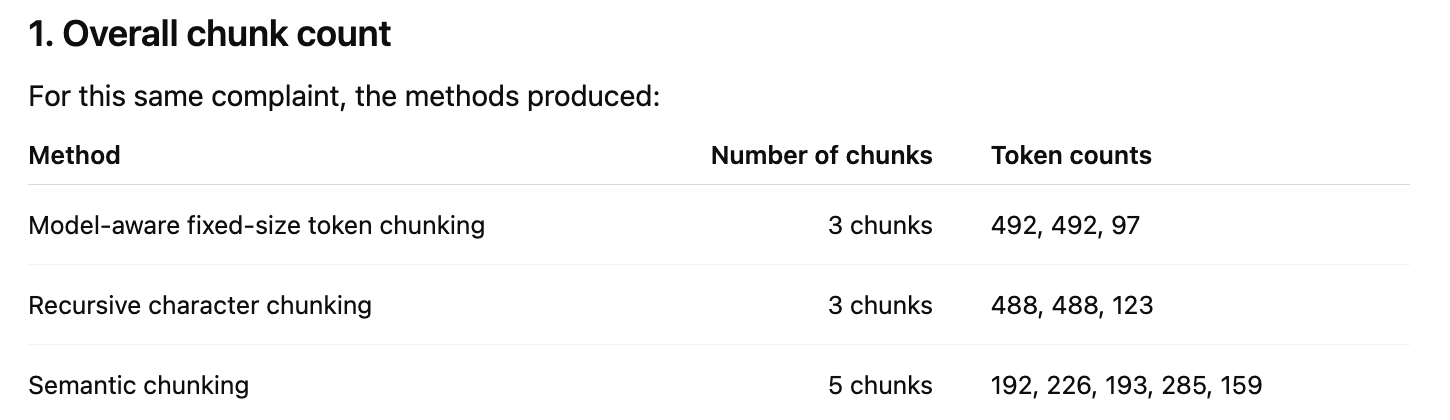

The first two methods create larger chunks close to the 512-token limit, while semantic chunking creates smaller and more focused chunks.

In [ ]:
for method_name, method_df in [
    ("Model-aware conditional token chunking", token_selected_df),
    ("Recursive character chunking", recursive_selected_df),
    ("Semantic chunking", semantic_selected_df)
]:
    print("\n" + "="*120)
    print(method_name)
    print("Number of chunks:", len(method_df))
    print("="*120)

    for _, row in method_df.sort_values("chunk_index").iterrows():
        print("\n" + "-"*100)
        print("Chunk index:", row["chunk_index"])
        print("Final token count:", row["final_chunk_token_count"])

        full_text = str(row["chunk_text"])

        print("\nSTART of full chunk_text:")
        print(full_text[:900])

        print("\nEND of full chunk_text:")
        print(full_text[-900:])

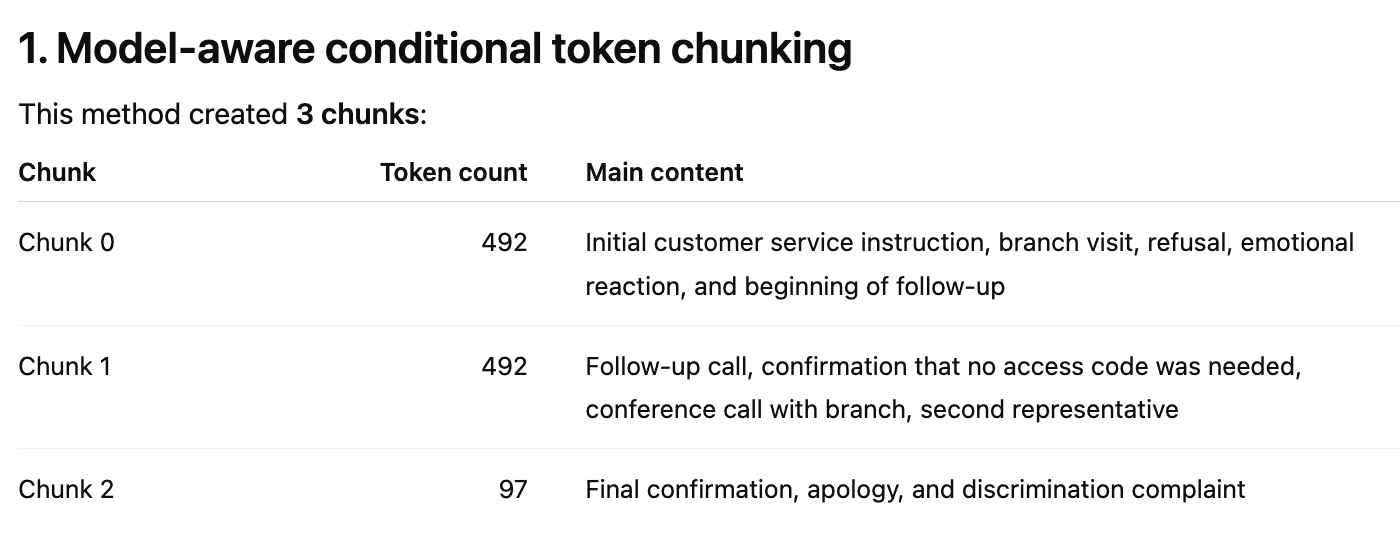

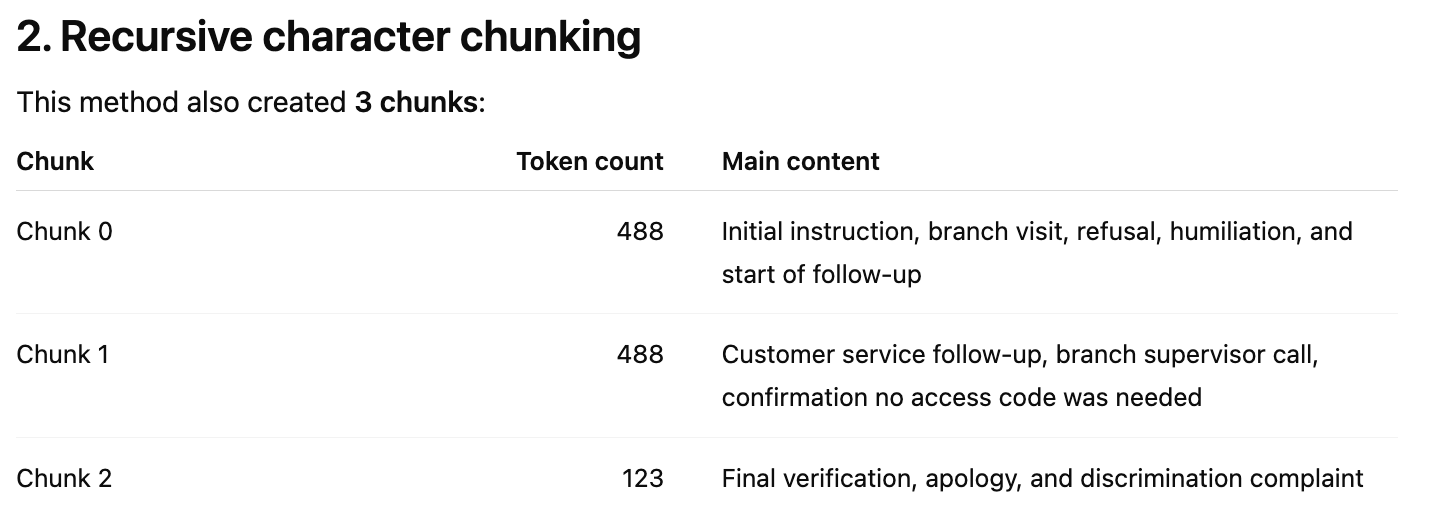

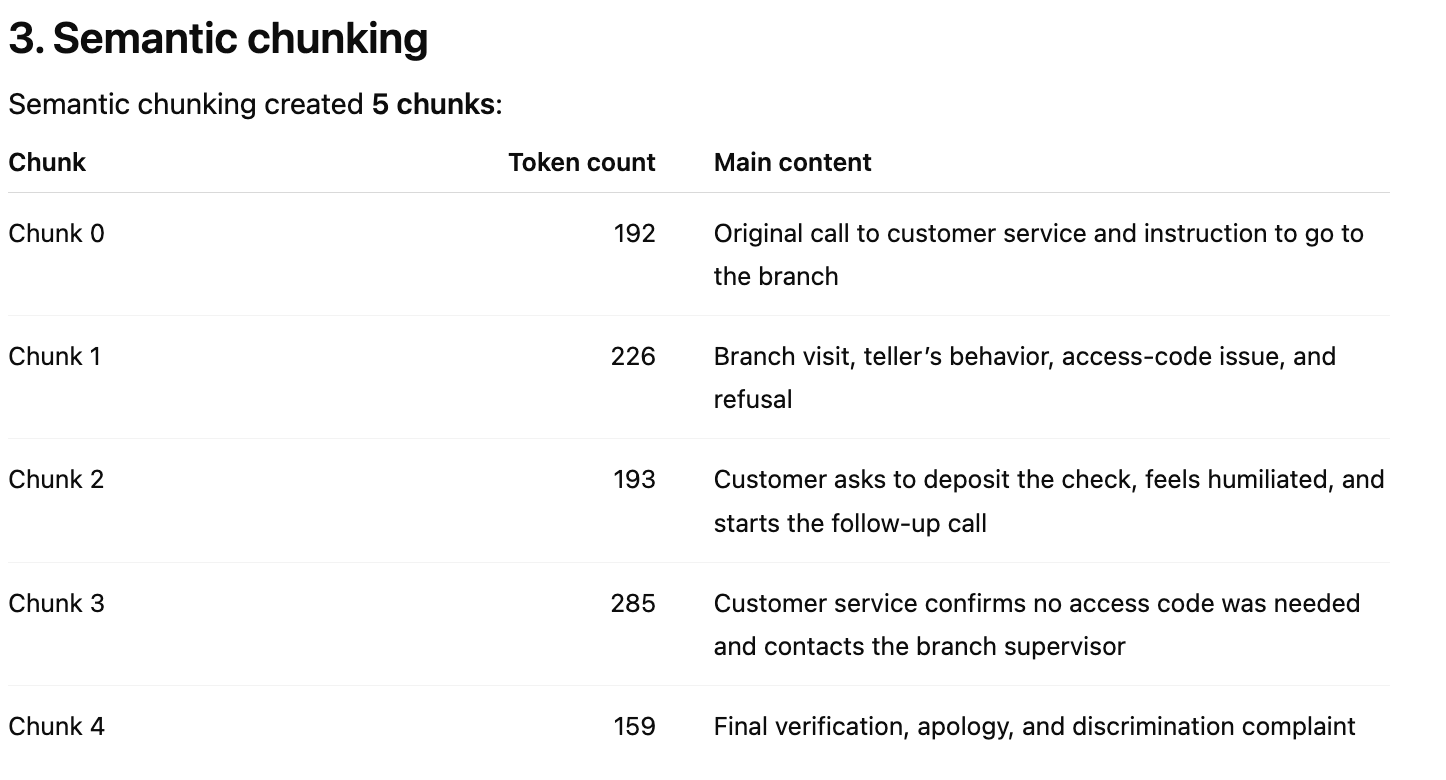

In [ ]:
# -----------------------------
# Step 1 — Define folders
# -----------------------------

token_parts_dir = "/content/drive/MyDrive/consumer_complaints_bge_chunks_v1_parts"
recursive_parts_dir = "/content/drive/MyDrive/consumer_complaints_recursive_chunks_v1_parts"
semantic_parts_dir = "/content/drive/MyDrive/consumer_complaints_semantic_chunks_v1_parts"


def get_csv_files(parts_dir):
    return sorted([
        os.path.join(parts_dir, f)
        for f in os.listdir(parts_dir)
        if f.endswith(".csv")
    ])


token_part_files = get_csv_files(token_parts_dir)
recursive_part_files = get_csv_files(recursive_parts_dir)
semantic_part_files = get_csv_files(semantic_parts_dir)

print("Token method files:", len(token_part_files))
print("Recursive method files:", len(recursive_part_files))
print("Semantic method files:", len(semantic_part_files))


# -----------------------------
# Step 2 — Find candidate complaints from semantic chunks
# -----------------------------

candidate_rows = []

for path in semantic_part_files:
    df = pd.read_csv(
        path,
        usecols=[
            "representative_complaint_id",
            "chunk_count_for_complaint",
            "retrieval_text_token_count",
            "original_narrative_token_count",
            "Product",
            "Issue",
            "Company",
            "State"
        ]
    )

    candidates = df[
        (df["chunk_count_for_complaint"] >= 3) &
        (df["chunk_count_for_complaint"] <= 6) &
        (df["retrieval_text_token_count"] >= 600) &
        (df["retrieval_text_token_count"] <= 1500)
    ].copy()

    if not candidates.empty:
        candidate_rows.append(
            candidates.drop_duplicates("representative_complaint_id")
        )

    # collect enough candidates, then stop
    if sum(len(x) for x in candidate_rows) >= 50:
        break

candidate_df = (
    pd.concat(candidate_rows, ignore_index=True)
    .drop_duplicates("representative_complaint_id")
)

candidate_df["representative_complaint_id"] = candidate_df["representative_complaint_id"].astype(str)

print("\nNumber of candidate complaints found:", len(candidate_df))
print("\nCandidate preview:")
display(candidate_df.head(15))


# -----------------------------
# Step 3 — Collect chunks for these candidate IDs from each method
# -----------------------------

candidate_ids = candidate_df["representative_complaint_id"].astype(str).tolist()


def collect_candidate_chunk_summary(part_files, candidate_ids, method_name):
    rows = []

    usecols = [
        "representative_complaint_id",
        "chunk_index",
        "chunk_count_for_complaint",
        "final_chunk_token_count",
        "chunk_text"
    ]

    candidate_ids_set = set(candidate_ids)

    for path in part_files:
        df = pd.read_csv(path, usecols=usecols)

        df["representative_complaint_id"] = df["representative_complaint_id"].astype(str)

        matched = df[df["representative_complaint_id"].isin(candidate_ids_set)]

        if not matched.empty:
            matched = matched.copy()
            matched["method"] = method_name
            rows.append(matched)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame(columns=usecols + ["method"])


token_candidate_chunks = collect_candidate_chunk_summary(
    token_part_files,
    candidate_ids,
    "Token"
)

recursive_candidate_chunks = collect_candidate_chunk_summary(
    recursive_part_files,
    candidate_ids,
    "Recursive"
)

semantic_candidate_chunks = collect_candidate_chunk_summary(
    semantic_part_files,
    candidate_ids,
    "Semantic"
)

all_candidate_chunks = pd.concat(
    [
        token_candidate_chunks,
        recursive_candidate_chunks,
        semantic_candidate_chunks
    ],
    ignore_index=True
)

all_candidate_chunks["representative_complaint_id"] = all_candidate_chunks["representative_complaint_id"].astype(str)

print("\nCollected candidate chunks shape:", all_candidate_chunks.shape)


# -----------------------------
# Step 4 — Create chunk-count summary for each candidate
# -----------------------------

summary = (
    all_candidate_chunks
    .groupby(["representative_complaint_id", "method"])
    .agg(
        chunk_count=("chunk_index", "count"),
        token_counts=("final_chunk_token_count", lambda x: list(x)),
        max_tokens=("final_chunk_token_count", "max"),
        min_tokens=("final_chunk_token_count", "min")
    )
    .reset_index()
)

summary_pivot = summary.pivot(
    index="representative_complaint_id",
    columns="method",
    values="chunk_count"
).reset_index()

summary_pivot["representative_complaint_id"] = summary_pivot["representative_complaint_id"].astype(str)


# -----------------------------
# Step 5 — Add complaint info
# -----------------------------

candidate_info_df = candidate_df[
    [
        "representative_complaint_id",
        "retrieval_text_token_count",
        "original_narrative_token_count",
        "Product",
        "Issue",
        "Company",
        "State"
    ]
].copy()

candidate_info_df["representative_complaint_id"] = candidate_info_df["representative_complaint_id"].astype(str)

summary_pivot = summary_pivot.merge(
    candidate_info_df,
    on="representative_complaint_id",
    how="left"
)


# -----------------------------
# Step 6 — Find examples where methods differ
# -----------------------------

summary_pivot["different_chunk_counts"] = (
    (summary_pivot["Token"] != summary_pivot["Recursive"]) |
    (summary_pivot["Token"] != summary_pivot["Semantic"]) |
    (summary_pivot["Recursive"] != summary_pivot["Semantic"])
)

summary_pivot = summary_pivot.sort_values(
    ["different_chunk_counts", "retrieval_text_token_count"],
    ascending=[False, False]
)

print("\nCandidate comparison table:")
display(summary_pivot)


# -----------------------------
# Step 7 — Automatically select a good example
# -----------------------------

different_examples = summary_pivot[summary_pivot["different_chunk_counts"] == True]

if len(different_examples) > 0:
    selected_id = different_examples["representative_complaint_id"].iloc[0]
else:
    selected_id = summary_pivot["representative_complaint_id"].iloc[0]

print("\nSelected complaint ID:", selected_id)

print("\nSelected complaint info:")
display(
    summary_pivot[
        summary_pivot["representative_complaint_id"] == selected_id
    ]
)

In [ ]:
filtered_examples = summary_pivot[
    (summary_pivot["Token"] == 3) &
    (summary_pivot["Semantic"].isin([5, 6])) &
    (summary_pivot["Recursive"].isin([3, 4]))
].copy()

filtered_examples = filtered_examples.sort_values(
    ["Semantic", "retrieval_text_token_count"],
    ascending=[False, False]
)

display(filtered_examples)

# **Step 29 - Setup for token-aware semantic chunking**

In [ ]:
# Source file
chunk_source_path = "/content/drive/MyDrive/consumer_complaints_chunk_source_v1.csv"

# Output folder for token-aware semantic chunking
token_aware_semantic_parts_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_chunks_v1_parts"
token_aware_semantic_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_chunks_v1_checkpoint.json"

os.makedirs(token_aware_semantic_parts_dir, exist_ok=True)

# Model settings
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
MAX_TOKENS = 512
SAFETY_MARGIN = 20
NORMALIZE_EMBEDDINGS = True

# Semantic settings
SIMILARITY_PERCENTILE = 20
MIN_CHUNK_TOKENS = 80

# Batch settings
WRITE_BATCH_SIZE = 500
STATUS_EVERY_N_ROWS = 5000

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer(EMBEDDING_MODEL, device=device)

print("Setup ready.")
print("Input file:", chunk_source_path)
print("Output folder:", token_aware_semantic_parts_dir)
print("Checkpoint:", token_aware_semantic_checkpoint_path)
print("Model:", EMBEDDING_MODEL)
print("Device:", device)
print("MAX_TOKENS:", MAX_TOKENS)
print("SAFETY_MARGIN:", SAFETY_MARGIN)
print("SIMILARITY_PERCENTILE:", SIMILARITY_PERCENTILE)
print("MIN_CHUNK_TOKENS:", MIN_CHUNK_TOKENS)

We are not going to build semantic chunks first and repair them later.
Instead, while building a chunk sentence by sentence, we simultaneously check:

* Semantic condition: similarity < threshold

OR

* Token condition: adding next sentence exceeds token budget

In [ ]:
def is_missing(x):
    return pd.isna(x) or str(x).strip()==""


def count_tokens(text):
    if is_missing(text):
        return 0
    return len(tokenizer.encode(
        str(text),
        add_special_tokens=True
    ))


def split_sentences(text):

    if is_missing(text):
        return []

    text = str(text).strip()

    sentences = re.split(
        r'(?<=[.!?])\s+',
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    return sentences


def embed_sentences(sentences):

    if len(sentences)==0:
        return np.array([])

    embeddings = model.encode(
        sentences,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False
    )

    return embeddings


def compute_adjacent_similarities(sentence_embeddings):

    if len(sentence_embeddings)<=1:
        return []

    similarities=[]

    for i in range(len(sentence_embeddings)-1):

        sim = cosine_similarity(
            sentence_embeddings[i].reshape(1,-1),
            sentence_embeddings[i+1].reshape(1,-1)
        )[0][0]

        similarities.append(sim)

    return similarities


def get_similarity_threshold(similarities):

    if len(similarities)==0:
        return None

    threshold=np.percentile(
        similarities,
        SIMILARITY_PERCENTILE
    )

    return threshold

**Build token-aware semantic chunks**
What we want to do:

This function will build chunks sentence by sentence.

It creates a new chunk if:

1. semantic similarity drops below the threshold
OR
2. adding the next sentence would exceed the available token budget

It also avoids tiny chunks with MIN_CHUNK_TOKENS = 80.

In [ ]:
def build_metadata_header(row):
    fields = ["Product", "Sub-product", "Issue", "Sub-issue", "Company", "State"]
    header_lines = []

    for field in fields:
        value = row.get(field, "")
        if not is_missing(value):
            header_lines.append(f"{field}: {value}")

    header_lines.append("")
    header_lines.append("Complaint narrative:")

    return "\n".join(header_lines)


def build_final_chunk_text(header, narrative_chunk):
    return header + "\n" + narrative_chunk.strip()


def token_aware_semantic_chunk_narrative(row):
    narrative = row.get("Consumer complaint narrative", "")
    retrieval_text = row.get("retrieval_text", "")

    header = build_metadata_header(row)

    metadata_header_token_count = count_tokens(header)
    available_narrative_tokens = MAX_TOKENS - metadata_header_token_count - SAFETY_MARGIN

    original_retrieval_text_token_count = count_tokens(retrieval_text)
    original_narrative_token_count = count_tokens(narrative)

    if is_missing(narrative):
        return []

    sentences = split_sentences(narrative)

    if len(sentences) == 0:
        return []

    # If one sentence only, keep it if possible
    # If it is too long, truncate as last-resort edge case
    if len(sentences) == 1:
        sentence = sentences[0]
        final_text = build_final_chunk_text(header, sentence)

        if count_tokens(final_text) <= MAX_TOKENS:
            return [{
                "chunk_narrative": sentence,
                "similarity_threshold": None,
                "used_token_boundary": False,
                "used_semantic_boundary": False,
                "was_truncated": False,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_retrieval_text_token_count": original_retrieval_text_token_count,
                "original_narrative_token_count": original_narrative_token_count
            }]

        # last-resort truncation for one very long sentence
        allowed_tokens = max(1, available_narrative_tokens)
        encoded = tokenizer.encode(sentence, add_special_tokens=False)
        truncated_sentence = tokenizer.decode(encoded[:allowed_tokens])

        return [{
            "chunk_narrative": truncated_sentence,
            "similarity_threshold": None,
            "used_token_boundary": True,
            "used_semantic_boundary": False,
            "was_truncated": True,
            "metadata_header_token_count": metadata_header_token_count,
            "available_narrative_tokens": available_narrative_tokens,
            "original_retrieval_text_token_count": original_retrieval_text_token_count,
            "original_narrative_token_count": original_narrative_token_count
        }]

    sentence_embeddings = embed_sentences(sentences)
    similarities = compute_adjacent_similarities(sentence_embeddings)
    threshold = get_similarity_threshold(similarities)

    chunks = []
    current_sentences = []
    current_used_token_boundary = False
    current_used_semantic_boundary = False

    for i, sentence in enumerate(sentences):
        candidate_sentences = current_sentences + [sentence]
        candidate_text = " ".join(candidate_sentences).strip()
        candidate_final_text = build_final_chunk_text(header, candidate_text)

        candidate_exceeds_limit = count_tokens(candidate_final_text) > MAX_TOKENS

        # If adding this sentence exceeds the final token limit,
        # close current chunk first, then start new chunk with this sentence.
        if candidate_exceeds_limit and len(current_sentences) > 0:
            current_text = " ".join(current_sentences).strip()

            chunks.append({
                "chunk_narrative": current_text,
                "similarity_threshold": threshold,
                "used_token_boundary": True,
                "used_semantic_boundary": current_used_semantic_boundary,
                "was_truncated": False,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_retrieval_text_token_count": original_retrieval_text_token_count,
                "original_narrative_token_count": original_narrative_token_count
            })

            current_sentences = [sentence]
            current_used_token_boundary = False
            current_used_semantic_boundary = False
        else:
            current_sentences.append(sentence)

        # Check semantic boundary after current sentence,
        # except after the last sentence.
        if i < len(similarities):
            current_text = " ".join(current_sentences).strip()

            semantic_drop = similarities[i] < threshold
            current_big_enough = count_tokens(current_text) >= MIN_CHUNK_TOKENS

            if semantic_drop and current_big_enough:
                chunks.append({
                    "chunk_narrative": current_text,
                    "similarity_threshold": threshold,
                    "used_token_boundary": current_used_token_boundary,
                    "used_semantic_boundary": True,
                    "was_truncated": False,
                    "metadata_header_token_count": metadata_header_token_count,
                    "available_narrative_tokens": available_narrative_tokens,
                    "original_retrieval_text_token_count": original_retrieval_text_token_count,
                    "original_narrative_token_count": original_narrative_token_count
                })

                current_sentences = []
                current_used_token_boundary = False
                current_used_semantic_boundary = False

    # Add remaining sentences
    if len(current_sentences) > 0:
        current_text = " ".join(current_sentences).strip()

        # If final chunk is very small, merge with previous if possible
        if chunks and count_tokens(current_text) < MIN_CHUNK_TOKENS:
            previous_text = chunks[-1]["chunk_narrative"]
            merged_text = (previous_text + " " + current_text).strip()
            merged_final_text = build_final_chunk_text(header, merged_text)

            if count_tokens(merged_final_text) <= MAX_TOKENS:
                chunks[-1]["chunk_narrative"] = merged_text
            else:
                chunks.append({
                    "chunk_narrative": current_text,
                    "similarity_threshold": threshold,
                    "used_token_boundary": False,
                    "used_semantic_boundary": False,
                    "was_truncated": False,
                    "metadata_header_token_count": metadata_header_token_count,
                    "available_narrative_tokens": available_narrative_tokens,
                    "original_retrieval_text_token_count": original_retrieval_text_token_count,
                    "original_narrative_token_count": original_narrative_token_count
                })
        else:
            chunks.append({
                "chunk_narrative": current_text,
                "similarity_threshold": threshold,
                "used_token_boundary": False,
                "used_semantic_boundary": False,
                "was_truncated": False,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_retrieval_text_token_count": original_retrieval_text_token_count,
                "original_narrative_token_count": original_narrative_token_count
            })

    # Final safety check
    final_chunks = []

    for chunk in chunks:
        final_text = build_final_chunk_text(header, chunk["chunk_narrative"])

        if count_tokens(final_text) <= MAX_TOKENS:
            final_chunks.append(chunk)
        else:
            # Last-resort truncation, should be rare
            encoded = tokenizer.encode(chunk["chunk_narrative"], add_special_tokens=False)
            truncated_narrative = tokenizer.decode(
                encoded[:max(1, available_narrative_tokens)]
            )

            chunk["chunk_narrative"] = truncated_narrative
            chunk["was_truncated"] = True
            chunk["used_token_boundary"] = True

            final_chunks.append(chunk)

    return final_chunks

# **Step 29.1 - Test token-aware semantic chunking on one complaint**

What we want to do:

We will test the new method on complaint ID 1461317.

We want to check:

* how many chunks it creates
* token count of each chunk
* whether any chunk exceeds 512 tokens
* whether truncation happens
* whether boundaries are caused by semantic drop or token budget
* whether the chunks look readable

In [ ]:
# Test token-aware semantic chunking on one selected complaint

selected_id = "2237798"

# Find original row from source file
test_row = None

for df in pd.read_csv(chunk_source_path, chunksize=5000, low_memory=False):
    df["representative_complaint_id"] = df["representative_complaint_id"].astype(str)
    match = df[df["representative_complaint_id"] == selected_id]

    if not match.empty:
        test_row = match.iloc[0].to_dict()
        break

if test_row is None:
    raise ValueError(f"Complaint ID {selected_id} not found.")

print("Selected complaint ID:", selected_id)
print("Product:", test_row.get("Product"))
print("Sub-product:", test_row.get("Sub-product"))
print("Issue:", test_row.get("Issue"))
print("Company:", test_row.get("Company"))
print("State:", test_row.get("State"))

print("\nOriginal retrieval_text token count:", count_tokens(test_row.get("retrieval_text")))
print("Original narrative token count:", count_tokens(test_row.get("Consumer complaint narrative")))

# Run token-aware semantic chunking
test_chunks = token_aware_semantic_chunk_narrative(test_row)

print("\nNumber of token-aware semantic chunks:", len(test_chunks))

# Build full chunk texts and inspect
over_512_count = 0
truncated_count = 0
token_boundary_count = 0
semantic_boundary_count = 0

for i, chunk in enumerate(test_chunks):
    header = build_metadata_header(test_row)
    chunk_text = build_final_chunk_text(header, chunk["chunk_narrative"])

    final_token_count = count_tokens(chunk_text)
    narrative_token_count = count_tokens(chunk["chunk_narrative"])

    if final_token_count > MAX_TOKENS:
        over_512_count += 1

    if chunk["was_truncated"]:
        truncated_count += 1

    if chunk["used_token_boundary"]:
        token_boundary_count += 1

    if chunk["used_semantic_boundary"]:
        semantic_boundary_count += 1

    print("\n" + "="*100)
    print("Chunk index:", i)
    print("Final token count:", final_token_count)
    print("Narrative token count:", narrative_token_count)
    print("Similarity threshold:", chunk["similarity_threshold"])
    print("Used token boundary:", chunk["used_token_boundary"])
    print("Used semantic boundary:", chunk["used_semantic_boundary"])
    print("Was truncated:", chunk["was_truncated"])

    print("\nSTART of full chunk_text:")
    print(chunk_text[:900])

    print("\nEND of full chunk_text:")
    print(chunk_text[-900:])

print("\n" + "="*100)
print("Summary")
print("Chunks created:", len(test_chunks))
print("Rows over 512 tokens:", over_512_count)
print("Truncated chunks:", truncated_count)
print("Chunks closed by token boundary:", token_boundary_count)
print("Chunks closed by semantic boundary:", semantic_boundary_count)

We needed proof of this:

semantic similarity stays high

↓

chunk continues growing

↓

token limit intervenes

↓

forced boundary happens




* The method respects the 512-token limit
* Semantic grouping still happens
* Token budget activates only when needed
* No truncation is happening
* Oversized semantic chunks are handled without recursive fallbac

In [ ]:
# Step TA5 — Search for long complaints where token-aware boundary is used

target_examples = []
max_examples = 10
min_retrieval_tokens = 1500

rows_checked = 0
long_rows_checked = 0

for df in pd.read_csv(chunk_source_path, chunksize=2000, low_memory=False):
    df["representative_complaint_id"] = df["representative_complaint_id"].astype(str)

    # Count retrieval_text tokens
    df["retrieval_text_token_count_check"] = df["retrieval_text"].apply(count_tokens)

    # Only test long complaints
    long_df = df[df["retrieval_text_token_count_check"] >= min_retrieval_tokens].copy()

    for _, row in long_df.iterrows():
        row_dict = row.to_dict()
        long_rows_checked += 1

        chunks = token_aware_semantic_chunk_narrative(row_dict)

        used_token_boundary_count = sum(
            1 for c in chunks if c["used_token_boundary"] == True
        )

        used_semantic_boundary_count = sum(
            1 for c in chunks if c["used_semantic_boundary"] == True
        )

        was_truncated_count = sum(
            1 for c in chunks if c["was_truncated"] == True
        )

        header = build_metadata_header(row_dict)

        final_token_counts = [
            count_tokens(build_final_chunk_text(header, c["chunk_narrative"]))
            for c in chunks
        ]

        if used_token_boundary_count > 0:
            target_examples.append({
                "representative_complaint_id": row_dict["representative_complaint_id"],
                "retrieval_text_token_count": row_dict["retrieval_text_token_count_check"],
                "original_narrative_token_count": count_tokens(row_dict["Consumer complaint narrative"]),
                "Product": row_dict.get("Product"),
                "Issue": row_dict.get("Issue"),
                "Company": row_dict.get("Company"),
                "State": row_dict.get("State"),
                "number_of_chunks": len(chunks),
                "used_token_boundary_count": used_token_boundary_count,
                "used_semantic_boundary_count": used_semantic_boundary_count,
                "was_truncated_count": was_truncated_count,
                "max_final_token_count": max(final_token_counts) if final_token_counts else None,
                "final_token_counts": final_token_counts
            })

        if len(target_examples) >= max_examples:
            break

    rows_checked += len(df)

    print(
        f"Rows checked: {rows_checked}, "
        f"long rows tested: {long_rows_checked}, "
        f"examples found: {len(target_examples)}"
    )

    if len(target_examples) >= max_examples:
        break

token_boundary_examples_df = pd.DataFrame(target_examples)

print("\nDone.")
print("Examples found:", len(token_boundary_examples_df))

display(token_boundary_examples_df)

In [ ]:
test_id = "1618828"

sample_df = pd.read_csv(
    chunk_source_path,
    low_memory=False,
    dtype={"representative_complaint_id": str}
)

row = sample_df[
    sample_df["representative_complaint_id"] == test_id
].iloc[0]

print("Complaint:", test_id)
print("Retrieval tokens:", count_tokens(row["retrieval_text"]))

chunks = token_aware_semantic_chunk_narrative(row.to_dict())

print("\nNumber of chunks:", len(chunks))

for i, c in enumerate(chunks):

    header = build_metadata_header(row.to_dict())

    full_text = build_final_chunk_text(
        header,
        c["chunk_narrative"]
    )

    print("\n"+"="*90)
    print("Chunk:", i)

    print("Final tokens:",
          count_tokens(full_text))

    print("Token boundary:",
          c["used_token_boundary"])

    print("Semantic boundary:",
          c["used_semantic_boundary"])

    print("\nSTART:")
    print(full_text[:500])

    print("\nEND:")
    print(full_text[-500:])

# **Step 29.2 - Run token-aware semantic chunking on full dataset**

In [ ]:
# Step TA6.1 — Full dataset setup for token-aware semantic chunking

token_aware_output_columns = [
    "chunk_id",
    "representative_complaint_id",
    "complaint_count",
    "unique_complaint_ids",
    "chunk_index",
    "chunk_count_for_complaint",
    "chunking_method",
    "similarity_percentile",
    "similarity_threshold",
    "retrieval_text_token_count",
    "metadata_header_token_count",
    "available_narrative_tokens",
    "original_narrative_token_count",
    "narrative_chunk_token_count",
    "final_chunk_token_count",
    "was_chunked",
    "used_token_boundary",
    "used_semantic_boundary",
    "was_truncated",
    "chunk_text",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Company public response",
    "Consumer consent provided?",
    "Date sent to company"
]

def load_token_aware_checkpoint():
    if os.path.exists(token_aware_semantic_checkpoint_path):
        try:
            with open(token_aware_semantic_checkpoint_path, "r") as f:
                return json.load(f)
        except Exception:
            return {
                "processed_rows": 0,
                "total_chunk_rows": 0,
                "next_part_number": 1
            }

    return {
        "processed_rows": 0,
        "total_chunk_rows": 0,
        "next_part_number": 1
    }


def save_token_aware_checkpoint(processed_rows, total_chunk_rows, next_part_number):
    temp_path = token_aware_semantic_checkpoint_path + ".tmp"

    with open(temp_path, "w") as f:
        json.dump(
            {
                "processed_rows": processed_rows,
                "total_chunk_rows": total_chunk_rows,
                "next_part_number": next_part_number
            },
            f
        )

    os.replace(temp_path, token_aware_semantic_checkpoint_path)


def write_token_aware_part_file(rows, part_number):
    part_path = os.path.join(
        token_aware_semantic_parts_dir,
        f"token_aware_semantic_chunks_part_{part_number:06d}.csv"
    )

    part_df = pd.DataFrame(rows)

    part_df = part_df[token_aware_output_columns]

    part_df.to_csv(part_path, index=False)

    return part_path


print("Token-aware full-run setup ready.")
print("Output folder:", token_aware_semantic_parts_dir)
print("Checkpoint:", token_aware_semantic_checkpoint_path)
print("Number of output columns:", len(token_aware_output_columns))

In [ ]:
import os
import shutil

# Delete wrong token-aware semantic output folder
if os.path.exists(token_aware_semantic_parts_dir):
    shutil.rmtree(token_aware_semantic_parts_dir)

# Recreate empty folder
os.makedirs(token_aware_semantic_parts_dir, exist_ok=True)

# Delete checkpoint
if os.path.exists(token_aware_semantic_checkpoint_path):
    os.remove(token_aware_semantic_checkpoint_path)

print("Old token-aware semantic files deleted.")
print("Output folder recreated:", token_aware_semantic_parts_dir)
print("Checkpoint deleted:", not os.path.exists(token_aware_semantic_checkpoint_path))

In [ ]:
def token_aware_semantic_chunk_narrative(row):
    narrative = row.get("Consumer complaint narrative", "")
    retrieval_text = row.get("retrieval_text", "")

    header = build_metadata_header(row)

    metadata_header_token_count = count_tokens(header)
    available_narrative_tokens = MAX_TOKENS - metadata_header_token_count - SAFETY_MARGIN

    original_retrieval_text_token_count = count_tokens(retrieval_text)
    original_narrative_token_count = count_tokens(narrative)

    if is_missing(narrative):
        return []

    # IMPORTANT:
    # If final retrieval_text already fits BGE limit, do not chunk.
    # Keep it as one retrieval unit.
    if original_retrieval_text_token_count <= MAX_TOKENS:
        return [{
            "chunk_narrative": str(narrative).strip(),
            "similarity_threshold": None,
            "used_token_boundary": False,
            "used_semantic_boundary": False,
            "was_truncated": False,
            "metadata_header_token_count": metadata_header_token_count,
            "available_narrative_tokens": available_narrative_tokens,
            "original_retrieval_text_token_count": original_retrieval_text_token_count,
            "original_narrative_token_count": original_narrative_token_count
        }]

    sentences = split_sentences(narrative)

    if len(sentences) == 0:
        return []

    if len(sentences) == 1:
        sentence = sentences[0]
        final_text = build_final_chunk_text(header, sentence)

        if count_tokens(final_text) <= MAX_TOKENS:
            return [{
                "chunk_narrative": sentence,
                "similarity_threshold": None,
                "used_token_boundary": False,
                "used_semantic_boundary": False,
                "was_truncated": False,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_retrieval_text_token_count": original_retrieval_text_token_count,
                "original_narrative_token_count": original_narrative_token_count
            }]

        # Last-resort truncation for a single very long sentence
        allowed_tokens = max(1, available_narrative_tokens)
        encoded = tokenizer.encode(sentence, add_special_tokens=False)
        truncated_sentence = tokenizer.decode(encoded[:allowed_tokens])

        return [{
            "chunk_narrative": truncated_sentence,
            "similarity_threshold": None,
            "used_token_boundary": True,
            "used_semantic_boundary": False,
            "was_truncated": True,
            "metadata_header_token_count": metadata_header_token_count,
            "available_narrative_tokens": available_narrative_tokens,
            "original_retrieval_text_token_count": original_retrieval_text_token_count,
            "original_narrative_token_count": original_narrative_token_count
        }]

    sentence_embeddings = embed_sentences(sentences)
    similarities = compute_adjacent_similarities(sentence_embeddings)
    threshold = get_similarity_threshold(similarities)

    chunks = []
    current_sentences = []

    for i, sentence in enumerate(sentences):
        candidate_sentences = current_sentences + [sentence]
        candidate_text = " ".join(candidate_sentences).strip()
        candidate_final_text = build_final_chunk_text(header, candidate_text)

        candidate_exceeds_limit = count_tokens(candidate_final_text) > MAX_TOKENS

        # If adding the sentence exceeds 512, close current chunk first
        if candidate_exceeds_limit and len(current_sentences) > 0:
            current_text = " ".join(current_sentences).strip()

            chunks.append({
                "chunk_narrative": current_text,
                "similarity_threshold": threshold,
                "used_token_boundary": True,
                "used_semantic_boundary": False,
                "was_truncated": False,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_retrieval_text_token_count": original_retrieval_text_token_count,
                "original_narrative_token_count": original_narrative_token_count
            })

            current_sentences = [sentence]
        else:
            current_sentences.append(sentence)

        # Semantic boundary after this sentence
        if i < len(similarities):
            current_text = " ".join(current_sentences).strip()

            semantic_drop = similarities[i] < threshold
            current_big_enough = count_tokens(current_text) >= MIN_CHUNK_TOKENS

            if semantic_drop and current_big_enough:
                chunks.append({
                    "chunk_narrative": current_text,
                    "similarity_threshold": threshold,
                    "used_token_boundary": False,
                    "used_semantic_boundary": True,
                    "was_truncated": False,
                    "metadata_header_token_count": metadata_header_token_count,
                    "available_narrative_tokens": available_narrative_tokens,
                    "original_retrieval_text_token_count": original_retrieval_text_token_count,
                    "original_narrative_token_count": original_narrative_token_count
                })

                current_sentences = []

    # Add remaining sentences
    if len(current_sentences) > 0:
        current_text = " ".join(current_sentences).strip()

        if chunks and count_tokens(current_text) < MIN_CHUNK_TOKENS:
            previous_text = chunks[-1]["chunk_narrative"]
            merged_text = (previous_text + " " + current_text).strip()
            merged_final_text = build_final_chunk_text(header, merged_text)

            if count_tokens(merged_final_text) <= MAX_TOKENS:
                chunks[-1]["chunk_narrative"] = merged_text
            else:
                chunks.append({
                    "chunk_narrative": current_text,
                    "similarity_threshold": threshold,
                    "used_token_boundary": False,
                    "used_semantic_boundary": False,
                    "was_truncated": False,
                    "metadata_header_token_count": metadata_header_token_count,
                    "available_narrative_tokens": available_narrative_tokens,
                    "original_retrieval_text_token_count": original_retrieval_text_token_count,
                    "original_narrative_token_count": original_narrative_token_count
                })
        else:
            chunks.append({
                "chunk_narrative": current_text,
                "similarity_threshold": threshold,
                "used_token_boundary": False,
                "used_semantic_boundary": False,
                "was_truncated": False,
                "metadata_header_token_count": metadata_header_token_count,
                "available_narrative_tokens": available_narrative_tokens,
                "original_retrieval_text_token_count": original_retrieval_text_token_count,
                "original_narrative_token_count": original_narrative_token_count
            })

    # Final safety check
    final_chunks = []

    for chunk in chunks:
        final_text = build_final_chunk_text(header, chunk["chunk_narrative"])

        if count_tokens(final_text) <= MAX_TOKENS:
            final_chunks.append(chunk)
        else:
            encoded = tokenizer.encode(chunk["chunk_narrative"], add_special_tokens=False)
            truncated_narrative = tokenizer.decode(
                encoded[:max(1, available_narrative_tokens)]
            )

            chunk["chunk_narrative"] = truncated_narrative
            chunk["was_truncated"] = True
            chunk["used_token_boundary"] = True

            final_chunks.append(chunk)

    return final_chunks

print("Corrected token-aware semantic chunking function is ready.")

In [ ]:
# Quick test: one short row and one long row

short_row = None
long_row = None

for df in pd.read_csv(chunk_source_path, chunksize=5000, low_memory=False):
    for _, row in df.iterrows():
        row_dict = row.to_dict()
        tokens = count_tokens(row_dict["retrieval_text"])

        if short_row is None and tokens <= MAX_TOKENS:
            short_row = row_dict

        if long_row is None and tokens > MAX_TOKENS:
            long_row = row_dict

        if short_row is not None and long_row is not None:
            break

    if short_row is not None and long_row is not None:
        break

for label, row_dict in [("SHORT ROW", short_row), ("LONG ROW", long_row)]:
    chunks = token_aware_semantic_chunk_narrative(row_dict)

    print("\n" + "="*80)
    print(label)
    print("Complaint ID:", row_dict["representative_complaint_id"])
    print("Retrieval_text tokens:", count_tokens(row_dict["retrieval_text"]))
    print("Number of chunks:", len(chunks))
    print("Used semantic boundaries:", sum(c["used_semantic_boundary"] for c in chunks))
    print("Used token boundaries:", sum(c["used_token_boundary"] for c in chunks))
    print("Truncated:", sum(c["was_truncated"] for c in chunks))

In [ ]:
# Step TA6.2 — Run token-aware semantic chunking on full dataset

PART_SIZE = 500
SOURCE_CHUNKSIZE = 500

checkpoint = load_token_aware_checkpoint()

processed_rows = checkpoint["processed_rows"]
total_chunk_rows = checkpoint["total_chunk_rows"]
next_part_number = checkpoint["next_part_number"]

print("Resuming from processed_rows:", processed_rows)
print("Total chunk rows already written:", total_chunk_rows)
print("Next part number:", next_part_number)

buffer = []

source_rows_seen = 0

for source_df in pd.read_csv(
    chunk_source_path,
    chunksize=SOURCE_CHUNKSIZE,
    low_memory=False,
    dtype={"representative_complaint_id": str}
):

    current_chunk_size = len(source_df)

    if source_rows_seen + current_chunk_size <= processed_rows:
        source_rows_seen += current_chunk_size
        continue

    if processed_rows > source_rows_seen:

        skip_amount = processed_rows - source_rows_seen

        source_df = source_df.iloc[skip_amount:]

    source_rows_seen += current_chunk_size

    for _, row in source_df.iterrows():

        row_dict = row.to_dict()

        chunk_results = token_aware_semantic_chunk_narrative(
            row_dict
        )

        num_chunks = len(chunk_results)

        retrieval_token_count = count_tokens(
            row_dict["retrieval_text"]
        )

        narrative_token_count = count_tokens(
            row_dict["Consumer complaint narrative"]
        )

        header = build_metadata_header(row_dict)

        header_token_count = count_tokens(header)

        available_tokens = (
            MAX_TOKENS
            - header_token_count
            - SAFETY_MARGIN
        )

        for chunk_idx, c in enumerate(chunk_results):

            chunk_text = build_final_chunk_text(
                header,
                c["chunk_narrative"]
            )

            output_row = {

                "chunk_id":
                f"{row_dict['representative_complaint_id']}_{chunk_idx}",

                "representative_complaint_id":
                row_dict["representative_complaint_id"],

                "complaint_count":
                row_dict.get("complaint_count"),

                "unique_complaint_ids":
                row_dict.get("unique_complaint_ids"),

                "chunk_index":
                chunk_idx,

                "chunk_count_for_complaint":
                num_chunks,

                "chunking_method":
                "Token-aware semantic chunking",

                "similarity_percentile":
                SIMILARITY_PERCENTILE,

                "similarity_threshold":
                c["similarity_threshold"],

                "retrieval_text_token_count":
                retrieval_token_count,

                "metadata_header_token_count":
                header_token_count,

                "available_narrative_tokens":
                available_tokens,

                "original_narrative_token_count":
                narrative_token_count,

                "narrative_chunk_token_count":
                count_tokens(c["chunk_narrative"]),

                "final_chunk_token_count":
                count_tokens(chunk_text),

                "was_chunked":
                num_chunks > 1,

                "used_token_boundary":
                c["used_token_boundary"],

                "used_semantic_boundary":
                c["used_semantic_boundary"],

                "was_truncated":
                c["was_truncated"],

                "chunk_text":
                chunk_text
            }

            for col in [
                "Product",
                "Sub-product",
                "Issue",
                "Sub-issue",
                "Company",
                "State",
                "Date received",
                "Submitted via",
                "Company response to consumer",
                "Timely response?",
                "Company public response",
                "Consumer consent provided?",
                "Date sent to company"
            ]:

                output_row[col] = row_dict.get(col)

            buffer.append(output_row)

            total_chunk_rows += 1

            if len(buffer) >= PART_SIZE:

                save_path = write_token_aware_part_file(
                    buffer,
                    next_part_number
                )

                print("Saved:", save_path)

                next_part_number += 1
                buffer = []

        processed_rows += 1

        if processed_rows % 5000 == 0:

            save_token_aware_checkpoint(
                processed_rows,
                total_chunk_rows,
                next_part_number
            )

            print(
                "Processed source rows:",
                processed_rows
            )

            print(
                "Total chunk rows written:",
                total_chunk_rows
            )

if len(buffer) > 0:

    save_path = write_token_aware_part_file(
        buffer,
        next_part_number
    )

    print("Saved final part:", save_path)

save_token_aware_checkpoint(
    processed_rows,
    total_chunk_rows,
    next_part_number
)

print("\nDone.")
print("Total source rows processed:", processed_rows)
print("Total chunk rows written:", total_chunk_rows)
print("Next part number:", next_part_number)
print("Parts saved in:", token_aware_semantic_parts_dir)
print("Checkpoint:", token_aware_semantic_checkpoint_path)

# **Step 29.3 - Validation**

In [ ]:
# Validate token-aware semantic chunking output

import os
import glob
import pandas as pd

token_aware_parts_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_chunks_v1_parts"

part_files = sorted(
    glob.glob(
        os.path.join(
            token_aware_parts_dir,
            "token_aware_semantic_chunks_part_*.csv"
        )
    )
)

print("Number of part files:", len(part_files))
print("First 3:", part_files[:3])
print("Last 3:", part_files[-3:])

total_rows = 0
unique_ids = set()

over_512_rows = 0
truncated_rows = 0
token_boundary_rows = 0
semantic_boundary_rows = 0

small_narrative_chunks_under_80 = 0
small_final_chunks_under_80 = 0

max_final_tokens = 0
max_narrative_tokens = 0

chunk_counts = []

for i, file in enumerate(part_files, start=1):

    df = pd.read_csv(file, low_memory=False)

    total_rows += len(df)

    unique_ids.update(
        df["representative_complaint_id"].astype(str).unique()
    )

    over_512_rows += (df["final_chunk_token_count"] > 512).sum()

    truncated_rows += df["was_truncated"].astype(bool).sum()

    token_boundary_rows += df["used_token_boundary"].astype(bool).sum()

    semantic_boundary_rows += df["used_semantic_boundary"].astype(bool).sum()

    small_narrative_chunks_under_80 += (
        df["narrative_chunk_token_count"] < 80
    ).sum()

    small_final_chunks_under_80 += (
        df["final_chunk_token_count"] < 80
    ).sum()

    max_final_tokens = max(
        max_final_tokens,
        df["final_chunk_token_count"].max()
    )

    max_narrative_tokens = max(
        max_narrative_tokens,
        df["narrative_chunk_token_count"].max()
    )

    chunk_counts.extend(
        df.groupby("representative_complaint_id").size().tolist()
    )

    if i % 250 == 0 or i == len(part_files):
        print(f"Checked {i}/{len(part_files)} files")

print("\nValidation summary")
print("="*60)

print("Total token-aware chunk rows:", total_rows)
print("Unique representative complaint IDs:", len(unique_ids))
print("Rows over 512 tokens:", over_512_rows)
print("Rows truncated:", truncated_rows)
print("Rows using token boundary:", token_boundary_rows)
print("Rows using semantic boundary:", semantic_boundary_rows)
print("Small narrative chunks under 80 tokens:", small_narrative_chunks_under_80)
print("Small final chunks under 80 tokens:", small_final_chunks_under_80)
print("Max final_chunk_token_count:", max_final_tokens)
print("Max narrative_chunk_token_count:", max_narrative_tokens)

chunk_count_series = pd.Series(chunk_counts)

print("\nChunk count per complaint summary:")
print(chunk_count_series.describe())

# **Step 30.1 — Setup embedding output folder and confirm input files**

In [ ]:
import os
import glob
import json
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

token_aware_chunk_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_chunks_v1_parts"

token_aware_embedding_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_bge_embeddings_v1_parts"

token_aware_embedding_checkpoint_path = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_bge_embeddings_v1_checkpoint.json"

os.makedirs(token_aware_embedding_dir, exist_ok=True)

token_aware_chunk_files = sorted(
    glob.glob(
        os.path.join(
            token_aware_chunk_dir,
            "token_aware_semantic_chunks_part_*.csv"
        )
    )
)

print("Number of token-aware chunk files:", len(token_aware_chunk_files))
print("First 3:", token_aware_chunk_files[:3])
print("Last 3:", token_aware_chunk_files[-3:])

sample_df = pd.read_csv(token_aware_chunk_files[0], nrows=5, low_memory=False)

print("\nSample shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

print("\nSample chunk_text:")
print(sample_df["chunk_text"].iloc[0][:1000])

# **Step 30.2 - load the BGE embedding model**

In [ ]:
# Step E2 — Load BGE embedding model

from sentence_transformers import SentenceTransformer
import torch

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    device=device
)

print("Embedding model loaded:", EMBEDDING_MODEL)
print("Device:", device)
print("Embedding dimension test:")

test_embedding = embedding_model.encode(
    ["test sentence"],
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=False
)

print(test_embedding.shape)
print("Norm:", np.linalg.norm(test_embedding[0]))

In [ ]:
# Step E3 — test embedding on one chunk file

EMBED_BATCH_SIZE = 256

test_df = pd.read_csv(
    token_aware_chunk_files[0],
    low_memory=False
)

print("Rows:", len(test_df))

texts = (
    test_df["chunk_text"]
    .fillna("")
    .astype(str)
    .tolist()
)

sample_embeddings = embedding_model.encode(

    texts[:100],

    batch_size=EMBED_BATCH_SIZE,

    normalize_embeddings=True,

    convert_to_numpy=True,

    show_progress_bar=True
)

print("Embedding shape:")
print(sample_embeddings.shape)

print("\nFirst vector first 10 values:")
print(sample_embeddings[0][:10])

print("\nNorm:")
print(np.linalg.norm(sample_embeddings[0]))

# **Step 30.3 - Full embedding run**

In [ ]:
EMBED_BATCH_SIZE = 256

start_file = 0

if os.path.exists(token_aware_embedding_checkpoint_path):

    with open(
        token_aware_embedding_checkpoint_path,
        "r"
    ) as f:

        checkpoint=json.load(f)

    start_file=checkpoint["last_file"]

    print(
        "Resuming from file:",
        start_file
    )

else:

    print("Starting fresh")


for file_idx in range(
    start_file,
    len(token_aware_chunk_files)
):

    file_path=token_aware_chunk_files[file_idx]

    df=pd.read_csv(
        file_path,
        low_memory=False
    )

    texts=(
        df["chunk_text"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    embeddings=embedding_model.encode(

        texts,

        batch_size=EMBED_BATCH_SIZE,

        normalize_embeddings=True,

        convert_to_numpy=True,

        show_progress_bar=False
    )

    embedding_df=pd.DataFrame({

        "chunk_id":
        df["chunk_id"],

        "representative_complaint_id":
        df["representative_complaint_id"],

        "embedding":
        embeddings.tolist()

    })

    output_name=(
        os.path.basename(file_path)
        .replace(
            "token_aware_semantic_chunks",
            "token_aware_semantic_embeddings"
        )
    )

    output_path=os.path.join(
        token_aware_embedding_dir,
        output_name
    )

    embedding_df.to_pickle(
        output_path.replace(
            ".csv",
            ".pkl"
        )
    )

    with open(
        token_aware_embedding_checkpoint_path,
        "w"
    ) as f:

        json.dump(
            {
                "last_file":
                file_idx+1
            },
            f
        )

    if (file_idx+1)%50==0:

        print(
            f"Processed {file_idx+1}/{len(token_aware_chunk_files)}"
        )

print("\nDONE")
print(
    "Saved embeddings to:",
    token_aware_embedding_dir
)

# **Step 30.4 - Validate Embedding**

We need to confirm:

1. number of embedding files = 3277
2. total embedded rows = 1,638,045
3. no missing embeddings
4. embedding length = 384
5. embedding norm ≈ 1.0
6. unique complaint IDs = 1,222,114

In [ ]:
# Validate token-aware semantic embeddings

import glob
token_aware_embedding_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_bge_embeddings_v1_parts"

embedding_files = sorted(
    glob.glob(
        os.path.join(
            token_aware_embedding_dir,
            "token_aware_semantic_embeddings_part_*.pkl"
        )
    )
)

print("Number of embedding files:", len(embedding_files))
print("First 3:", embedding_files[:3])
print("Last 3:", embedding_files[-3:])

total_rows = 0
unique_ids = set()
missing_embeddings = 0
wrong_length_rows = 0

embedding_lengths = []
sample_norms = []

for i, file in enumerate(embedding_files, start=1):

    df = pd.read_pickle(file)

    total_rows += len(df)

    unique_ids.update(
        df["representative_complaint_id"].astype(str).unique()
    )

    for emb in df["embedding"]:
        if emb is None:
            missing_embeddings += 1
            continue

        emb_len = len(emb)
        embedding_lengths.append(emb_len)

        if emb_len != 384:
            wrong_length_rows += 1

    # sample norms only to keep it fast
    sample = df["embedding"].head(5)

    for emb in sample:
        arr = np.array(emb, dtype=np.float32)
        sample_norms.append(np.linalg.norm(arr))

    if i % 250 == 0 or i == len(embedding_files):
        print(f"Checked {i}/{len(embedding_files)} files")

print("\nEmbedding validation summary")
print("="*60)

print("Total embedded rows:", total_rows)
print("Unique representative complaint IDs:", len(unique_ids))
print("Missing embedding rows:", missing_embeddings)
print("Wrong embedding length rows:", wrong_length_rows)
print("Min embedding length:", min(embedding_lengths))
print("Max embedding length:", max(embedding_lengths))

print("\nSample embedding norm summary:")
print(pd.Series(sample_norms).describe())

# **Step 31 — install PostgreSQL and pgvector.**

Step 1:
Install PostgreSQL + pgvector in Colab

Step 2:
Start PostgreSQL server

Step 3:
Create database

Step 4:
Enable pgvector extension

Step 5:
Create tables

Step 6:
Load token-aware embeddings

Step 7:
Build vector index

Step 8:
Test retrieval

In [ ]:
!apt-get -qq update
!apt-get -qq install postgresql postgresql-contrib > /dev/null

!sudo service postgresql start

!sudo -u postgres psql -c "CREATE DATABASE ragdb;"
!sudo -u postgres psql -d ragdb -c "CREATE EXTENSION IF NOT EXISTS vector;"

In [ ]:
!apt-get -qq install postgresql-server-dev-14 build-essential git > /dev/null
!git clone --branch v0.7.4 https://github.com/pgvector/pgvector.git
%cd pgvector
!make
!make install
%cd /content
!sudo service postgresql restart
!sudo -u postgres psql -d ragdb -c "CREATE EXTENSION IF NOT EXISTS vector;"

# **Step 31.1 — create the table for token-aware semantic chunks + embeddings.**

In [ ]:
%%bash

sudo -u postgres psql -d ragdb <<'EOF'

DROP TABLE IF EXISTS token_aware_semantic_chunks;

CREATE TABLE token_aware_semantic_chunks (

    chunk_id TEXT PRIMARY KEY,

    representative_complaint_id TEXT,

    chunk_index INTEGER,

    chunk_count_for_complaint INTEGER,

    chunking_method TEXT,

    chunk_text TEXT,

    product TEXT,

    sub_product TEXT,

    issue TEXT,

    sub_issue TEXT,

    company TEXT,

    state TEXT,

    final_chunk_token_count INTEGER,

    embedding vector(384)

);

EOF

# **Step 31.2 — load a small part of embeddings into PostgreSQL**

In [ ]:
!pip -q install psycopg2-binary pgvector

In [ ]:
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"

In [ ]:
import psycopg2
from pgvector.psycopg2 import register_vector

conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)

cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM token_aware_semantic_chunks;")

print("Current rows:", cur.fetchone()[0])

cur.close()
conn.close()

**tiny test insert**

In [ ]:
import os
import glob
import pandas as pd
import psycopg2
from psycopg2.extras import execute_values
from pgvector.psycopg2 import register_vector

chunk_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_chunks_v1_parts"
embedding_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_bge_embeddings_v1_parts"

chunk_files = sorted(glob.glob(os.path.join(chunk_dir, "token_aware_semantic_chunks_part_*.csv")))
embedding_files = sorted(glob.glob(os.path.join(embedding_dir, "token_aware_semantic_embeddings_part_*.pkl")))

test_chunk_file = chunk_files[0]
test_embedding_file = embedding_files[0]

chunk_df = pd.read_csv(test_chunk_file, low_memory=False)
embedding_df = pd.read_pickle(test_embedding_file)

merged_df = chunk_df.merge(
    embedding_df[["chunk_id", "embedding"]],
    on="chunk_id",
    how="inner"
)

print("Chunk rows:", len(chunk_df))
print("Embedding rows:", len(embedding_df))
print("Merged rows:", len(merged_df))

rows = []

for _, r in merged_df.iterrows():
    rows.append((
        str(r["chunk_id"]),
        str(r["representative_complaint_id"]),
        int(r["chunk_index"]),
        int(r["chunk_count_for_complaint"]),
        str(r["chunking_method"]),
        str(r["chunk_text"]),
        str(r["Product"]) if pd.notna(r["Product"]) else None,
        str(r["Sub-product"]) if pd.notna(r["Sub-product"]) else None,
        str(r["Issue"]) if pd.notna(r["Issue"]) else None,
        str(r["Sub-issue"]) if pd.notna(r["Sub-issue"]) else None,
        str(r["Company"]) if pd.notna(r["Company"]) else None,
        str(r["State"]) if pd.notna(r["State"]) else None,
        int(r["final_chunk_token_count"]),
        r["embedding"]
    ))

conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)
cur = conn.cursor()

insert_sql = """
INSERT INTO token_aware_semantic_chunks (
    chunk_id,
    representative_complaint_id,
    chunk_index,
    chunk_count_for_complaint,
    chunking_method,
    chunk_text,
    product,
    sub_product,
    issue,
    sub_issue,
    company,
    state,
    final_chunk_token_count,
    embedding
)
VALUES %s
ON CONFLICT (chunk_id) DO NOTHING;
"""

execute_values(
    cur,
    insert_sql,
    rows,
    page_size=100
)

conn.commit()

cur.execute("SELECT COUNT(*) FROM token_aware_semantic_chunks;")
print("Rows in table:", cur.fetchone()[0])

cur.close()
conn.close()

In [ ]:
conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)

cur = conn.cursor()

cur.execute("""

SELECT
    representative_complaint_id,
    LEFT(chunk_text,150)

FROM token_aware_semantic_chunks

LIMIT 3;

""")

rows = cur.fetchall()

for r in rows:

    print("\nComplaint ID:",r[0])
    print(r[1])

cur.close()
conn.close()

# **Step 31.3 - load all token-aware chunks + embeddings into pgvector**

In [ ]:
import os
import glob
import json
import pandas as pd
import psycopg2
from psycopg2.extras import execute_values
from pgvector.psycopg2 import register_vector

chunk_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_chunks_v1_parts"
embedding_dir = "/content/drive/MyDrive/consumer_complaints_token_aware_semantic_bge_embeddings_v1_parts"

pg_load_checkpoint_path = "/content/drive/MyDrive/pgvector_token_aware_load_checkpoint.json"

chunk_files = sorted(glob.glob(os.path.join(chunk_dir, "token_aware_semantic_chunks_part_*.csv")))
embedding_files = sorted(glob.glob(os.path.join(embedding_dir, "token_aware_semantic_embeddings_part_*.pkl")))

print("Chunk files:", len(chunk_files))
print("Embedding files:", len(embedding_files))

# Resume
start_file = 0

if os.path.exists(pg_load_checkpoint_path):
    with open(pg_load_checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    start_file = checkpoint["last_file"]
    print("Resuming from file:", start_file)
else:
    print("Starting fresh")

conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)
cur = conn.cursor()

insert_sql = """
INSERT INTO token_aware_semantic_chunks (
    chunk_id,
    representative_complaint_id,
    chunk_index,
    chunk_count_for_complaint,
    chunking_method,
    chunk_text,
    product,
    sub_product,
    issue,
    sub_issue,
    company,
    state,
    final_chunk_token_count,
    embedding
)
VALUES %s
ON CONFLICT (chunk_id) DO NOTHING;
"""

for file_idx in range(start_file, len(chunk_files)):

    chunk_df = pd.read_csv(chunk_files[file_idx], low_memory=False)
    embedding_df = pd.read_pickle(embedding_files[file_idx])

    merged_df = chunk_df.merge(
        embedding_df[["chunk_id", "embedding"]],
        on="chunk_id",
        how="inner"
    )

    rows = []

    for _, r in merged_df.iterrows():
        rows.append((
            str(r["chunk_id"]),
            str(r["representative_complaint_id"]),
            int(r["chunk_index"]),
            int(r["chunk_count_for_complaint"]),
            str(r["chunking_method"]),
            str(r["chunk_text"]),
            str(r["Product"]) if pd.notna(r["Product"]) else None,
            str(r["Sub-product"]) if pd.notna(r["Sub-product"]) else None,
            str(r["Issue"]) if pd.notna(r["Issue"]) else None,
            str(r["Sub-issue"]) if pd.notna(r["Sub-issue"]) else None,
            str(r["Company"]) if pd.notna(r["Company"]) else None,
            str(r["State"]) if pd.notna(r["State"]) else None,
            int(r["final_chunk_token_count"]),
            r["embedding"]
        ))

    execute_values(
        cur,
        insert_sql,
        rows,
        page_size=500
    )

    conn.commit()

    with open(pg_load_checkpoint_path, "w") as f:
        json.dump({"last_file": file_idx + 1}, f)

    if (file_idx + 1) % 50 == 0 or file_idx == 0:
        cur.execute("SELECT COUNT(*) FROM token_aware_semantic_chunks;")
        count = cur.fetchone()[0]
        print(f"Loaded {file_idx+1}/{len(chunk_files)} files | table rows: {count}")

cur.close()
conn.close()

print("DONE loading all files.")

**verify the final table row count**

In [ ]:
conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM token_aware_semantic_chunks;")
print("Total rows in pgvector table:", cur.fetchone()[0])

cur.execute("SELECT COUNT(DISTINCT representative_complaint_id) FROM token_aware_semantic_chunks;")
print("Unique complaint IDs:", cur.fetchone()[0])

cur.close()
conn.close()

**build the vector index** so similarity search is fast.

In [ ]:
conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

cur = conn.cursor()

cur.execute("""
CREATE INDEX IF NOT EXISTS token_aware_embedding_hnsw_idx
ON token_aware_semantic_chunks
USING hnsw (embedding vector_cosine_ops);
""")

conn.commit()

cur.close()
conn.close()

print("HNSW index created.")

In [ ]:
%%bash

export PGPASSWORD=postgres

pg_dump \
-U postgres \
-h localhost \
-d ragdb \
-Fc \
-f /content/drive/MyDrive/ragdb_token_aware_pgvector_backup.dump

In [ ]:
import os

path="/content/drive/MyDrive/ragdb_token_aware_pgvector_backup.dump"

print("Exists:",os.path.exists(path))

print(
    "Size GB:",
    round(os.path.getsize(path)/(1024**3),2)
)

# **Step 31.4 - two small end-to-end retrieval tests**

In [ ]:
from sentence_transformers import SentenceTransformer
import psycopg2
from pgvector.psycopg2 import register_vector

model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

query = "debt collection communication"

query_embedding = model.encode(
    query,
    normalize_embeddings=True
)

conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)

cur = conn.cursor()

cur.execute(
"""
SELECT

representative_complaint_id,
product,
issue,
company,
embedding <=> %s AS distance

FROM token_aware_semantic_chunks

ORDER BY embedding <=> %s

LIMIT 3;
""",
(query_embedding, query_embedding)
)

rows = cur.fetchall()

for i,r in enumerate(rows):

    print("\n"+"="*60)

    print("Rank:",i+1)
    print("Complaint ID:",r[0])
    print("Product:",r[1])
    print("Issue:",r[2])
    print("Company:",r[3])
    print("Distance:",round(r[4],4))

cur.close()
conn.close()

In [ ]:
from sentence_transformers import SentenceTransformer
import psycopg2
from pgvector.psycopg2 import register_vector

model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

query = "debt collector kept contacting me and I never received written notice about the debt"

query_embedding = model.encode(
    query,
    normalize_embeddings=True
)

conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost",
    port=5432
)

register_vector(conn)

cur = conn.cursor()

cur.execute(
"""
SELECT

representative_complaint_id,
product,
issue,
company,
LEFT(chunk_text,500),
embedding <=> %s AS distance

FROM token_aware_semantic_chunks

ORDER BY embedding <=> %s

LIMIT 3;
""",
(query_embedding, query_embedding)
)

rows = cur.fetchall()

for i,r in enumerate(rows):

    print("\n"+"="*70)

    print("Rank:",i+1)
    print("Complaint ID:",r[0])
    print("Product:",r[1])
    print("Issue:",r[2])
    print("Company:",r[3])

    print("Distance:",
          round(r[5],4))

    print("\nRetrieved chunk:\n")

    print(r[4])

cur.close()
conn.close()

# **Step 32 - Restore your saved DB**

In [ ]:
# Step 2 — Install PostgreSQL + libraries
!apt-get -qq update
!apt-get -qq install postgresql postgresql-contrib > /dev/null

!pip -q install psycopg2-binary pgvector sentence-transformers

In [ ]:
# Step 3 — Start PostgreSQL
!sudo service postgresql start

In [ ]:
# Step 4 — Set password + create DB
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"

!sudo -u postgres psql -c "CREATE DATABASE ragdb;"

In [ ]:
# Step 5 — Install pgvector again
!apt-get -qq install postgresql-server-dev-14 build-essential git > /dev/null

!git clone --branch v0.7.4 https://github.com/pgvector/pgvector.git

%cd pgvector

!make
!make install

%cd /content

!sudo service postgresql restart

In [ ]:
# Step 6 — Enable extension
!sudo -u postgres psql -d ragdb -c "CREATE EXTENSION IF NOT EXISTS vector;"

In [ ]:
# Step 7 — Restore your saved DB
%%bash

export PGPASSWORD=postgres

pg_restore \
-U postgres \
-h localhost \
-d ragdb \
/content/drive/MyDrive/ragdb_token_aware_pgvector_backup.dump

In [ ]:
# Step 8 — Quick sanity check
import psycopg2

conn = psycopg2.connect(
    dbname="ragdb",
    user="postgres",
    password="postgres",
    host="localhost"
)

cur=conn.cursor()

cur.execute(
"""
SELECT COUNT(*)
FROM token_aware_semantic_chunks
"""
)

print(cur.fetchone())

cur.close()
conn.close()